## Analyzing the Impact of Inflation on Canada's Labour Market Dynamics from 2021-2024: Trends, Disparities, and Predictive Insights
### Joudi Sinjab
#### SID: 500768188
#### Supervisor: Professor Tamer Abdou

In [104]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
import sweetviz as sv
import pingouin as pg
import itertools
from scipy import stats
import scikit_posthocs as sp
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tsa.vector_ar.var_model import VAR
from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.vector_ar.vecm import coint_johansen, VECM, select_coint_rank
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.stats.stattools import jarque_bera
from pmdarima import auto_arima
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, mean_squared_error
from sklearn.model_selection import train_test_split, RandomizedSearchCV, cross_val_score
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, RocCurveDisplay
from sklearn.feature_selection import RFE
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import RFECV
import time

pd.set_option("display.max_columns", None)  # Show all columns
pd.set_option("display.width", 1000)
pd.set_option('display.float_format', '{:.3f}'.format) 

## Data Cleaning and Preprocessing

###  Data Loading & Cleaning – Labour Force Survey (LFS)

In [ ]:
## Listing all CSV file paths
csv_files = [
    'Data/LFS/LFS_raw/pub0920.csv', 'Data/LFS/LFS_raw/pub1020.csv', 'Data/LFS/LFS_raw/pub1120.csv', 'Data/LFS/LFS_raw/pub1220.csv',
    'Data/LFS/LFS_raw/pub0121.csv', 'Data/LFS/LFS_raw/pub0221.csv', 'Data/LFS/LFS_raw/pub0321.csv', 'Data/LFS/LFS_raw/pub0421.csv',
    'Data/LFS/LFS_raw/pub0521.csv', 'Data/LFS/LFS_raw/pub0621.csv', 'Data/LFS/LFS_raw/pub0721.csv', 'Data/LFS/LFS_raw/pub0821.csv',
    'Data/LFS/LFS_raw/pub0921.csv', 'Data/LFS/LFS_raw/pub1021.csv', 'Data/LFS/LFS_raw/pub1121.csv', 'Data/LFS/LFS_raw/pub1221.csv',
    'Data/LFS/LFS_raw/pub0122.csv', 'Data/LFS/LFS_raw/pub0222.csv', 'Data/LFS/LFS_raw/pub0322.csv', 'Data/LFS/LFS_raw/pub0422.csv',
    'Data/LFS/LFS_raw/pub0522.csv', 'Data/LFS/LFS_raw/pub0622.csv', 'Data/LFS/LFS_raw/pub0722.csv', 'Data/LFS/LFS_raw/pub0822.csv',
    'Data/LFS/LFS_raw/pub0922.csv', 'Data/LFS/LFS_raw/pub1022.csv', 'Data/LFS/LFS_raw/pub1122.csv', 'Data/LFS/LFS_raw/pub1222.csv',
    'Data/LFS/LFS_raw/pub0123.csv', 'Data/LFS/LFS_raw/pub0223.csv', 'Data/LFS/LFS_raw/pub0323.csv', 'Data/LFS/LFS_raw/pub0423.csv',
    'Data/LFS/LFS_raw/pub0523.csv', 'Data/LFS/LFS_raw/pub0623.csv', 'Data/LFS/LFS_raw/pub0723.csv', 'Data/LFS/LFS_raw/pub0823.csv',
    'Data/LFS/LFS_raw/pub0923.csv', 'Data/LFS/LFS_raw/pub1023.csv', 'Data/LFS/LFS_raw/pub1123.csv', 'Data/LFS/LFS_raw/pub1223.csv',
    'Data/LFS/LFS_raw/pub0124.csv', 'Data/LFS/LFS_raw/pub0224.csv', 'Data/LFS/LFS_raw/pub0324.csv', 'Data/LFS/LFS_raw/pub0424.csv',
    'Data/LFS/LFS_raw/pub0524.csv', 'Data/LFS/LFS_raw/pub0624.csv', 'Data/LFS/LFS_raw/pub0724.csv', 'Data/LFS/LFS_raw/pub0824.csv',
    'Data/LFS/LFS_raw/pub0924.csv', 'Data/LFS/LFS_raw/pub1024.csv', 'Data/LFS/LFS_raw/pub1124.csv', 'Data/LFS/LFS_raw/pub1224.csv',
    'Data/LFS/LFS_raw/pub0125.csv', 'Data/LFS/LFS_raw/pub0225.csv'
]

## Load all CSVs into a list of DataFrames
dfs = [pd.read_csv(file) for file in csv_files]
  
## Concatenate them into one DataFrame
LFS = pd.concat(dfs, ignore_index=True)
print(f"There are {LFS.shape[0]} rows, and {LFS.shape[1]} columns in the LFS dataset")

## Checking data for duplicates
print(f"There are {LFS.duplicated().sum()} duplicates in LFS\n")


There are 5507987 rows, and 60 columns in the LFS dataset
There are 0 duplicates in LFS



In [106]:
## Printing summary information
print("====================Information about LFS dataset====================")
print(LFS.info())

## Printing summary statistics
print("====================Summary information about LFS dataset====================")
LFS.describe()

====================Information about LFS dataset====================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5507987 entries, 0 to 5507986
Data columns (total 60 columns):
 #   Column    Dtype  
---  ------    -----  
 0   REC_NUM   int64  
 1   SURVYEAR  int64  
 2   SURVMNTH  int64  
 3   LFSSTAT   int64  
 4   PROV      int64  
 5   CMA       int64  
 6   AGE_12    int64  
 7   AGE_6     float64
 8   GENDER    int64  
 9   MARSTAT   int64  
 10  EDUC      int64  
 11  MJH       float64
 12  EVERWORK  float64
 13  FTPTLAST  float64
 14  COWMAIN   float64
 15  IMMIG     int64  
 16  NAICS_21  float64
 17  NOC_10    float64
 18  NOC_43    float64
 19  YABSENT   float64
 20  WKSAWAY   float64
 21  PAYAWAY   float64
 22  UHRSMAIN  float64
 23  AHRSMAIN  float64
 24  FTPTMAIN  float64
 25  UTOTHRS   float64
 26  ATOTHRS   float64
 27  HRSAWAY   float64
 28  YAWAY     float64
 29  PAIDOT    float64
 30  UNPAIDOT  float64
 31  XTRAHRS   float64
 32  WHYPT     float64
 33  TENURE 

,REC_NUM,SURVYEAR,SURVMNTH,LFSSTAT,PROV,CMA,AGE_12,AGE_6,GENDER,MARSTAT,EDUC,MJH,EVERWORK,FTPTLAST,COWMAIN,IMMIG,NAICS_21,NOC_10,NOC_43,YABSENT,WKSAWAY,PAYAWAY,UHRSMAIN,AHRSMAIN,FTPTMAIN,UTOTHRS,ATOTHRS,HRSAWAY,YAWAY,PAIDOT,UNPAIDOT,XTRAHRS,WHYPT,TENURE,PREVTEN,HRLYEARN,UNION,PERMTEMP,ESTSIZE,FIRMSIZE,DURUNEMP,FLOWUNEM,UNEMFTPT,WHYLEFTO,WHYLEFTN,DURJLESS,AVAILABL,LKPUBAG,LKEMPLOY,LKRELS,LKATADS,LKANSADS,LKOTHERN,PRIORACT,YNOLOOK,TLOLOOK,SCHOOLN,EFAMTYPE,AGYOWNK,FINALWT
count,5507987.000,5507987.000,5507987.000,5507987.000,5507987.000,5507987.000,5507987.000,1041102.000,5507987.000,5507987.000,5507987.000,3217830.000,2290157.000,371814.000,3589644.000,5507987.000,3589644.000,3589644.000,3589644.000,298279.000,298279.000,267036.000,3217830.000,3217830.000,3217830.000,3217830.000,3217830.000,2519720.000,423501.000,2519720.000,2519720.000,2519720.000,590710.000,3217830.000,371814.000,2769600.000,2769600.000,2769600.000,2769600.000,2769600.000,198400.000,208631.000,208631.000,371814.000,371814.000,1943232.000,232369.000,22803.000,89875.000,60767.000,144369.000,80427.000,44856.000,186304.000,73331.000,12096.000,4082914.000,5507987.000,1423889.000,5507987.000
mean,51574.341,2022.524,6.588,2.264,34.649,1.691,7.328,3.580,1.514,2.822,3.405,1.055,1.989,1.338,2.138,2.734,13.105,5.246,23.126,1.746,13.946,1.534,358.389,320.540,1.184,366.157,327.411,17.980,2.151,8.637,6.537,15.173,4.110,96.144,64.055,3234.573,2.355,1.246,2.191,2.980,17.654,4.402,1.361,3.356,7.702,109.101,1.943,1.000,1.000,1.000,1.000,1.000,1.000,1.514,2.409,1.707,1.141,6.276,2.205,317.559
std,30377.710,1.316,3.574,1.418,14.636,2.768,3.572,1.734,0.500,2.155,1.628,0.227,0.560,0.473,1.216,0.557,5.105,2.652,12.698,1.127,21.842,0.499,118.136,163.791,0.387,123.566,168.202,50.596,1.054,36.594,29.113,46.148,1.841,85.037,83.279,1741.215,0.924,0.715,1.042,1.171,21.325,2.150,0.573,1.425,3.421,89.060,0.231,0.000,0.000,0.000,0.000,0.000,0.000,0.959,1.969,0.455,0.398,5.377,1.089,302.611
min,1.000,2020.000,1.000,1.000,10.000,0.000,1.000,1.000,1.000,1.000,0.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,0.000,1.000,1.000,1.000,0.000,1.000,1.000,0.000,0.000,0.000,0.000,0.000,0.000,0.000,1.000,1.000,321.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,0.000,0.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,0.000,0.000,1.000,1.000,1.000,1.000,1.000
25%,25500.000,2021.000,3.000,1.000,24.000,0.000,4.000,2.000,1.000,1.000,2.000,1.000,2.000,1.000,2.000,3.000,10.000,3.000,11.000,1.000,1.000,1.000,325.000,240.000,1.000,350.000,240.000,0.000,1.000,0.000,0.000,0.000,3.000,20.000,5.000,2000.000,1.000,1.000,1.000,2.000,4.000,2.000,1.000,3.000,5.000,23.000,2.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,2.000,1.000,130.000
50%,51000.000,2023.000,7.000,1.000,35.000,0.000,8.000,4.000,2.000,2.000,4.000,1.000,2.000,1.000,2.000,3.000,14.000,5.000,25.000,2.000,3.000,2.000,400.000,375.000,1.000,400.000,375.000,0.000,3.000,0.000,0.000,0.000,4.000,66.000,20.000,2780.000,3.000,1.000,2.000,3.000,8.000,5.000,1.000,4.000,9.000,89.000,2.000,1.000,1.000,1.000,1.000,1.000,1.000,1.000,2.000,2.000,1.000,4.000,2.000,210.000
75%,76500.000,2024.000,10.000,4.000,47.000,3.000,11.000,5.000,2.000,6.000,5.000,1.000,2.000,2.000,2.000,3.000,17.000,7.000,34.000,3.000,17.000,2.000,400.000,400.000,1.000,400.000,400.000,0.000,3.000,0.000,0.000,0.000,5.000,169.000,92.000,4019.000,3.000,1.000,3.000,4.000,24.000,6.000,2.000,4.000,10.000,200.000,2.000,1.000,1.000,1.000,1.000,1.000,1.000,2.000,4.000,2.000,1.000,11.000,3.000,376.000
max,113780.000,2025.000,12.000,4.000,59.000,9.000,12.000,6.000,2.000,6.000,6.000,2.000,3.000,2.000,7.000,3.000,21.000,10.000,43.000,3.000,99.000,2.000,990.000,990.000,2.000,990.000,990.000,990.000,4.000,990.000,990.000,990.000,7.000,240.000,240.000,23590.000,3.000,4.000,4.000,4.000,99.000,8.000,3.000,5.000,13.000,240.000,2.000,1.000,1.000,1.000,1.000,1.000,1.000,3.000,6.000,2.000,3.000,18.000,4.000,6526.000


In [107]:
## Renaming columns for clarity 
LFS = LFS.rename(columns={'SURVYEAR' : 'survey_year', 'SURVMNTH' : 'survey_month', 'LFSSTAT' : 'lf_status', 'PROV' : 'province', 'CMA' : 'cmetrop_area', 'AGE_12' : 'age_5y_group', 'AGE_6' : '2_3y_age', 
                          'GENDER' : 'gender', 'MARSTAT' : 'marital_stat', 'EDUC' : 'education', 'MJH' : 'multiple_jobh', 'EVERWORK' : 'work_lasty', 'FTPTlast' : 'ft_pt_last', 
                          'COWMAIN' : 'main_class_worker', 'IMMIG' : 'immigration_stat', 'YABSENT' : 'rsn_absent_fullwk', 'WKSAWAY' : 'weeks_absent', 'PAYAWAY' : 'paid_for_absence', 
                          'UHRSMAIN': 'usualhrs_main', 'AHRSMAIN' : 'actualhrs_main', 'FTPTMAIN' : 'ft_pt_main', 'UTOTHRS' : 'usualhrs_all', 'ATOTHRS' : 'actualhrs_all',
                          'HRSAWAY' : 'hrs_away', 'YAWAY' : 'rsn_away', 'PAIDOT' : 'paid_overtime', 'UNPAIDOT' : 'unpaid_overtime', 'XTRAHRS' : 'hrs_overtime', 
                          'WHYPT' : 'rsn_pt', 'TENURE' : 'current_tenure', 'PREVTEN' : 'prev_tenure', 'HRLYEARN' : 'hourly_wage', 'UNION' : 'union_stat', 
                          'PERMTEMP' : 'job_permenancy', 'ESTSIZE' : 'estab_size', 'FIRMSIZE' : 'firm_size', 'DURUNEMP' : 'duration_unemp', 
                          'FLOWUNEM' : 'flow_to_unemp', 'UNEMFTPT' : 'job_seekers_temp_layoffs_status', 'WHYLEFTO' : 'rsn_left_old', 
                          'WHYLEFTN' : 'rsn_left_new', 'DURJLESS' : 'duration_jobless', 'AVAILABL' : 'availability', 'LKEMPLOY' : 'unemp_checked_employers',
                          'LKPUBAG' : 'unemp_public_agency', 'LKRELS' : 'unemp_checked_friends', 'LKATADS' : 'unemp_job_ads', 'LKANSADS' : 'unemp_answered_ads',
                          'LKOTHERN' : 'unemp_other_methods', 'PRIORACT' : 'prior_activity', 'YNOLOOK' : 'rsn_not_looking', 'TLOLOOK' : 'temp_layoff_looked', 
                          'SCHOOLN' : 'student_status', 'EFAMTYPE' : 'econ_fam_type', 'AGYOWNK' : 'age_youngest', 'FINALWT' : 'final_wt', 'FTPTLAST' : 'ft_pt_last'})

In [108]:
## Dropping highly null columns and unrelevant columns to analysis
col_to_drop = ['cmetrop_area', '2_3y_age', 'rsn_absent_fullwk', 'rsn_away', 'rsn_pt',  'age_youngest', 'unemp_public_agency', 'unemp_checked_employers', 'unemp_checked_friends', 'unemp_job_ads', 'unemp_answered_ads', 
                'unemp_other_methods', 'rsn_not_looking', 'job_seekers_temp_layoffs_status', 'rsn_left_old', 'rsn_left_new', 'temp_layoff_looked', 'prior_activity', 'availability']

for col in col_to_drop:
    LFS.drop(columns=[col], inplace=True)
    print(f"{col} has been dropped from LFS dataframe.")

cmetrop_area has been dropped from LFS dataframe.
2_3y_age has been dropped from LFS dataframe.
rsn_absent_fullwk has been dropped from LFS dataframe.
rsn_away has been dropped from LFS dataframe.
rsn_pt has been dropped from LFS dataframe.
age_youngest has been dropped from LFS dataframe.
unemp_public_agency has been dropped from LFS dataframe.
unemp_checked_employers has been dropped from LFS dataframe.
unemp_checked_friends has been dropped from LFS dataframe.
unemp_job_ads has been dropped from LFS dataframe.
unemp_answered_ads has been dropped from LFS dataframe.
unemp_other_methods has been dropped from LFS dataframe.
rsn_not_looking has been dropped from LFS dataframe.
job_seekers_temp_layoffs_status has been dropped from LFS dataframe.
rsn_left_old has been dropped from LFS dataframe.
rsn_left_new has been dropped from LFS dataframe.
temp_layoff_looked has been dropped from LFS dataframe.
prior_activity has been dropped from LFS dataframe.
availability has been dropped from LFS

The following columns were removed due to high missingness or limited relevance in this study's scope.

In [109]:
## Formatting Dates columns
month_order = ['Jan', 'Feb', 'Mar', 'Apr', 'May', 'Jun', 'Jul', 'Aug', 'Sep', 'Oct', 'Nov', 'Dec']

LFS['REF_DATE'] = LFS['survey_year'].astype(str) + "-" + LFS['survey_month'].astype(str).str.zfill(2)
LFS['REF_DATE'] = pd.to_datetime(LFS['REF_DATE'], format='%Y-%m')

LFS['Month'] = LFS['REF_DATE'].dt.strftime('%b')
LFS['Month'] = pd.Categorical(LFS['Month'], categories=month_order, ordered=True)
LFS['REF_DATE'] = LFS['REF_DATE'].dt.date

## Sorting the data by month
LFS = LFS.sort_values('Month')
LFS.drop(columns=['survey_year', 'survey_month'], inplace=True)


## Formatting numerical columns

## Data documentation states that two decimal spaces are implied, changing the format to show true hourly wage
LFS['hourly_wage'] = LFS['hourly_wage']/100

## Data documentation states that one decimal space is implied
LFS['usualhrs_main'] = LFS['usualhrs_main'] / 10
LFS['actualhrs_main'] = LFS['actualhrs_main'] / 10
LFS['usualhrs_all'] = LFS['usualhrs_all'] / 10
LFS['actualhrs_all'] = LFS['actualhrs_all'] / 10
LFS['hrs_away'] = LFS['hrs_away'] / 10
LFS['paid_overtime'] = LFS['paid_overtime'] / 10
LFS['unpaid_overtime'] = LFS['unpaid_overtime'] / 10
LFS['hrs_overtime'] = LFS['hrs_overtime'] / 10


## Formatting categorical variable types 
ordinal_vars = [
    'lf_status', 'age_5y_group', 'education', 'marital_stat', 'work_lasty',
    'job_permenancy', 'estab_size', 'firm_size', 'student_status', 
]

nominal_vars = [
    'province', 'gender', 'multiple_jobh', 'ft_pt_last', 'main_class_worker', 'immigration_stat', 
    'NAICS_21', 'NOC_10', 'NOC_43', 'ft_pt_main', 'union_stat', 'flow_to_unemp' , 'econ_fam_type', 'paid_for_absence'
]
## Converting ordinal variables
for var in ordinal_vars:
    LFS[var] = LFS[var].astype(pd.Int64Dtype())  # Nullable integer type
    LFS[var] = pd.Categorical(LFS[var], ordered=True)

## Converting nominal variables
for var in nominal_vars:
    LFS[var] = LFS[var].astype(pd.Int64Dtype())  # Nullable integer type
    LFS[var] = LFS[var].astype('category')


### Descriptive Statistics

In [110]:
employed = LFS[LFS['lf_status'].isin([1, 2])]
unemployed = LFS[LFS['lf_status'] == 3]

# Weighted Mean Function 
def weighted_mean(data, val_col, weight_col):
    valid_data = data[[val_col, weight_col]].dropna()
    return np.average(valid_data[val_col], weights=valid_data[weight_col])

# Weighted Standard Deviation Function 
def weighted_std(data, val_col, weight_col):
    valid_data = data[[val_col, weight_col]].dropna()
    average = weighted_mean(valid_data, val_col, weight_col)
    variance = np.average((valid_data[val_col] - average)**2, weights=valid_data[weight_col])
    return np.sqrt(variance)
weighted_stats = pd.DataFrame(index=['hourly_wage', 'duration_jobless'], columns=['Weighted Mean', 'Weighted Std', 'Min', 'Median', 'Max'])

# Printing weighted decriptive statistics for hourly wage and duration of joblessness
weighted_stats.loc['hourly_wage', 'Weighted Mean'] = weighted_mean(employed, 'hourly_wage', 'final_wt')
weighted_stats.loc['hourly_wage', 'Weighted Std'] = weighted_std(employed, 'hourly_wage', 'final_wt')
weighted_stats.loc['hourly_wage', 'Min'] = employed['hourly_wage'].min()
weighted_stats.loc['hourly_wage', 'Median'] = employed['hourly_wage'].median()
weighted_stats.loc['hourly_wage', 'Max'] = employed['hourly_wage'].max()

weighted_stats.loc['duration_jobless', 'Weighted Mean'] = weighted_mean(unemployed, 'duration_jobless', 'final_wt')
weighted_stats.loc['duration_jobless', 'Weighted Std'] = weighted_std(unemployed, 'duration_jobless', 'final_wt')
weighted_stats.loc['duration_jobless', 'Min'] = unemployed['duration_jobless'].min()
weighted_stats.loc['duration_jobless', 'Median'] = unemployed['duration_jobless'].median()
weighted_stats.loc['duration_jobless', 'Max'] = unemployed['duration_jobless'].max()

print(weighted_stats)

                 Weighted Mean Weighted Std   Min Median     Max
hourly_wage             32.851       17.912 3.210 27.800 235.900
duration_jobless        16.438       28.296 1.000  7.000 240.000


In [111]:
LFS.select_dtypes(include=['category', 'object']).columns

Index(['lf_status', 'province', 'age_5y_group', 'gender', 'marital_stat', 'education', 'multiple_jobh', 'work_lasty', 'ft_pt_last', 'main_class_worker', 'immigration_stat', 'NAICS_21', 'NOC_10', 'NOC_43', 'paid_for_absence', 'ft_pt_main', 'union_stat', 'job_permenancy', 'estab_size', 'firm_size', 'flow_to_unemp', 'student_status', 'econ_fam_type', 'REF_DATE', 'Month'], dtype='object')

In [112]:
# Categorical Descriptive Statistics of Employed Persons Using Weighted Frequency and Weighted Frequency Percentage
cols = ['lf_status', 'age_5y_group', 'gender', 'marital_stat', 'education', 'NAICS_21', 'work_lasty', 'main_class_worker', 'immigration_stat', 'student_status', 'econ_fam_type']

categorical_cols = employed[cols]
summary = []

for col in categorical_cols:
    weighted_counts = employed.groupby(col, observed=False)['final_wt'].sum()
    total_weight = weighted_counts.sum()
    percentages = (weighted_counts / total_weight * 100).round(2)

    for category, count in weighted_counts.items():
        summary.append({
            'Variable': col,
            'Category': category,
            'Weighted Frequency': int(count),
            'Weighted Percentage (%)': percentages[category]
        })

categorical_summary_weighted = pd.DataFrame(summary)

# Display 
categorical_summary_weighted.sort_values(by=['Variable', 'Weighted Percentage (%)'], ascending=[True, False], inplace=True)
categorical_summary_weighted.head().dropna()


,Variable,Category,Weighted Frequency,Weighted Percentage (%)
47,NAICS_21,17,143388096,13.360
40,NAICS_21,10,121816281,11.350
44,NAICS_21,14,99101771,9.230
36,NAICS_21,6,83675042,7.800
46,NAICS_21,16,81389633,7.580


In [113]:
# Categorical Descriptive Statistics of Unemployed Persons Using Weighted Frequency and Weighted Frequency Percentage

categorical_cols = unemployed[cols]

summary = []

for col in categorical_cols:
    weighted_counts = unemployed.groupby(col, observed=False)['final_wt'].sum()
    total_weight = weighted_counts.sum()
    percentages = (weighted_counts / total_weight * 100).round(2)

    for category, count in weighted_counts.items():
        summary.append({
            'Variable': col,
            'Category': category,
            'Weighted Frequency': int(count),
            'Weighted Percentage (%)': percentages[category]
        })

categorical_summary_weighted = pd.DataFrame(summary)

# Display 
categorical_summary_weighted.sort_values(by=['Variable', 'Weighted Percentage (%)'], ascending=[True, False], inplace=True)
categorical_summary_weighted.head().dropna()


,Variable,Category,Weighted Frequency,Weighted Percentage (%)
40,NAICS_21,10,5615363,13.090
36,NAICS_21,6,5003362,11.670
49,NAICS_21,19,4488551,10.470
48,NAICS_21,18,3129257,7.300
44,NAICS_21,14,3015886,7.030


In [114]:
# Categorical Descriptive Statistics of Persons Not in Labour Force Using Weighted Frequency and Weighted Frequency Percentage
nilf = LFS[LFS['lf_status']== 4]

categorical_cols = nilf[cols]

summary = []

for col in categorical_cols:
    weighted_counts = nilf.groupby(col, observed=False)['final_wt'].sum()
    total_weight = weighted_counts.sum()
    percentages = (weighted_counts / total_weight * 100).round(2)

    for category, count in weighted_counts.items():
        summary.append({
            'Variable': col,
            'Category': category,
            'Weighted Frequency': int(count),
            'Weighted Percentage (%)': percentages[category]
        })

categorical_summary_weighted = pd.DataFrame(summary)

# Display 
categorical_summary_weighted.sort_values(by=['Variable', 'Weighted Percentage (%)'], ascending=[True, False], inplace=True)
categorical_summary_weighted.head().dropna()


,Variable,Category,Weighted Frequency,Weighted Percentage (%)
40,NAICS_21,10,10749483,14.300
49,NAICS_21,19,7748933,10.310
47,NAICS_21,17,7511605,9.990
46,NAICS_21,16,6392230,8.500
48,NAICS_21,18,6294630,8.370


In [115]:
## Exporting the cleaned dataset to a CSV file
LFS.to_csv('Data/LFS/LFS_Cleaned.csv', index=False)

### Data Loading & Cleaning – Job Vacancy Dataset

In [116]:
## Reading the Job Vacancies CSV file
df = pd.read_csv('Data/Job vacancies, payroll employees, and job vacancy rate by industry sector, monthly, adjusted for seasonality.csv')

## Pivot the dataset to wide format based on the Statistics column
df_wide = df.pivot(index=["REF_DATE", "North American Industry Classification System (NAICS)"], 
                   columns=["Statistics"], values="VALUE").reset_index()

## Inspecting the shape of pivoted dataset
print(f"There are {df_wide.shape[0]} rows, and {df_wide.shape[1]} columns in the pivoted JV dataset")

There are 1071 rows, and 5 columns in the pivoted JV dataset


In [117]:
## Inspecting the first few rows of the pivoted dataset
df_wide.head()

Statistics,REF_DATE,North American Industry Classification System (NAICS),Job vacancies,Job vacancy rate,Payroll employees
0,2020-10,Accommodation and food services [72],48150.000,4.600,992655.000
1,2020-10,"Administrative and support, waste management a...",45235.000,5.600,761670.000
2,2020-10,"Agriculture, forestry, fishing and hunting [11]",16925.000,6.800,233620.000
3,2020-10,"Arts, entertainment and recreation [71]",5935.000,2.700,214675.000
4,2020-10,Construction [23],44195.000,4.200,1000060.000


In [118]:
## Printing the summary information
print("====================Summary information about JV dataset====================")
print(df_wide.info(), "\n") 

## Printing the summary statistics
print("\n====================Summary statistics about JV dataset====================")
df_wide.describe()

====================Summary information about JV dataset====================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1071 entries, 0 to 1070
Data columns (total 5 columns):
 #   Column                                                 Non-Null Count  Dtype  
---  ------                                                 --------------  -----  
 0   REF_DATE                                               1071 non-null   object 
 1   North American Industry Classification System (NAICS)  1071 non-null   object 
 2   Job vacancies                                          1062 non-null   float64
 3   Job vacancy rate                                       1062 non-null   float64
 4   Payroll employees                                      1071 non-null   float64
dtypes: float64(3), object(2)
memory usage: 42.0+ KB
None 


====================Summary statistics about JV dataset====================


Statistics,Job vacancies,Job vacancy rate,Payroll employees
count,1062.000,1062.000,1071.000
mean,71485.339,4.013,1578931.130
std,159075.253,1.747,3410834.329
min,685.000,0.500,112735.000
25%,11787.500,2.700,292560.000
50%,27282.500,3.800,808025.000
75%,58678.750,5.100,1294655.000
max,1003395.000,13.300,17317010.000


In [119]:
## Formatting Date columns
df_wide['REF_DATE'] = pd.to_datetime(df_wide['REF_DATE'], format='%Y-%m') 

## Renaming columns for clarity 
df_wide = df_wide.rename(columns={"North American Industry Classification System (NAICS)": "NAICS_21_label", "Job vacancies": "Job Vacancies (#)",
                                 "Job vacancy rate": "Job Vacancy Rate (%)", "Payroll employees": "Payroll Employees (#)"})

## Checking for missing values
print(f"There is {df_wide.isnull().sum()} missing values in JV dataset:\n")
df_wide[df_wide.isnull().any(axis=1)]

There is Statistics
REF_DATE                 0
NAICS_21_label           0
Job Vacancies (#)        9
Job Vacancy Rate (%)     9
Payroll Employees (#)    0
dtype: int64 missing values in JV dataset:



Statistics,REF_DATE,NAICS_21_label,Job Vacancies (#),Job Vacancy Rate (%),Payroll Employees (#)
19,2020-10-01,Utilities [22],NaN,NaN,122230.000
187,2021-06-01,Utilities [22],NaN,NaN,123850.000
334,2022-01-01,Utilities [22],NaN,NaN,128520.000
342,2022-02-01,Finance and insurance [52],NaN,NaN,784225.000
439,2022-06-01,Utilities [22],NaN,NaN,129405.000
536,2022-11-01,"Mining, quarrying, and oil and gas extraction ...",NaN,NaN,205700.000
565,2022-12-01,Utilities [22],NaN,NaN,130780.000
943,2024-06-01,Utilities [22],NaN,NaN,135020.000
1037,2024-11-01,Information and cultural industries [51],NaN,NaN,355840.000


In [120]:
## Extract Year
df_wide["Year"] = df_wide["REF_DATE"].dt.year 

## Interpolating missing values
df_wide["Job Vacancies (#)"] = df_wide.groupby(["Year", "NAICS_21_label"])["Job Vacancies (#)"].transform(lambda x: x.interpolate(method='linear', limit_direction='both'))
df_wide["Job Vacancy Rate (%)"] = df_wide.groupby(["Year", "NAICS_21_label"])["Job Vacancy Rate (%)"].transform(lambda x: x.interpolate(method='linear', limit_direction='both'))

**Handling Missing Values in the Job Vacancy Dataset**
Missing values in the Job Vacancies (#) and Job Vacancy Rate (%) columns were identified across different industries and years.

**Time-Series Interpolation (Linear)**
   - Missing values were estimated using **linear interpolation**, and no missing data was at the beginning or end of the dataset.
   - This method ensures that missing values are filled based on the closest valid values before and after the gap.
   - Interpolation was applied separately for each **industry-year group** to maintain industry-specific trends.

In [121]:
## Define industry mapping to match LFS categories across all years
industry_mapping = {
    'Management of companies and enterprises [55]': 'Business, building and other support services [55-56]',
    'Administrative and support, waste management and remediation services [56]': 'Business, building and other support services [55-56]',
    'Information and cultural industries [51]': 'Information, culture and recreation [51-71]',
    'Arts, entertainment and recreation [71]': 'Information, culture and recreation [51-71]'
}

## Apply mapping to create a new industry column
df_wide["NAICS_combined"] = df_wide["NAICS_21_label"].replace(industry_mapping)
df_wide["NAICS_combined"] = df_wide["NAICS_combined"].fillna(df_wide["NAICS_21_label"])  # Ensure unmapped values remain

## Aggregating data while keeping `Original_NAICS`
JV = df_wide.groupby(["REF_DATE", "NAICS_combined"]).agg({
    "Job Vacancies (#)": "sum",
    "Payroll Employees (#)": "sum"
}).reset_index()

# Calculate Job Vacancy Rate (%) from aggregated counts
JV["Job Vacancy Rate (%)"] = (
    JV["Job Vacancies (#)"] / 
    (JV["Job Vacancies (#)"] + JV["Payroll Employees (#)"])
) * 100

In [122]:
## Extracting cleaned JV dataset to a CSV file
JV.to_csv('Data/JV_Cleaned.csv', index=False)

### Data Cleaning – Consumer Price Index (CPI)


In [123]:
## Reading the Consumer Price Index CSV file
original_CPI = pd.read_csv('Data/Consumer Price Index, monthly, seasonally adjusted.csv')

## Pivot the dataset to wide format based on the Products and Product Groups column
CPI_pivot = original_CPI.pivot(index="REF_DATE", columns="Products and product groups", values="VALUE").reset_index()

## Inspecting the shape of pivoted dataset
print(f"There are {CPI_pivot.shape[0]} rows, and {CPI_pivot.shape[1]} columns in the CPI dataset")

There are 62 rows, and 12 columns in the CPI dataset


In [124]:
## Inspection of the first few rows of the pivoted CPI dataset
CPI_pivot.head()

Products and product groups,REF_DATE,"Alcoholic beverages, tobacco products and recreational cannabis",All-items,All-items excluding food,All-items excluding food and energy,Clothing and footwear,Food,Health and personal care,"Household operations, furnishings and equipment","Recreation, education and reading",Shelter,Transportation
0,2020-01,171.500,137.500,134.600,131.500,97.900,152.900,128.800,123.200,115.400,146.400,145.000
1,2020-02,171.300,137.700,134.900,132.000,98.400,152.100,128.900,123.600,116.100,146.700,144.900
2,2020-03,171.400,136.300,133.400,131.900,98.700,152.300,128.900,123.600,115.300,146.500,138.300
3,2020-04,171.700,135.600,132.100,131.700,92.000,154.000,128.400,123.800,115.200,146.000,136.200
4,2020-05,171.700,135.400,132.000,131.400,90.500,153.900,128.400,123.400,114.800,145.600,138.100


In [125]:
## Printing the summary information
print("====================Summary information about CPI dataset====================")
print(CPI_pivot.info(), '\n')

## Printing the summary statistics
print("====================Summary statisics about CPI dataset:=======================")
CPI_pivot.describe()

====================Summary information about CPI dataset====================
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 62 entries, 0 to 61
Data columns (total 12 columns):
 #   Column                                                           Non-Null Count  Dtype  
---  ------                                                           --------------  -----  
 0   REF_DATE                                                         62 non-null     object 
 1   Alcoholic beverages, tobacco products and recreational cannabis  62 non-null     float64
 2   All-items                                                        62 non-null     float64
 3   All-items excluding food                                         62 non-null     float64
 4   All-items excluding food and energy                              62 non-null     float64
 5   Clothing and footwear                                            62 non-null     float64
 6   Food                                                          

Products and product groups,"Alcoholic beverages, tobacco products and recreational cannabis",All-items,All-items excluding food,All-items excluding food and energy,Clothing and footwear,Food,Health and personal care,"Household operations, furnishings and equipment","Recreation, education and reading",Shelter,Transportation
count,62.000,62.000,62.000,62.000,62.000,62.000,62.000,62.000,62.000,62.000,62.000
mean,183.313,149.979,145.919,141.844,94.682,171.818,139.618,128.606,122.331,164.279,160.655
std,9.445,9.447,8.612,7.575,1.625,14.520,8.340,3.531,4.842,13.610,12.389
min,171.300,135.400,132.000,131.400,90.500,152.100,128.300,123.200,114.400,145.600,136.200
25%,174.175,140.000,137.000,134.100,93.625,155.500,132.050,124.525,117.225,150.950,148.525
50%,181.750,152.200,148.700,142.650,94.350,172.550,138.550,130.400,124.450,164.150,166.900
75%,192.350,158.900,153.950,149.150,95.875,186.175,147.350,131.500,126.750,176.900,170.875
max,198.500,163.700,158.700,153.900,98.700,191.500,152.400,133.500,130.400,186.700,175.700


In [126]:
## Formatting Date columns
CPI_pivot["REF_DATE"] = pd.to_datetime(CPI_pivot["REF_DATE"], format='%Y-%m')

## Extract month name and convert it to an ordered categorical type
CPI_pivot['Month'] = CPI_pivot['REF_DATE'].dt.strftime('%b') 
CPI_pivot['Month'] = pd.Categorical(CPI_pivot['Month'], categories=month_order, ordered=True)

## Extract Year
CPI_pivot["Year"] = CPI_pivot["REF_DATE"].dt.year 

## Sorting by date
CPI_pivot = CPI_pivot.sort_values(by="REF_DATE")

## Extracting  All-items column 
CPI = CPI_pivot[['REF_DATE', 'Month', 'Year', "All-items"]]
CPI = CPI.copy()

In [127]:
## Extracting cleaned CPI dataset to a CSV file
CPI.to_csv('Data/CPI_Cleaned.csv', index=False)

## Feature Engineering

### CPI Feature Engineering

In [128]:
## Creating a 1-month lagged CPI column
CPI["CPI_Lagged_1M"] = CPI["All-items"].shift(1)  

## Calculating Month-over-Month Inflation Rate using lagged CPI
CPI["Inflation_Rate_MoM"] = ((CPI["All-items"] - CPI["CPI_Lagged_1M"]) / CPI["CPI_Lagged_1M"]) * 100

## Calculating Year-over-Year (YoY) Inflation Rate using 12-month lagged CPI
CPI["CPI_Lagged_12M"] = CPI["All-items"].shift(12) 
CPI["Inflation_Rate_YoY"] = ((CPI["All-items"] - CPI["CPI_Lagged_12M"]) / CPI["CPI_Lagged_12M"]) * 100

CPI.drop(columns=['CPI_Lagged_1M', 'CPI_Lagged_12M'], inplace=True)

### Feature Engineering – Labour Force Survey (LFS) and Job Vacancy Dataset

In [129]:
## Defining employment categories to avoid null values
employed = LFS[LFS['lf_status'].isin([1, 2])]

unemployed = LFS[LFS['lf_status'] == 3]

labour_force = LFS[LFS['lf_status'].isin([1, 2, 3])]

hourly_wage = employed[(employed['hourly_wage'] != 0) & (~employed['hourly_wage'].isna())]

jobless = LFS[(LFS['lf_status'] == 3) & ((LFS['work_lasty'] == 1) | (LFS['work_lasty'] == 2))]

weight_col = 'final_wt'


In [130]:
## Grouping by REF_DATE and summing weights to calculate the total estimated number of employed, unemployed, labour force, and working-age population
monthly_employed = employed.groupby('REF_DATE')[weight_col].sum()

monthly_unemployed = unemployed.groupby('REF_DATE')[weight_col].sum()

monthly_labour_force = labour_force.groupby('REF_DATE')[weight_col].sum()

monthly_working_age_pop = LFS.groupby('REF_DATE')[weight_col].sum()

## Grouping by REF_DATE and calculating the weighted sum of hourly wages across employed individuals
weighted_hourly_wage_sum = hourly_wage.groupby('REF_DATE')["hourly_wage"].apply(
    lambda x: (x * hourly_wage.loc[x.index, weight_col]).sum()
)

## Grouping by REF_DATE and summing weights to get the total weighted population of hourly wage earners
total_weight = hourly_wage.groupby('REF_DATE')[weight_col].sum()

## Grouping by REF_DATE and calculating the weighted sum of jobless duration for unemployed individuals who have previously worked
weighted_jobless_duration_sum = jobless.groupby("REF_DATE")["duration_jobless"].apply(
    lambda x: (x * jobless.loc[x.index, "final_wt"]).sum()
)

## Grouping by REF_DATE and summing weights to get the total weighted population of jobless individuals
total_weight_jobless = jobless.groupby("REF_DATE")["final_wt"].sum()


In [131]:
## Calculating Weighted Average Hourly Wage 
average_hourly_wage = weighted_hourly_wage_sum / total_weight

## Calculating Weighted Average Jobless Duration
weighted_jobless_duration = weighted_jobless_duration_sum / total_weight_jobless

## Calculating Monthly Employment & Unemployment Rates & Labour Force Participation Rate
employment_rate = (monthly_employed / monthly_working_age_pop) * 100
unemployment_rate = (monthly_unemployed / monthly_labour_force) * 100
participation_rate = (monthly_labour_force / monthly_working_age_pop) * 100

## Combining into a DataFrame
monthly_rates = pd.DataFrame({
    'Employment_Rate(%)': employment_rate,
    'Unemployment_Rate(%)': unemployment_rate, 
    'Labour_Force_Participation_Rate(%)': participation_rate,
    'Unemployed': monthly_unemployed,
    'Average_Hourly_Wage': average_hourly_wage, 
    'Duration_Jobless(Months)': weighted_jobless_duration
}).reset_index()

In [132]:
## Ensuring REF_DATE is datetime for merge compatibility
monthly_rates['REF_DATE'] = pd.to_datetime(monthly_rates['REF_DATE'])

## Merging with JV & CPI data 
total_vacancies = JV[JV['NAICS_combined'] == 'Total, all industries']
monthly_rates = monthly_rates.merge(total_vacancies, on= 'REF_DATE', how='left')
monthly_rates = monthly_rates.merge(CPI, on= 'REF_DATE', how='left')

## Calculating Market Tightness 
monthly_rates["Market_Tightness"] = monthly_rates["Job Vacancies (#)"] / monthly_rates["Unemployed"]



In [133]:
## Sorting by date
monthly_rates.sort_values(by='REF_DATE', inplace=True)

# Feature engineering lagged Job Vacancy Rate & Unemployment Rate by 1 month
monthly_rates["Lagged_1M_Job_Vacancy_Rate"] = (
    monthly_rates["Job Vacancy Rate (%)"].shift(1))

monthly_rates["Lagged_1M_Unemployment_Rate"] = (
    monthly_rates["Unemployment_Rate(%)"].shift(1))

In [134]:
## Droping redundant NAICS_combined column
monthly_rates.drop(columns=["NAICS_combined", "Unemployed"], inplace=True)

## Removing rows where Year == 2020
monthly_rates = monthly_rates[monthly_rates["Year"] != 2020]

## Extracting monthly rates for 2025 to use for later forecasting 
monthly_2025 = monthly_rates[monthly_rates['Year'] == 2025].copy()

## Dropping rows with missing values
monthly_rates.dropna(inplace=True)

In [135]:
## Exporting working dataset to CSV
monthly_rates.to_csv('Data/Monthly Labour Market Rates.csv', index=False)
monthly_2025.to_csv('Data/2025 Monthly Labour Market Rates.csv', index=False)

### Feature Engineering - Labour Market Indicators by Industry

In [136]:
## Grouping Employed (LF_STATUS: 1, 2) by month & industry
employed_by_month_industry = (
    LFS[LFS['lf_status'].isin([1, 2])]
    .groupby(['REF_DATE', 'NAICS_21'], observed=False)[weight_col]
    .sum()
    .reset_index()
    .rename(columns={weight_col: 'total_employed'})
)

## Grouping Unemployed (LF_STATUS: 3) by month & industry
unemployed_by_month_industry = (
    LFS[LFS['lf_status'] == 3]
    .groupby(['REF_DATE', 'NAICS_21'], observed=False)[weight_col]
    .sum()
    .reset_index()
    .rename(columns={weight_col: 'total_unemployed'})
)

## Grouping Labour Force Participation
participation_by_month_industry = (
    LFS[LFS['lf_status'].isin([1, 2, 3])]
    .groupby(['REF_DATE', 'NAICS_21'], observed=False)[weight_col]
    .sum()
    .reset_index()
    .rename(columns={weight_col: 'total_participation'})
)

## Grouping Working Age Population
working_age_by_month_industry = (
    LFS
    .groupby(['REF_DATE', 'NAICS_21'], observed=False)[weight_col]
    .sum()
    .reset_index()
    .rename(columns={weight_col: 'total_working_age'})
)

## Grouping Duration Jobless
jobless_industry = LFS[(LFS['lf_status'] == 3) & ((LFS['work_lasty'] == 1) | (LFS['work_lasty'] == 2))]

weighted_jobless_duration_sum = (
    jobless_industry
    .groupby(['REF_DATE', 'NAICS_21'], observed=False)[["duration_jobless", weight_col]] 
    .apply(lambda x: (x["duration_jobless"] * x[weight_col]).sum())
    .reset_index(name="weighted_jobless_duration_sum")
)

## Compute Total Weights per Industry & Month
total_weight_jobless = (
    jobless_industry.groupby(["REF_DATE", "NAICS_21"], observed=False)["final_wt"]
    .sum()
    .reset_index(name="total_weight_jobless")
)

## Grouping Hourly Wage
hourly_wage = LFS[(LFS['lf_status'].isin([1, 2])) & (LFS['hourly_wage'] != 0) & (~LFS['hourly_wage'].isna())]

weighted_hourly_wage_sum = (
    hourly_wage
    .groupby(['REF_DATE', 'NAICS_21'], observed=False)[["hourly_wage", weight_col]]  
    .apply(lambda x: (x["hourly_wage"] * x[weight_col]).sum())
    .reset_index(name="weighted_hourly_wage_sum")
)

## Computing Total Weights per Industry & Month
total_weight_hourly_wage = (
    hourly_wage.groupby(["REF_DATE", "NAICS_21"], observed=False)[weight_col]
    .sum()
    .reset_index(name="total_weight_hourly_wage")
)

## Merging all employment-related metrics
monthly_totals = (
    employed_by_month_industry
    .merge(unemployed_by_month_industry, on=['REF_DATE', 'NAICS_21'], how='outer')
    .merge(participation_by_month_industry, on=['REF_DATE', 'NAICS_21'], how='outer')
    .merge(working_age_by_month_industry, on=['REF_DATE', 'NAICS_21'], how='outer')
    .merge(total_weight_jobless, on=['REF_DATE', 'NAICS_21'], how='outer')
    .merge(weighted_jobless_duration_sum, on=['REF_DATE', 'NAICS_21'], how='outer')
    .merge(total_weight_hourly_wage, on=['REF_DATE', 'NAICS_21'], how='outer')
    .merge(weighted_hourly_wage_sum, on=['REF_DATE', 'NAICS_21'], how='outer')
)


In [137]:
## Ensuring REF_DATE is in datetime format
monthly_totals["REF_DATE"] = pd.to_datetime(monthly_totals["REF_DATE"])
JV["REF_DATE"] = pd.to_datetime(JV["REF_DATE"])
CPI["REF_DATE"] = pd.to_datetime(CPI["REF_DATE"])

## Droping "Total, all industries" from JV dataset
JV = JV[JV['NAICS_combined'] != 'Total, all industries']

# Mapping JV industries to numerical categories
industry_encoding = {
    'Accommodation and food services [72]': 1, 
    'Business, building and other support services [55-56]': 2, 
    'Agriculture, forestry, fishing and hunting [11]': 3, 
    'Construction [23]': 4,
    'Educational services [61]': 5, 
    'Finance and insurance [52]': 6,
    'Health care and social assistance [62]': 7,
    'Information, culture and recreation [51-71]': 8, 
    'Manufacturing [31-33]': 9, 
    'Mining, quarrying, and oil and gas extraction [21]': 10, 
    'Other services (except public administration) [81]': 11,
    'Professional, scientific and technical services [54]': 12,
    'Public administration [91]': 13,
    'Real estate and rental and leasing [53]': 14,
    'Retail trade [44-45]': 15,
    'Transportation and warehousing [48-49]': 16,
    'Utilities [22]': 17,
    'Wholesale trade [41]': 18
}

JV["Industry_Label"] = JV["NAICS_combined"]
JV['JV_industry'] = JV['NAICS_combined'].map(industry_encoding)

if JV['JV_industry'].isnull().any():
    print("Warning: Some industries could not be mapped. Check for missing values.")

# Mapping LFS to JV industry codes
LFS_to_JV = {
    1 : 3,
    2 : 3,  
    3 : 3,  
    4 : 10,
    5 : 17,
    6 : 4,
    7 : 9,  
    8 : 9,  
    9 : 18,
    10: 15,
    11: 16,
    12: 6,
    13: 14,
    14: 12,
    15: 2,  
    16: 5,
    17: 7,
    18: 8,  
    19: 1,
    20: 11,
    21: 13,
}
monthly_totals['NAICS_21_mapped'] = monthly_totals['NAICS_21'].map(LFS_to_JV)

# Converting to categorical types
monthly_totals['NAICS_21'] = monthly_totals['NAICS_21'].astype('category')
monthly_totals['NAICS_21_mapped'] = monthly_totals['NAICS_21_mapped'].astype('category')

# Checking for missing mappings
if monthly_totals['NAICS_21_mapped'].isnull().any():
    print("Warning: Some industries could not be mapped. Check missing values:", 
          monthly_totals[monthly_totals['NAICS_21_mapped'].isnull()]['NAICS_21'].unique())

# Merging JV & CPI with industry monthly rates
monthly_totals = monthly_totals.merge(
    JV[['REF_DATE', 'JV_industry', 'Industry_Label', 'Job Vacancies (#)', 'Payroll Employees (#)', 'Job Vacancy Rate (%)']], 
    left_on=["REF_DATE", "NAICS_21_mapped"], 
    right_on=["REF_DATE", "JV_industry"], 
    how="left"
)

## Dropping null values from September 2020 and Jan-Feb 2025
monthly_totals.dropna(inplace=True)

Agriculture, forestry, fishing and hunting [11] and Manufacturing [31-33] are each one industry in JV. However, in LFS the Manufacturing [31-33] is divided into 2 sub-industries and Agriculture, forestry, fishing and hunting [11] is divided into 3 sub-industries. The job vacancy data needs to be proportional to each industry. 

In [138]:
# Selecting industries needing adjustment
adjusted_rates = monthly_totals[monthly_totals['NAICS_21'].isin([1,2,3,7,8])]

# Calculating total weighted labour force per JV industry
total_weighted_labour_force_per_JV = (
    adjusted_rates.groupby(['REF_DATE', 'NAICS_21_mapped'], observed=False)['total_participation']
    .sum()
    .reset_index()
    .rename(columns={'total_participation': 'total_weighted_labour_force_JV'})
)

# Merging total weighted labour force per JV industry
adjusted_rates = adjusted_rates.merge(total_weighted_labour_force_per_JV, on=['REF_DATE', 'NAICS_21_mapped'], how='left')

# Computing labour force proportion using weighted values & replacing NaN proportions with 0
adjusted_rates['labour_force_proportion'] = adjusted_rates['total_participation'] / adjusted_rates['total_weighted_labour_force_JV']
adjusted_rates['labour_force_proportion'] = adjusted_rates['labour_force_proportion'].fillna(0)

# Adjusing Job Vacancies and Payroll Employees based on labour force proportion
adjusted_rates['Adjusted Job Vacancies'] = (
    adjusted_rates['Job Vacancies (#)'] * adjusted_rates['labour_force_proportion']
).round(0)

adjusted_rates['Adjusted Payroll Employees'] = (
    adjusted_rates['Payroll Employees (#)'] * adjusted_rates['labour_force_proportion']
).round(0)

# Computing adjusted Job Vacancy Rate (%)
adjusted_rates['Adjusted Job Vacancy Rate (%)'] = (
    adjusted_rates['Adjusted Job Vacancies'] /
    (adjusted_rates['Adjusted Payroll Employees'] + adjusted_rates['Adjusted Job Vacancies'])
) * 100

In [139]:
# Droping old columns and renaming adjusted values
adjusted_rates.drop(columns=['Job Vacancies (#)', 'Payroll Employees (#)', 'Job Vacancy Rate (%)'], inplace=True)
adjusted_rates.rename(columns=
                      {'Adjusted Job Vacancies': 'Job Vacancies (#)', 
                       'Adjusted Payroll Employees': 'Payroll Employees (#)', 
                       'Adjusted Job Vacancy Rate (%)': 'Job Vacancy Rate (%)'}, inplace=True)

# Ensuring industries that need adjustment are removed from main dataset
industries_to_update = [1, 2, 3, 7, 8]
monthly_totals = monthly_totals[~monthly_totals['NAICS_21'].isin(industries_to_update)]

# Appending adjusted data back into dataset
monthly_industry_rates = pd.concat([monthly_totals, adjusted_rates], ignore_index=True)

# Ensuring data is sorted correctly
monthly_industry_rates = monthly_industry_rates.sort_values(by=['REF_DATE', 'NAICS_21']).reset_index(drop=True)

# Calculate labour market indicators by weight
monthly_industry_rates["Employment_Rate(%)"] = (monthly_industry_rates["total_employed"] / monthly_industry_rates["total_working_age"]) * 100
monthly_industry_rates["Unemployment_Rate(%)"] = (monthly_industry_rates["total_unemployed"] / monthly_industry_rates["total_participation"]) * 100
monthly_industry_rates["Labour_Force_Participation_Rate(%)"] = (monthly_industry_rates["total_participation"] / monthly_industry_rates["total_working_age"]) * 100
monthly_industry_rates["Duration_Jobless(Months)"] = monthly_industry_rates["weighted_jobless_duration_sum"] / monthly_industry_rates["total_weight_jobless"]
monthly_industry_rates["Average_Hourly_Wage"] = monthly_industry_rates["weighted_hourly_wage_sum"] / monthly_industry_rates["total_weight_hourly_wage"]
monthly_industry_rates["Market_Tightness"] = monthly_industry_rates["Job Vacancies (#)"] / monthly_industry_rates["total_unemployed"]


In [140]:
## Adding NAICS_21 labels
naics_21_labels = {
    1: "Agriculture",
    2: "Forestry and logging and support activities for forestry",
    3: "Fishing, hunting and trapping",
    4: "Mining, quarrying, and oil and gas extraction",
    5: "Utilities",
    6: "Construction",
    7: "Manufacturing - durable goods",
    8: "Manufacturing - non-durable goods",
    9: "Wholesale trade",
    10: "Retail trade",
    11: "Transportation and warehousing",
    12: "Finance and insurance",
    13: "Real estate and rental and leasing",
    14: "Professional, scientific and technical services",
    15: "Business, building and other support services",
    16: "Educational services",
    17: "Health care and social assistance",
    18: "Information, culture and recreation",
    19: "Accommodation and food services",
    20: "Other services (except public administration)",
    21: "Public administration"
}

## Mapping NAICS_21 to labels
monthly_industry_rates["NAICS_21_Label"] = monthly_industry_rates["NAICS_21"].map(naics_21_labels)

## Droping redundant columns
monthly_industry_rates.drop(columns= 
                            ['total_employed', 'total_unemployed', 'total_participation', 'total_working_age', 
                             'total_weight_jobless', 'weighted_jobless_duration_sum', 'total_weight_hourly_wage', 
                             'weighted_hourly_wage_sum', 'labour_force_proportion',
                             'NAICS_21_mapped', 'total_weighted_labour_force_JV'], inplace=True)

In [141]:
## Lagging Job Vacancy Rate & Unemployment Rate by 1 month
monthly_industry_rates["Lagged_Job_Vacancy_Rate"] = (
    monthly_industry_rates
    .groupby("NAICS_21", observed=False)["Job Vacancy Rate (%)"]
    .shift(1)
)

monthly_industry_rates["Lagged_Unemployment_Rate"] = (
    monthly_industry_rates
    .groupby("NAICS_21", observed=False)["Unemployment_Rate(%)"]
    .shift(1)
)

monthly_industry_rates["Lagged_Market_Tightness"] = (
    monthly_industry_rates
    .groupby("NAICS_21", observed=False)["Market_Tightness"]
    .shift(1)
)


## Merging with JV & CPI data
monthly_industry_rates = monthly_industry_rates.merge(CPI, on=['REF_DATE'], how='left')

## Renameing Industry_Label -> JV_Industry_Label
monthly_industry_rates.rename(columns={
    "Industry_Label": "JV_Industry_Label",
    
}, inplace=True)

## Removing rows where Year == 2020 & 2025
monthly_industry_rates = monthly_industry_rates[monthly_industry_rates["Year"] != 2020]
monthly_industry_rates = monthly_industry_rates[monthly_industry_rates["Year"] != 2025]

In [142]:
# Re-filter for job quality: union, temp, tenure → include both employed at work and absent
job_quality_base = LFS[LFS['lf_status'].isin([1, 2])].copy()

# Re-filter for work intensity measures → only include those actively working
working_only = LFS[LFS['lf_status'] == 1].copy()

# Compute underutilization and overwork (only for those actually at work)
working_only["underutilized"] = (working_only["actualhrs_main"] < working_only["usualhrs_main"]).astype(int)
working_only["overwork"] = (working_only["actualhrs_main"] > working_only["usualhrs_main"]).astype(int)

# Step 1: Job quality features (tenure, perm/temp, union)
job_quality_features = (
    job_quality_base.groupby(["REF_DATE", "NAICS_21"], observed=False)
    .apply(lambda g: pd.Series({
        "perm_temp_share": (g["job_permenancy"].isin([2, 3, 4])).mul(g["final_wt"]).sum() / g["final_wt"].sum(),
        "union_share": (g["union_stat"] == 1).mul(g["final_wt"]).sum() / g["final_wt"].sum(),
        "avg_tenure": (g["current_tenure"] * g["final_wt"]).sum() / g["final_wt"].sum()
    }))
    .reset_index()
)
# Work intensity metrics (only from actively working)
work_intensity_features = (
    working_only.groupby(["REF_DATE", "NAICS_21"], observed=False)
    .apply(lambda g: pd.Series({
        "underutilized_share": g["underutilized"].mul(g["final_wt"]).sum() / g["final_wt"].sum(),
        "overworked_share": g["overwork"].mul(g["final_wt"]).sum() / g["final_wt"].sum()
    }))
    .reset_index()
)

# Merge job quality + intensity
job_quality_features = job_quality_features.merge(
    work_intensity_features,
    on=["REF_DATE", "NAICS_21"],
    how="left"
)

# Make sure REF_DATE is datetime in both DataFrames
job_quality_features["REF_DATE"] = pd.to_datetime(job_quality_features["REF_DATE"])
monthly_industry_rates["REF_DATE"] = pd.to_datetime(monthly_industry_rates["REF_DATE"])

# Merge on REF_DATE and NAICS_21
monthly_industry_rates = monthly_industry_rates.merge(
    job_quality_features,
    on=["REF_DATE", "NAICS_21"],
    how="left"
)

/var/folders/n9/29yl9jnj61q74vg3ydjdf3qh0000gn/T/ipykernel_975/3551969134.py:14: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({
/var/folders/n9/29yl9jnj61q74vg3ydjdf3qh0000gn/T/ipykernel_975/3551969134.py:24: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda g: pd.Series({


In [143]:
## Extracting dataframe to CSV format
monthly_industry_rates.to_csv('Data/Monthly Industry Labour Market Rates.csv', index=False)

## Monthly Trends in Key Labour Market Indicators (2021–2024)

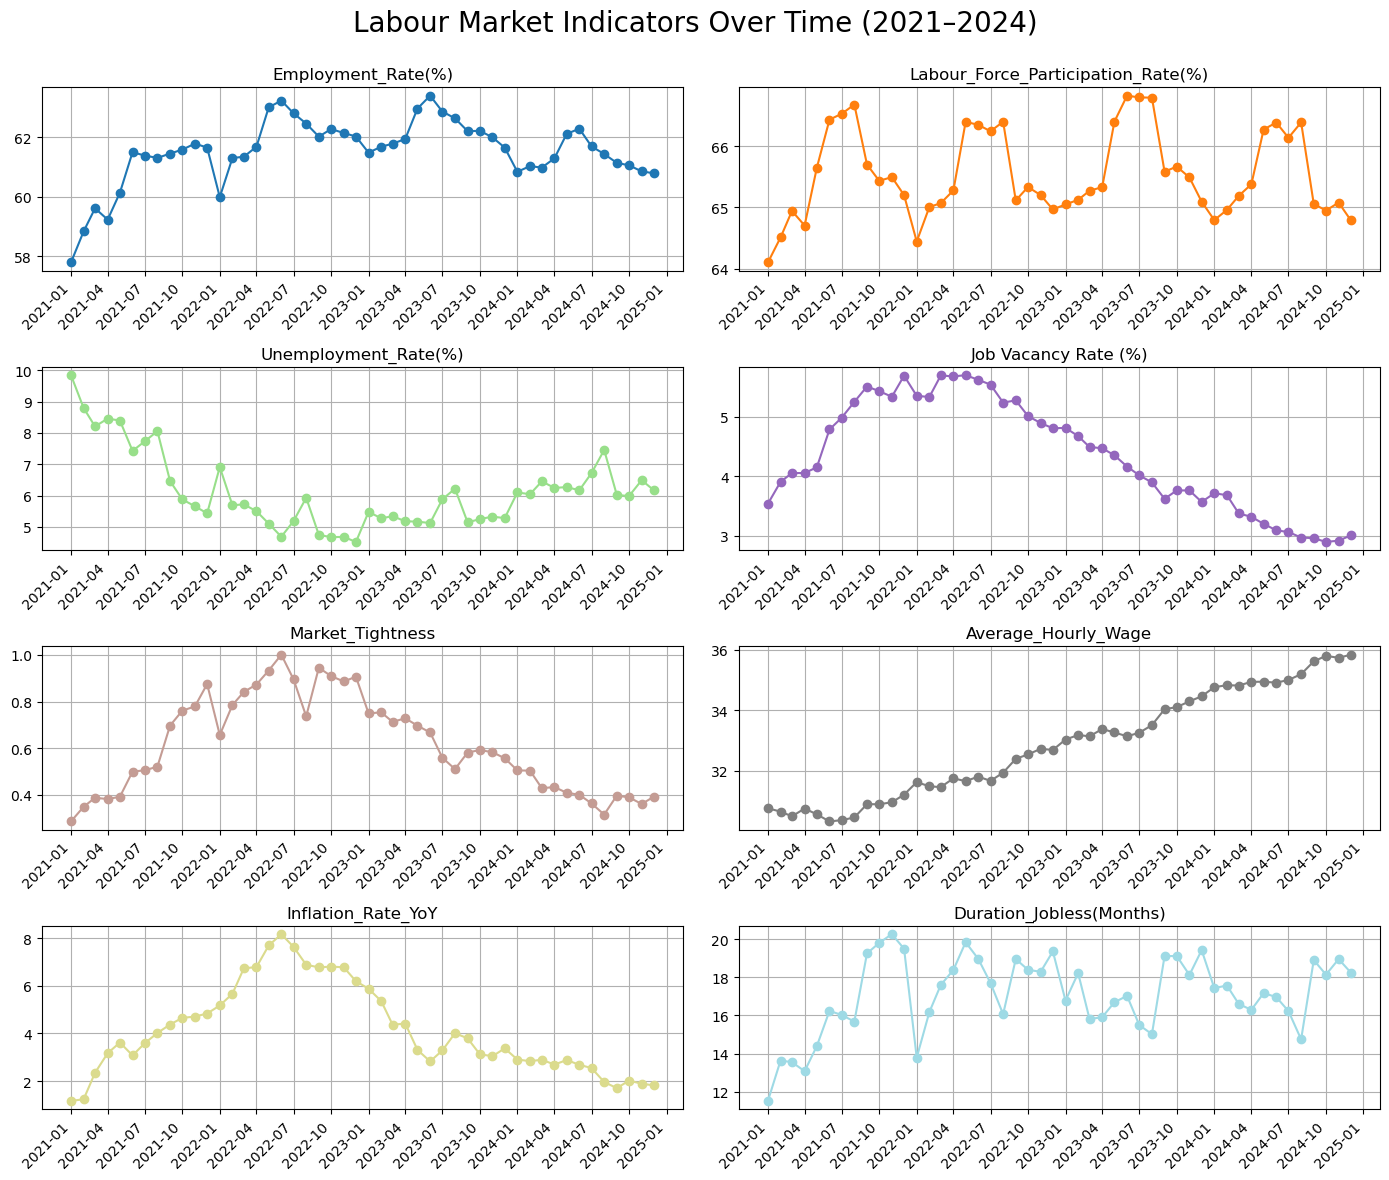

In [144]:
overall_indicators = monthly_rates.copy()
indicators = ["Employment_Rate(%)", "Labour_Force_Participation_Rate(%)", "Unemployment_Rate(%)", 
              "Job Vacancy Rate (%)", "Market_Tightness", "Average_Hourly_Wage", "Inflation_Rate_YoY", "Duration_Jobless(Months)"]

## List of indicators to plot
indicators = ["Employment_Rate(%)", "Labour_Force_Participation_Rate(%)", "Unemployment_Rate(%)", 
              "Job Vacancy Rate (%)", "Market_Tightness", "Average_Hourly_Wage", "Inflation_Rate_YoY", "Duration_Jobless(Months)"]
num_plots = len(indicators)

ncols = 2
nrows = int(np.ceil(len(indicators) / ncols))

fig, axes = plt.subplots(nrows, ncols, figsize=(14, 3 * nrows), sharex=False)
axes = axes.flatten()

## Colour cycle — one distinct colour per plot
colors = plt.cm.tab20(np.linspace(0, 1, len(indicators)))

## Quarterly ticks
locator = mdates.MonthLocator(interval=3)
formatter = mdates.DateFormatter("%Y-%m")

for ax, col, color in zip(axes, indicators, colors):
    ax.plot(overall_indicators["REF_DATE"], overall_indicators[col], marker="o", linestyle="-", color=color)
    ax.set_title(col)
    ax.xaxis.set_major_locator(locator)
    ax.xaxis.set_major_formatter(formatter)
    ax.grid(True)


# Rotate all x-tick labels
for ax in axes:
    plt.setp(ax.xaxis.get_ticklabels(), rotation=45, ha="right")

fig.suptitle("Labour Market Indicators Over Time (2021–2024)", fontsize=20)
plt.tight_layout(rect=[0, 0, 1, 0.98])
plt.show()

### Correlation Matrix of Labour Market Indicators

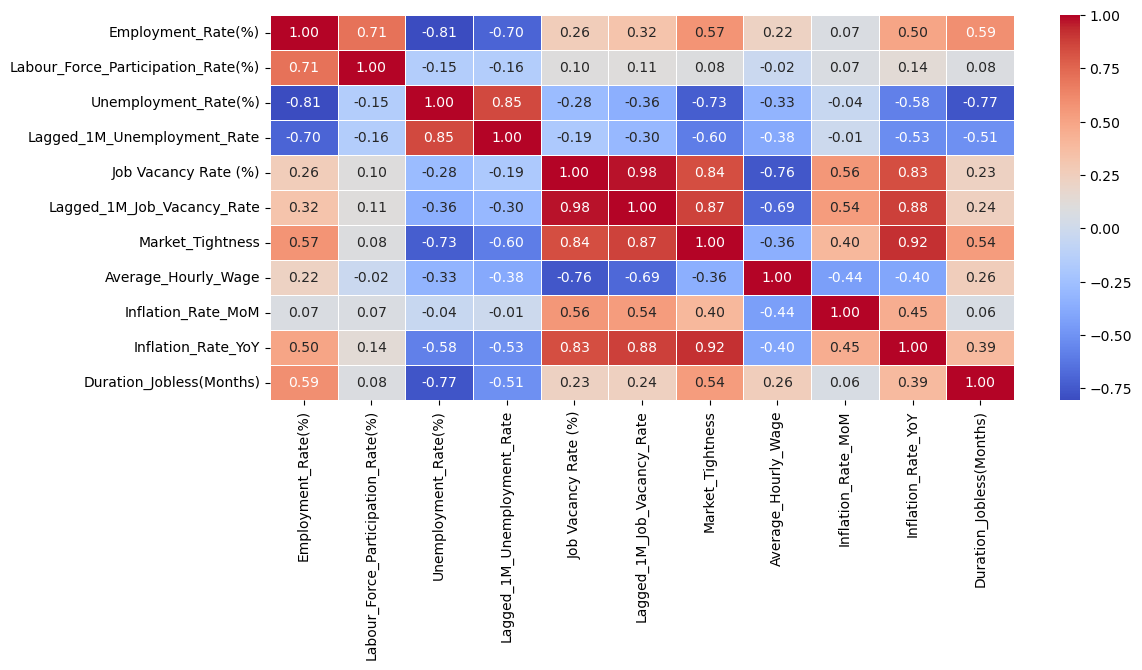

In [145]:
corr_variables = ['Employment_Rate(%)', 'Labour_Force_Participation_Rate(%)', 
                  'Unemployment_Rate(%)', 'Lagged_1M_Unemployment_Rate', 
                  'Job Vacancy Rate (%)', 'Lagged_1M_Job_Vacancy_Rate', 'Market_Tightness', 
                  'Average_Hourly_Wage', 'Inflation_Rate_MoM', 'Inflation_Rate_YoY', 
                  'Duration_Jobless(Months)']
# Compute correlation
plt.figure(figsize=(12, 5))
sns.heatmap(overall_indicators[corr_variables].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("")
plt.show()

### Phillips Curve

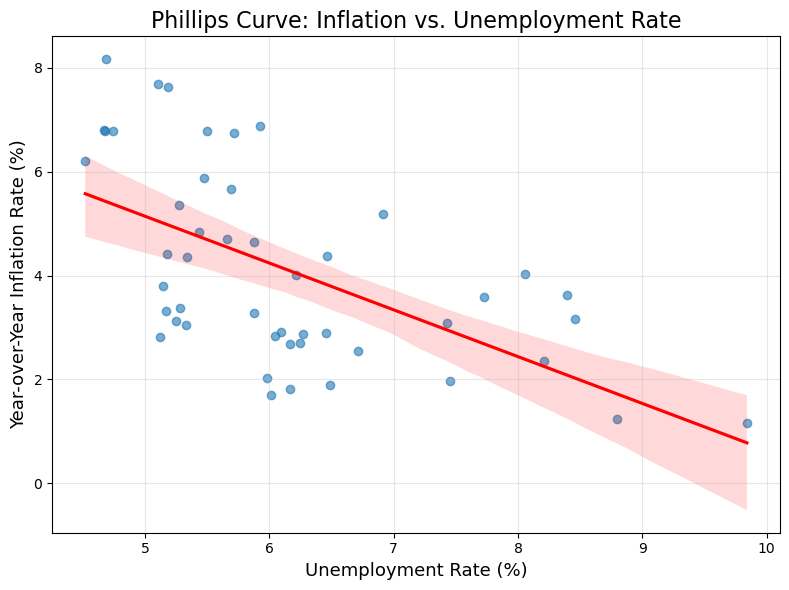

In [146]:
# Overall Phillips Curve
plt.figure(figsize=(8,6))

sns.regplot(
    data=overall_indicators,
    x='Unemployment_Rate(%)',
    y='Inflation_Rate_YoY',
    scatter_kws={'alpha':0.6},
    line_kws={'color':'red'}
)

plt.title('Phillips Curve: Inflation vs. Unemployment Rate', fontsize=16)
plt.xlabel('Unemployment Rate (%)', fontsize=13)
plt.ylabel('Year-over-Year Inflation Rate (%)', fontsize=13)
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


### Exploring Trends Between Inflation and Labour Market Indicators

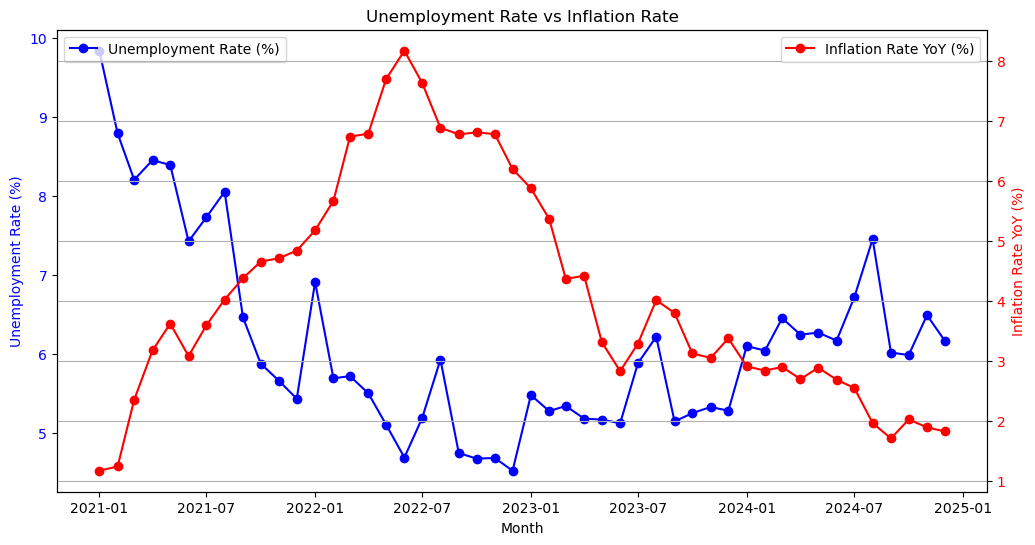

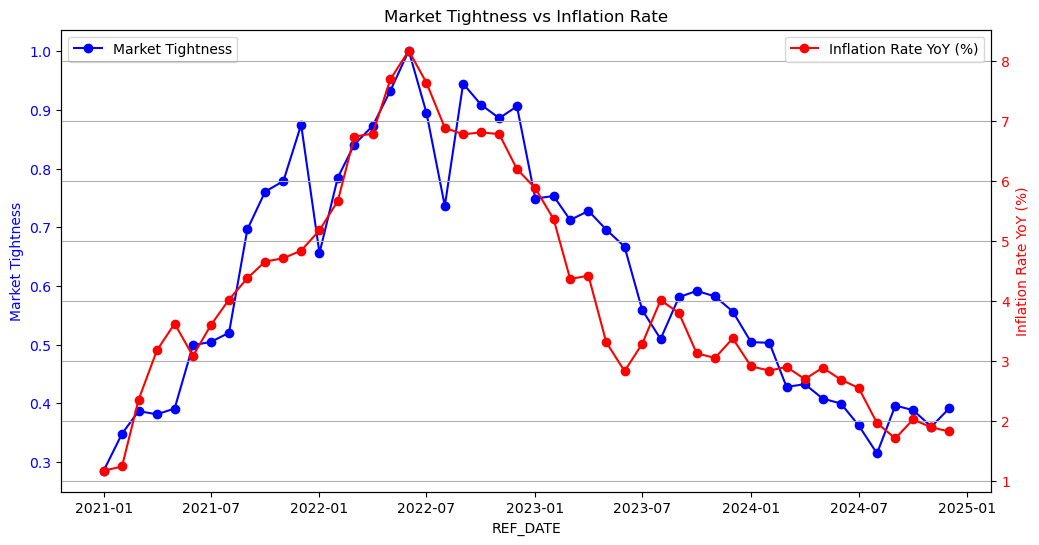

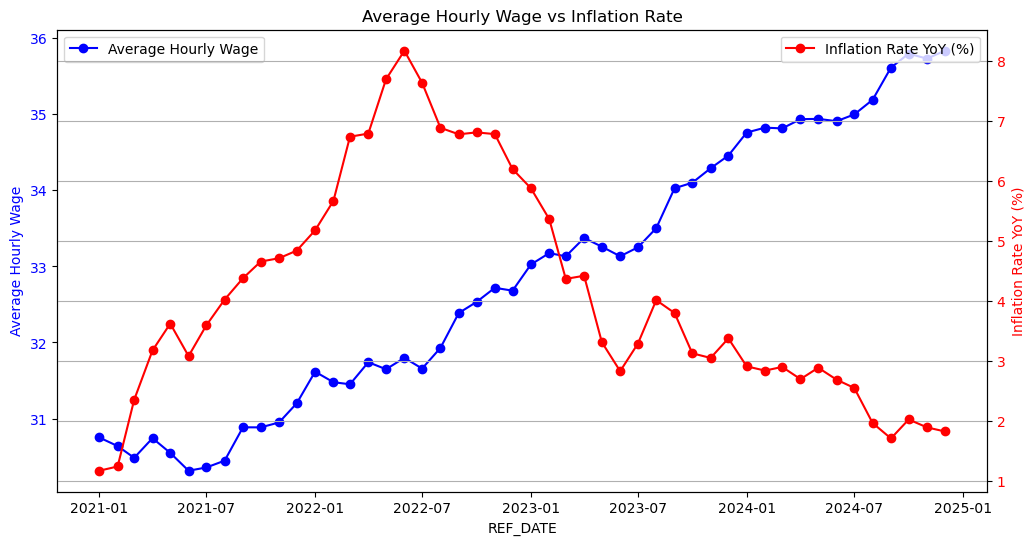

In [147]:
# Plot 1: Unemployment Rate vs Inflation Rate
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary y-axis for Unemployment Rate
ax1.set_xlabel('Month')
ax1.set_ylabel('Unemployment Rate (%)', color='blue')
ax1.plot(overall_indicators['REF_DATE'], overall_indicators['Unemployment_Rate(%)'], label='Unemployment Rate (%)', marker="o", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Secondary y-axis for Inflation Rate
ax2 = ax1.twinx()
ax2.set_ylabel('Inflation Rate YoY (%)', color='red')
ax2.plot(overall_indicators['REF_DATE'], overall_indicators['Inflation_Rate_YoY'], label="Inflation Rate YoY (%)", marker="o", color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Title and formatting
plt.title("Unemployment Rate vs Inflation Rate")
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid()
plt.xticks(rotation=45)
plt.show()

# Plot 2: Market Tightness vs Inflation Rate
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary y-axis for Market Tightness
ax1.set_xlabel('REF_DATE')
ax1.set_ylabel('Market Tightness', color='blue')
ax1.plot(overall_indicators['REF_DATE'], overall_indicators['Market_Tightness'], label='Market Tightness', marker="o", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Secondary y-axis for Inflation Rate
ax2 = ax1.twinx()
ax2.set_ylabel('Inflation Rate YoY (%)', color='red')
ax2.plot(overall_indicators['REF_DATE'], overall_indicators['Inflation_Rate_YoY'], label="Inflation Rate YoY (%)", marker="o", color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Title and formatting
plt.title("Market Tightness vs Inflation Rate")
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid()
plt.xticks(rotation=45)
plt.show()

# Plot 3: Average Hourly Wage vs Inflation Rate
fig, ax1 = plt.subplots(figsize=(12, 6))

# Primary y-axis for Average Hourly Wage
ax1.set_xlabel('REF_DATE')
ax1.set_ylabel('Average Hourly Wage', color='blue')
ax1.plot(overall_indicators['REF_DATE'], overall_indicators['Average_Hourly_Wage'], label='Average Hourly Wage', marker="o", color='blue')
ax1.tick_params(axis='y', labelcolor='blue')

# Secondary y-axis for Inflation Rate
ax2 = ax1.twinx()
ax2.set_ylabel('Inflation Rate YoY (%)', color='red')
ax2.plot(overall_indicators['REF_DATE'], overall_indicators['Inflation_Rate_YoY'], label="Inflation Rate YoY (%)", marker="o", color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Title and formatting
plt.title("Average Hourly Wage vs Inflation Rate")
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')
plt.grid()
plt.xticks(rotation=45)
plt.show()

### Industry Trends

/var/folders/n9/29yl9jnj61q74vg3ydjdf3qh0000gn/T/ipykernel_975/3520352841.py:46: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=14)
/var/folders/n9/29yl9jnj61q74vg3ydjdf3qh0000gn/T/ipykernel_975/3520352841.py:50: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


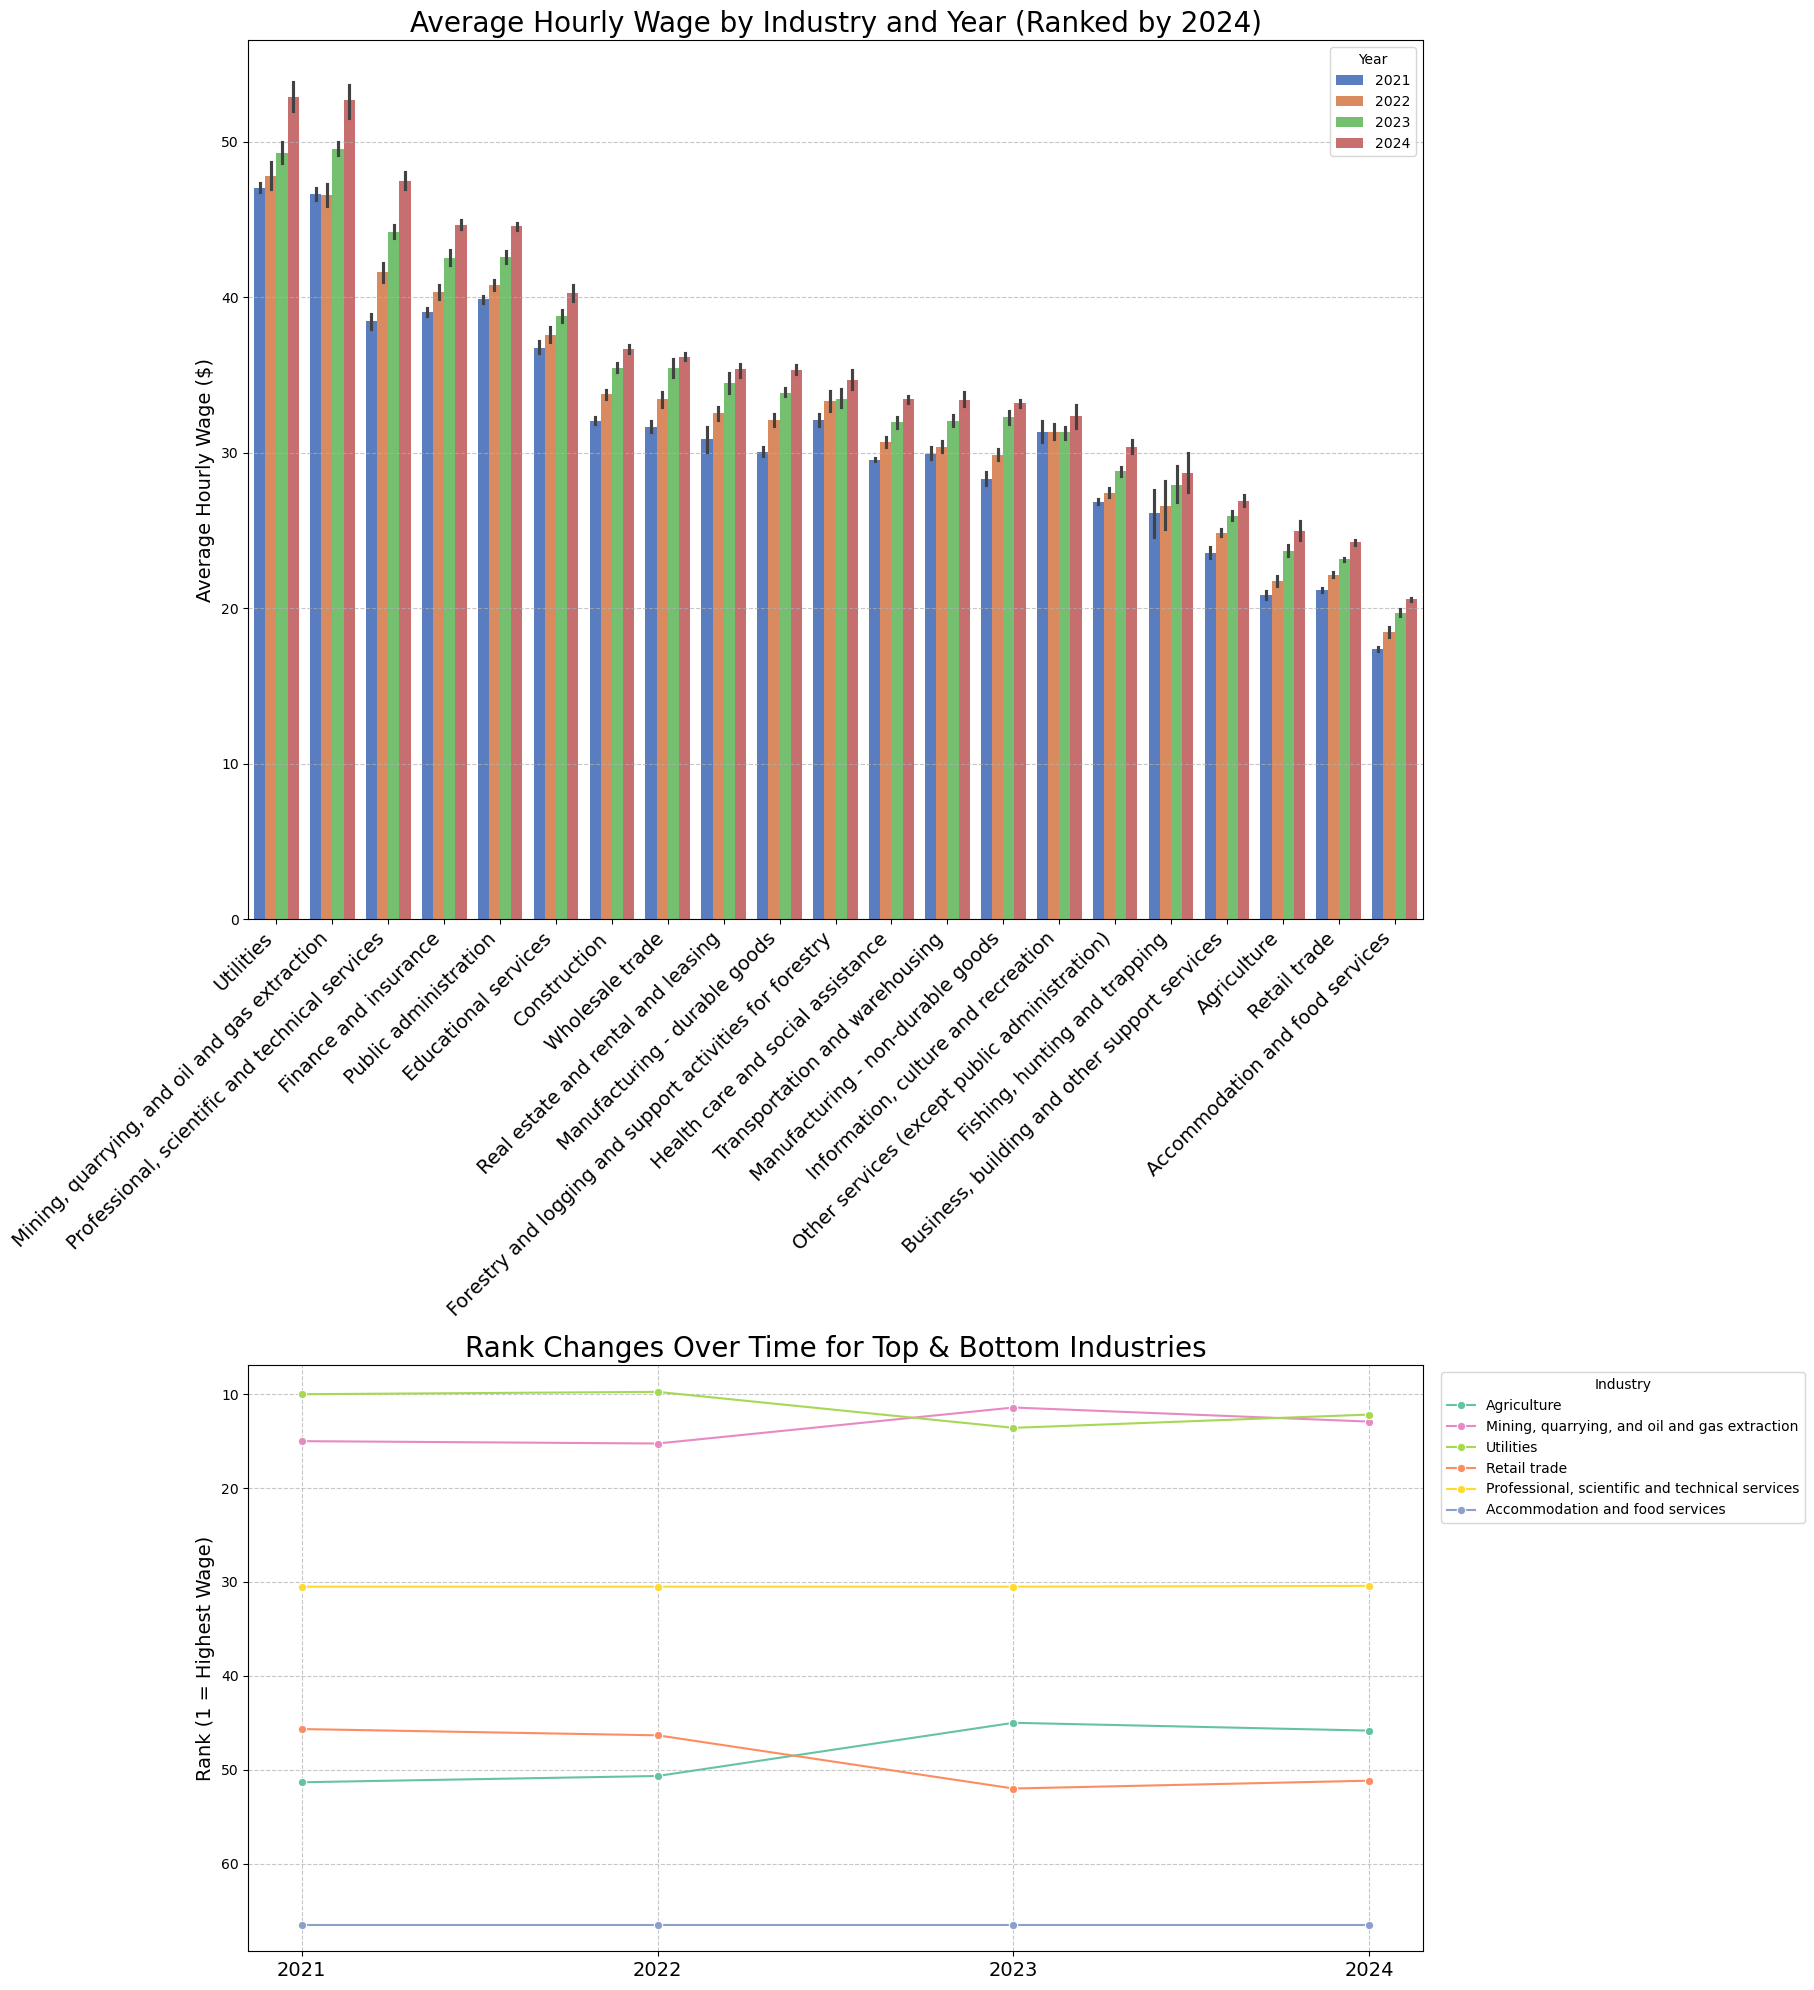

In [148]:
## Prepare data for the grouped bar chart (using 2024 for ordering)
industry_trends = monthly_industry_rates.copy()

## Filter for 2024 and sort industries by Average Hourly Wage
df_2024_agg = (
    industry_trends[industry_trends["Year"] == 2024]
    .groupby("NAICS_21_Label", as_index=False, observed=False)["Average_Hourly_Wage"]
    .mean()
)
df_2024_sorted = df_2024_agg.sort_values("Average_Hourly_Wage", ascending=False)
ordered_industries = df_2024_sorted["NAICS_21_Label"].tolist()


## Prepare data for the bump chart (focus on top and bottom industries based on 2024 ranking)
top_n = 3
bottom_n = 3

# Select top_n and bottom_n industries from the 2024 data
selected_industries = list(df_2024_sorted.head(top_n)["NAICS_21_Label"]) + \
                      list(df_2024_sorted.tail(bottom_n)["NAICS_21_Label"])

# Filter the full dataset for these industries
df_selected = industry_trends[industry_trends["NAICS_21_Label"].isin(selected_industries)].copy()

# For each year, compute the rank (with 1 = highest wage)
df_selected["Rank"] = df_selected.groupby("Year")["Average_Hourly_Wage"].rank(ascending=False)


## Create the combined figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 20), gridspec_kw={'height_ratios': [3, 2]})

## Subplot 1: Grouped Bar Chart for Average Hourly Wage by Industry and Year
sns.barplot(
    data=industry_trends,
    x="NAICS_21_Label",
    y="Average_Hourly_Wage",
    hue="Year",
    order=ordered_industries, 
    palette="muted",
    ax=ax1
)
ax1.set_title("Average Hourly Wage by Industry and Year (Ranked by 2024)", fontsize=20)
ax1.set_xlabel("")
ax1.set_ylabel("Average Hourly Wage ($)", fontsize=14)
ax1.tick_params(axis="x", labelsize=12, labelrotation=45, right=True)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=14)
ax1.grid(axis="y", linestyle="--", alpha=0.7)

## Subplot 2: Bump Chart for Rank Changes Over Time for Top & Bottom Industries
sns.lineplot(
    data=df_selected,
    x="Year",
    y="Rank",
    hue="NAICS_21_Label",
    marker="o",
    palette="Set2",
    ax=ax2, 
    ci=None
)
ax2.set_title("Rank Changes Over Time for Top & Bottom Industries", fontsize=20)
ax2.set_xlabel("")
ax2.set_ylabel("Rank (1 = Highest Wage)", fontsize=14)
ax2.invert_yaxis()
ax2.set_xticks(sorted(industry_trends["Year"].unique()))
ax2.tick_params(axis="x", labelsize=14)
ax2.grid(True, linestyle="--", alpha=0.7)

## Filter the legend to only include selected industries
handles, labels = ax2.get_legend_handles_labels()
selected_labels = df_selected['NAICS_21_Label'].unique().tolist()
filtered = [(h, l) for h, l in zip(handles, labels) if l in selected_labels]

## Rebuild the legend with only the selected industries
if filtered:
    filtered_handles, filtered_labels = zip(*filtered)
    ax2.legend(filtered_handles, filtered_labels, title="Industry", bbox_to_anchor=(1.01, 1), loc='upper left')

## Adjust layout and show the plot
plt.subplots_adjust(right=1) 
plt.tight_layout()
plt.show()


/var/folders/n9/29yl9jnj61q74vg3ydjdf3qh0000gn/T/ipykernel_975/1792155319.py:4: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  .groupby("NAICS_21_Label", as_index=False)["Duration_Jobless(Months)"]
/var/folders/n9/29yl9jnj61q74vg3ydjdf3qh0000gn/T/ipykernel_975/1792155319.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=14)
/var/folders/n9/29yl9jnj61q74vg3ydjdf3qh0000gn/T/ipykernel_975/1792155319.py:44: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


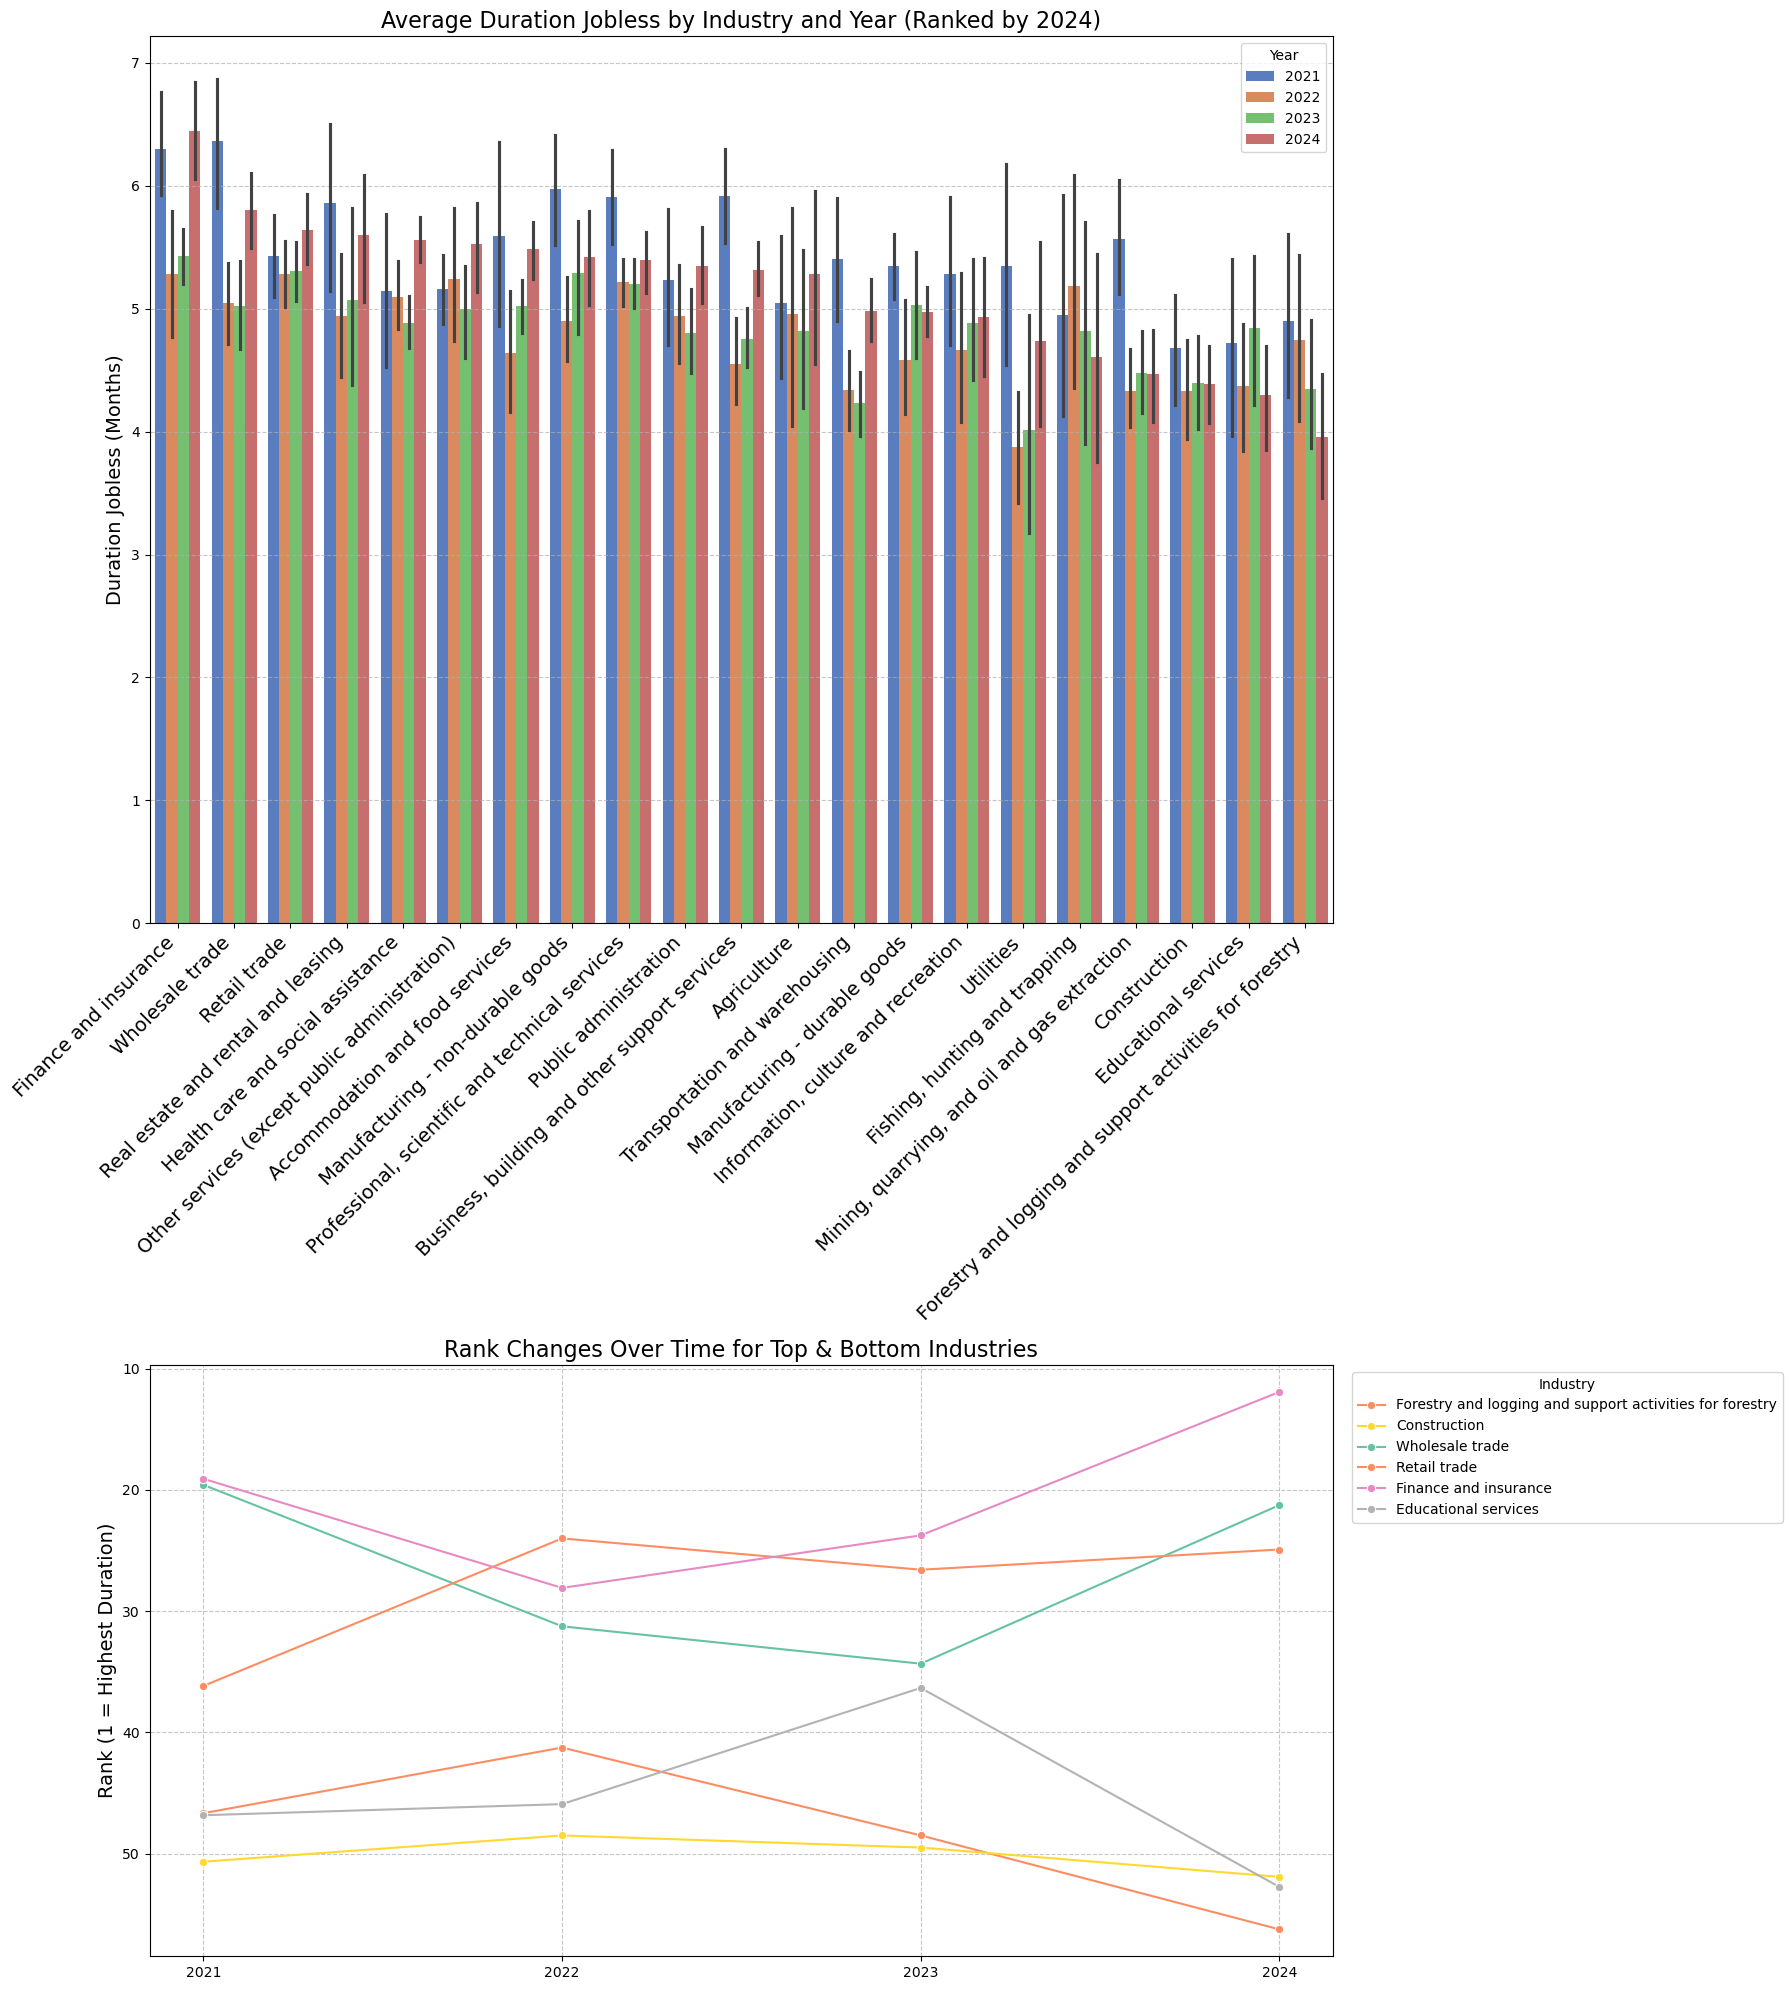

In [149]:
## Filter for 2024 and sort industries by Duration_Jobless
df_2024_agg = (
    industry_trends[industry_trends["Year"] == 2024]
    .groupby("NAICS_21_Label", as_index=False)["Duration_Jobless(Months)"]
    .mean()
)
df_2024_sorted = df_2024_agg.sort_values("Duration_Jobless(Months)", ascending=False)
ordered_industries = df_2024_sorted["NAICS_21_Label"].tolist()

## Select top_n and bottom_n industries from the 2024 data
selected_industries = list(df_2024_sorted.head(top_n)["NAICS_21_Label"]) + \
                      list(df_2024_sorted.tail(bottom_n)["NAICS_21_Label"])

## Filter the full dataset for these industries
df_selected = industry_trends[industry_trends["NAICS_21_Label"].isin(selected_industries)].copy()

## For each year, compute the rank (with 1 = highest wage)
df_selected["Rank"] = df_selected.groupby("Year")["Duration_Jobless(Months)"].rank(ascending=False)


## Create the combined figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 20), gridspec_kw={'height_ratios': [3, 2]})

## Subplot 1: Grouped Bar Chart for Duration Jobless by Industry and Year
sns.barplot(
    data=industry_trends,
    x="NAICS_21_Label",
    y="Duration_Jobless(Months)",
    hue="Year",
    order=ordered_industries,
    estimator=np.mean,
    palette="muted",
    ax=ax1
)
ax1.set_title("Average Duration Jobless by Industry and Year (Ranked by 2024)", fontsize=16)
ax1.set_xlabel("")
ax1.set_ylabel("Duration Jobless (Months)", fontsize=14)
ax1.tick_params(axis="x", rotation=45)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=14)
ax1.grid(axis="y", linestyle="--", alpha=0.7)


## Subplot 2: Bump Chart for Rank Changes Over Time for Top & Bottom Industries
sns.lineplot(
    data=df_selected,
    x="Year",
    y="Rank",
    hue="NAICS_21_Label",
    marker="o",
    palette="Set2",
    ax=ax2, 
    ci=None
)
ax2.set_title("Rank Changes Over Time for Top & Bottom Industries", fontsize=16)
ax2.set_xlabel("")
ax2.set_ylabel("Rank (1 = Highest Duration)", fontsize=14)
ax2.invert_yaxis()  
ax2.set_xticks(sorted(industry_trends["Year"].unique()))
ax2.grid(True, linestyle="--", alpha=0.7)



## Filter the legend to only include selected industries
handles, labels = ax2.get_legend_handles_labels()
selected_labels = df_selected['NAICS_21_Label'].unique().tolist()
filtered = [(h, l) for h, l in zip(handles, labels) if l in selected_labels]

## Rebuild the legend with only the selected industries
if filtered:
    filtered_handles, filtered_labels = zip(*filtered)
    ax2.legend(filtered_handles, filtered_labels, title="Industry", bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()


/var/folders/n9/29yl9jnj61q74vg3ydjdf3qh0000gn/T/ipykernel_975/3279618586.py:39: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize =14)
/var/folders/n9/29yl9jnj61q74vg3ydjdf3qh0000gn/T/ipykernel_975/3279618586.py:43: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(


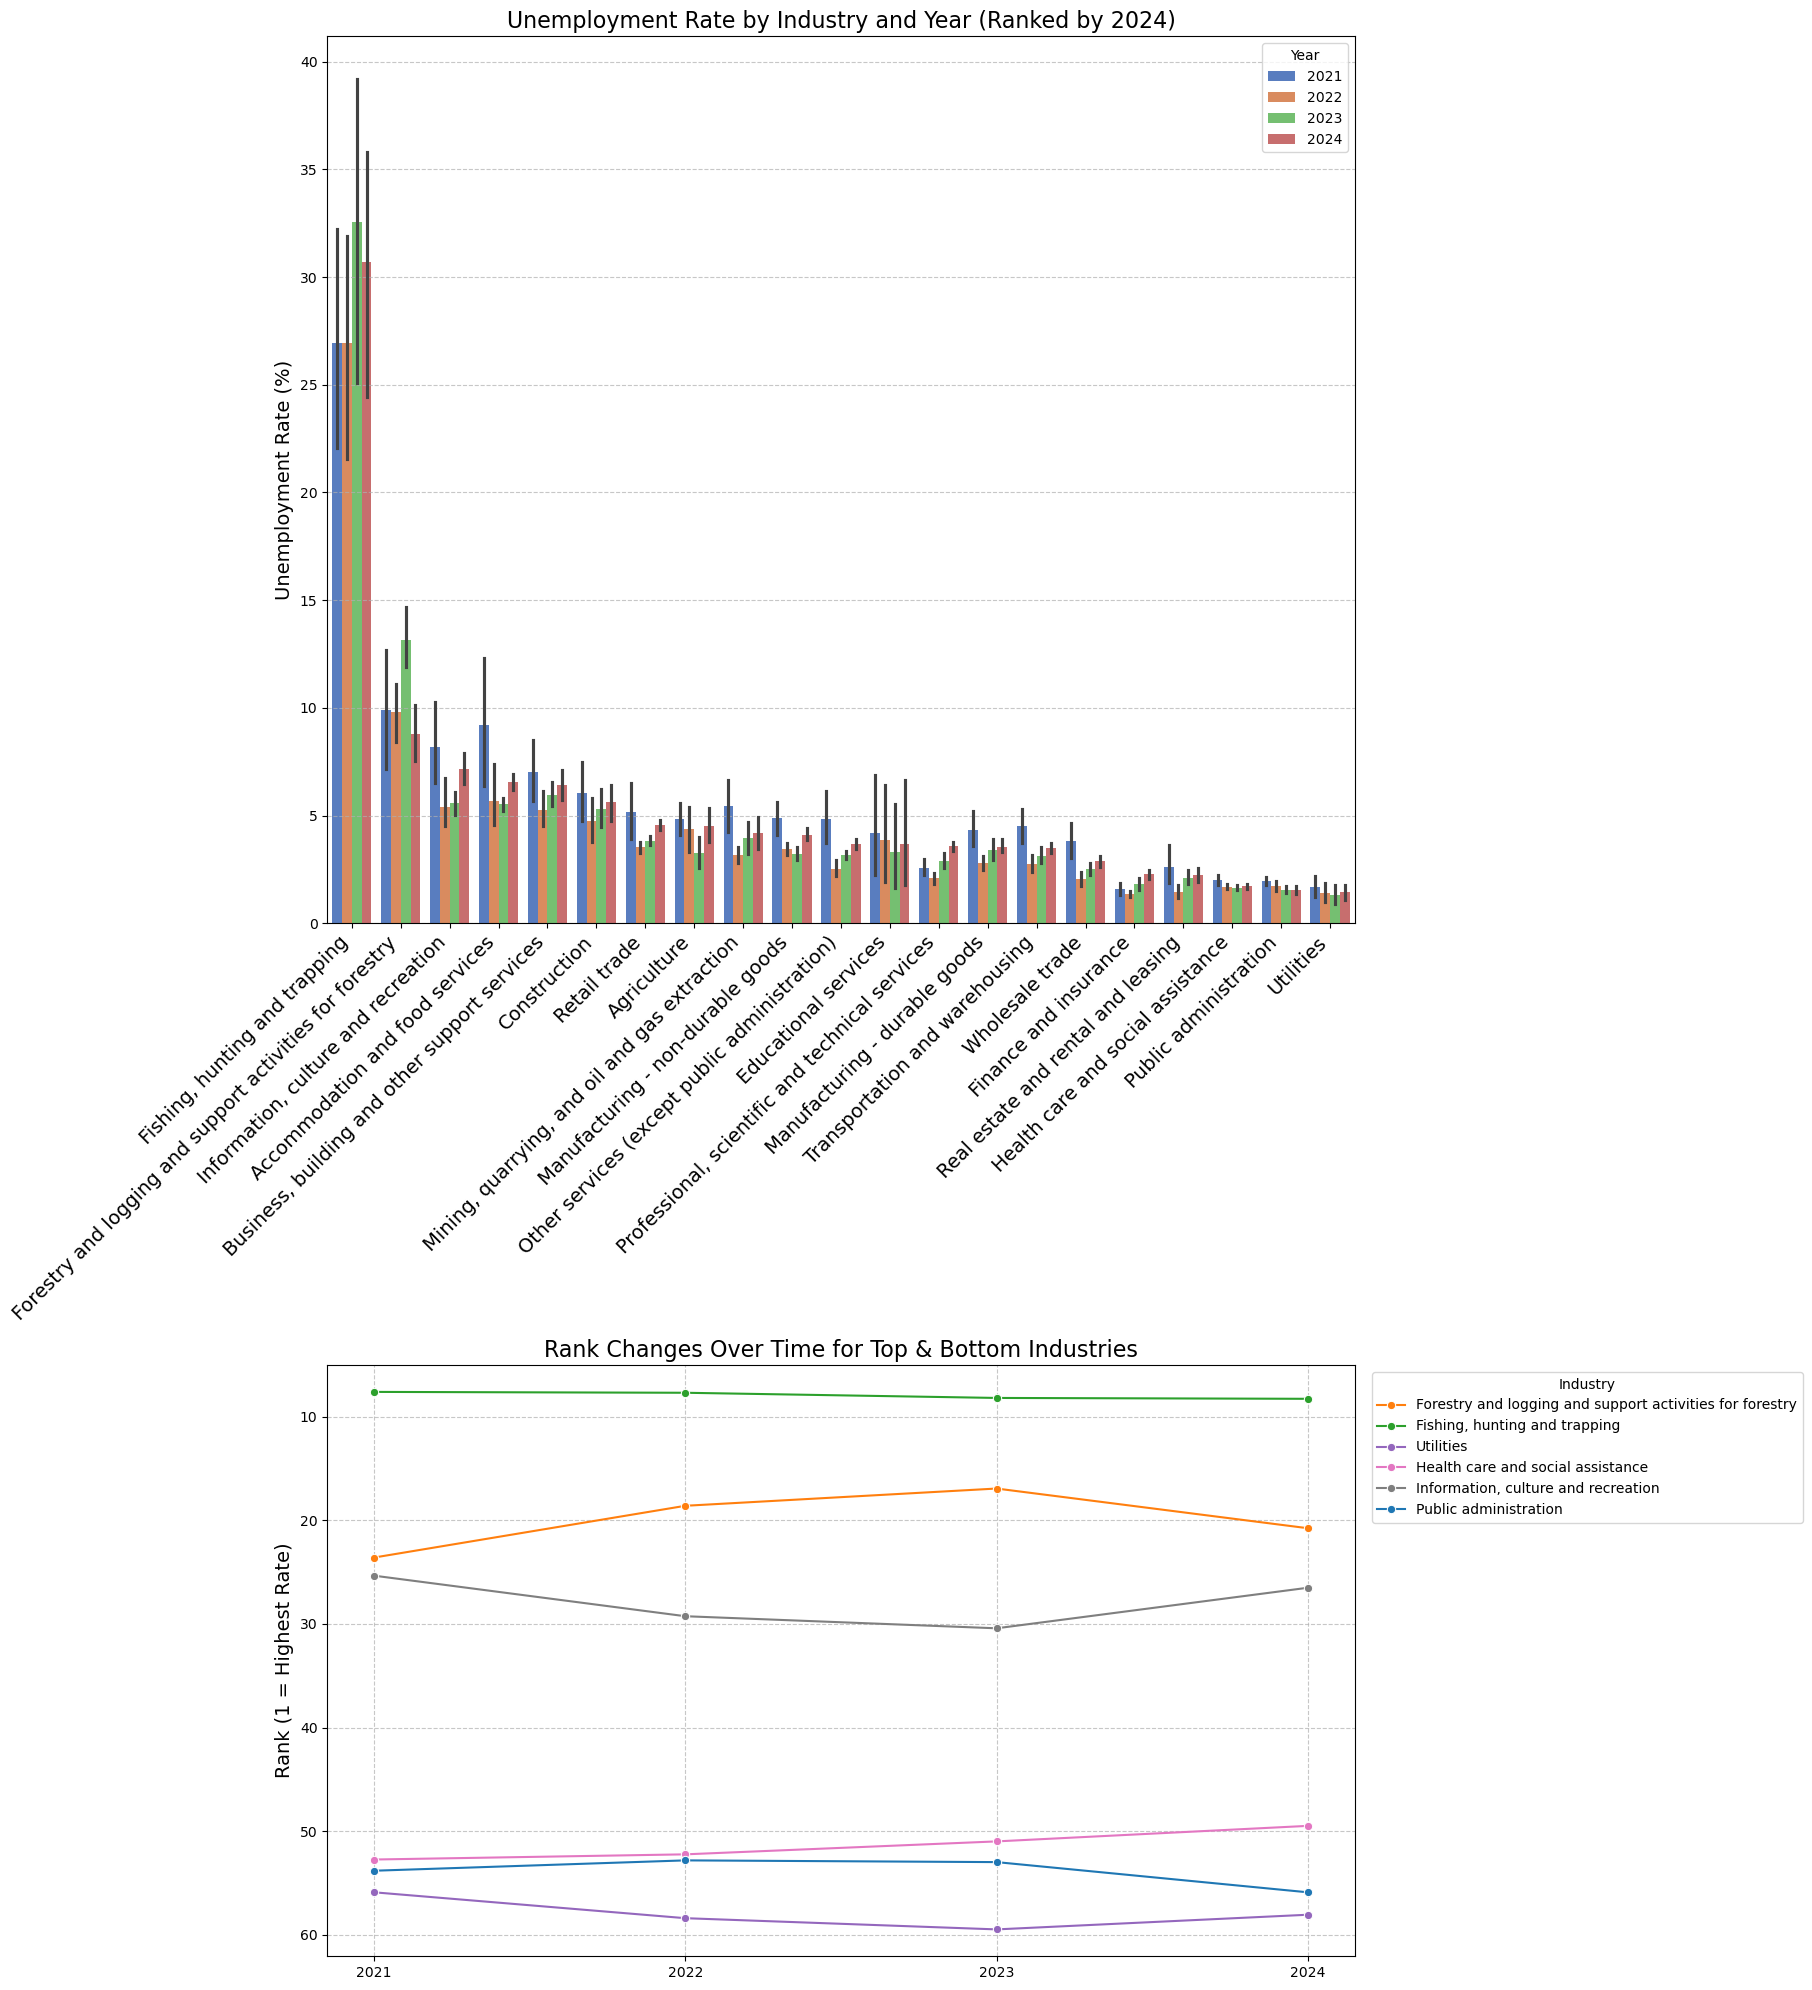

In [150]:
## Filter for 2024 and sort industries by Duration_Jobless
df_2024_agg = (
    industry_trends[industry_trends["Year"] == 2024]
    .groupby("NAICS_21_Label", as_index=False, observed=False)["Unemployment_Rate(%)"]
    .mean()
)
df_2024_sorted = df_2024_agg.sort_values("Unemployment_Rate(%)", ascending=False)
ordered_industries = df_2024_sorted["NAICS_21_Label"].tolist()

## Select top_n and bottom_n industries from the 2024 data
selected_industries = list(df_2024_sorted.head(top_n)["NAICS_21_Label"]) + \
                      list(df_2024_sorted.tail(bottom_n)["NAICS_21_Label"])

## Filter the full dataset for these industries
df_selected = industry_trends[industry_trends["NAICS_21_Label"].isin(selected_industries)].copy()

## For each year, compute the rank (with 1 = highest wage)
df_selected["Rank"] = df_selected.groupby("Year")["Unemployment_Rate(%)"].rank(ascending=False)


## Create the combined figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 20), gridspec_kw={'height_ratios': [3, 2]})

# -- Subplot 1: Grouped Bar Chart --
sns.barplot(
    data=industry_trends,
    x="NAICS_21_Label",
    y="Unemployment_Rate(%)",
    hue="Year",
    order=ordered_industries,
    estimator=np.mean,
    palette="muted",
    ax=ax1
)
ax1.set_title("Unemployment Rate by Industry and Year (Ranked by 2024)", fontsize=16)
ax1.set_xlabel("")
ax1.set_ylabel("Unemployment Rate (%)", fontsize=14)
ax1.tick_params(axis="x", rotation=45)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize =14)
ax1.grid(axis="y", linestyle="--", alpha=0.7)

# -- Subplot 2: Bump Chart for Rank Changes --
sns.lineplot(
    data=df_selected,
    x="Year",
    y="Rank",
    hue="NAICS_21_Label",
    marker="o",
    palette="tab10",
    ax=ax2, 
    ci=None
)
ax2.set_title("Rank Changes Over Time for Top & Bottom Industries", fontsize=16)
ax2.set_xlabel("")
ax2.set_ylabel("Rank (1 = Highest Rate)", fontsize=14)
ax2.invert_yaxis()  # Invert so that rank 1 is at the top
ax2.set_xticks(sorted(industry_trends["Year"].unique()))
ax2.grid(True, linestyle="--", alpha=0.7)
ax2.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)

## Filter the legend to only include selected industries
handles, labels = ax2.get_legend_handles_labels()
selected_labels = df_selected['NAICS_21_Label'].unique().tolist()
filtered = [(h, l) for h, l in zip(handles, labels) if l in selected_labels]

## Rebuild the legend with only the selected industries
if filtered:
    filtered_handles, filtered_labels = zip(*filtered)
    ax2.legend(filtered_handles, filtered_labels, title="Industry", bbox_to_anchor=(1.01, 1), loc='upper left')
plt.tight_layout()
plt.show()

/var/folders/n9/29yl9jnj61q74vg3ydjdf3qh0000gn/T/ipykernel_975/777914554.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=14)


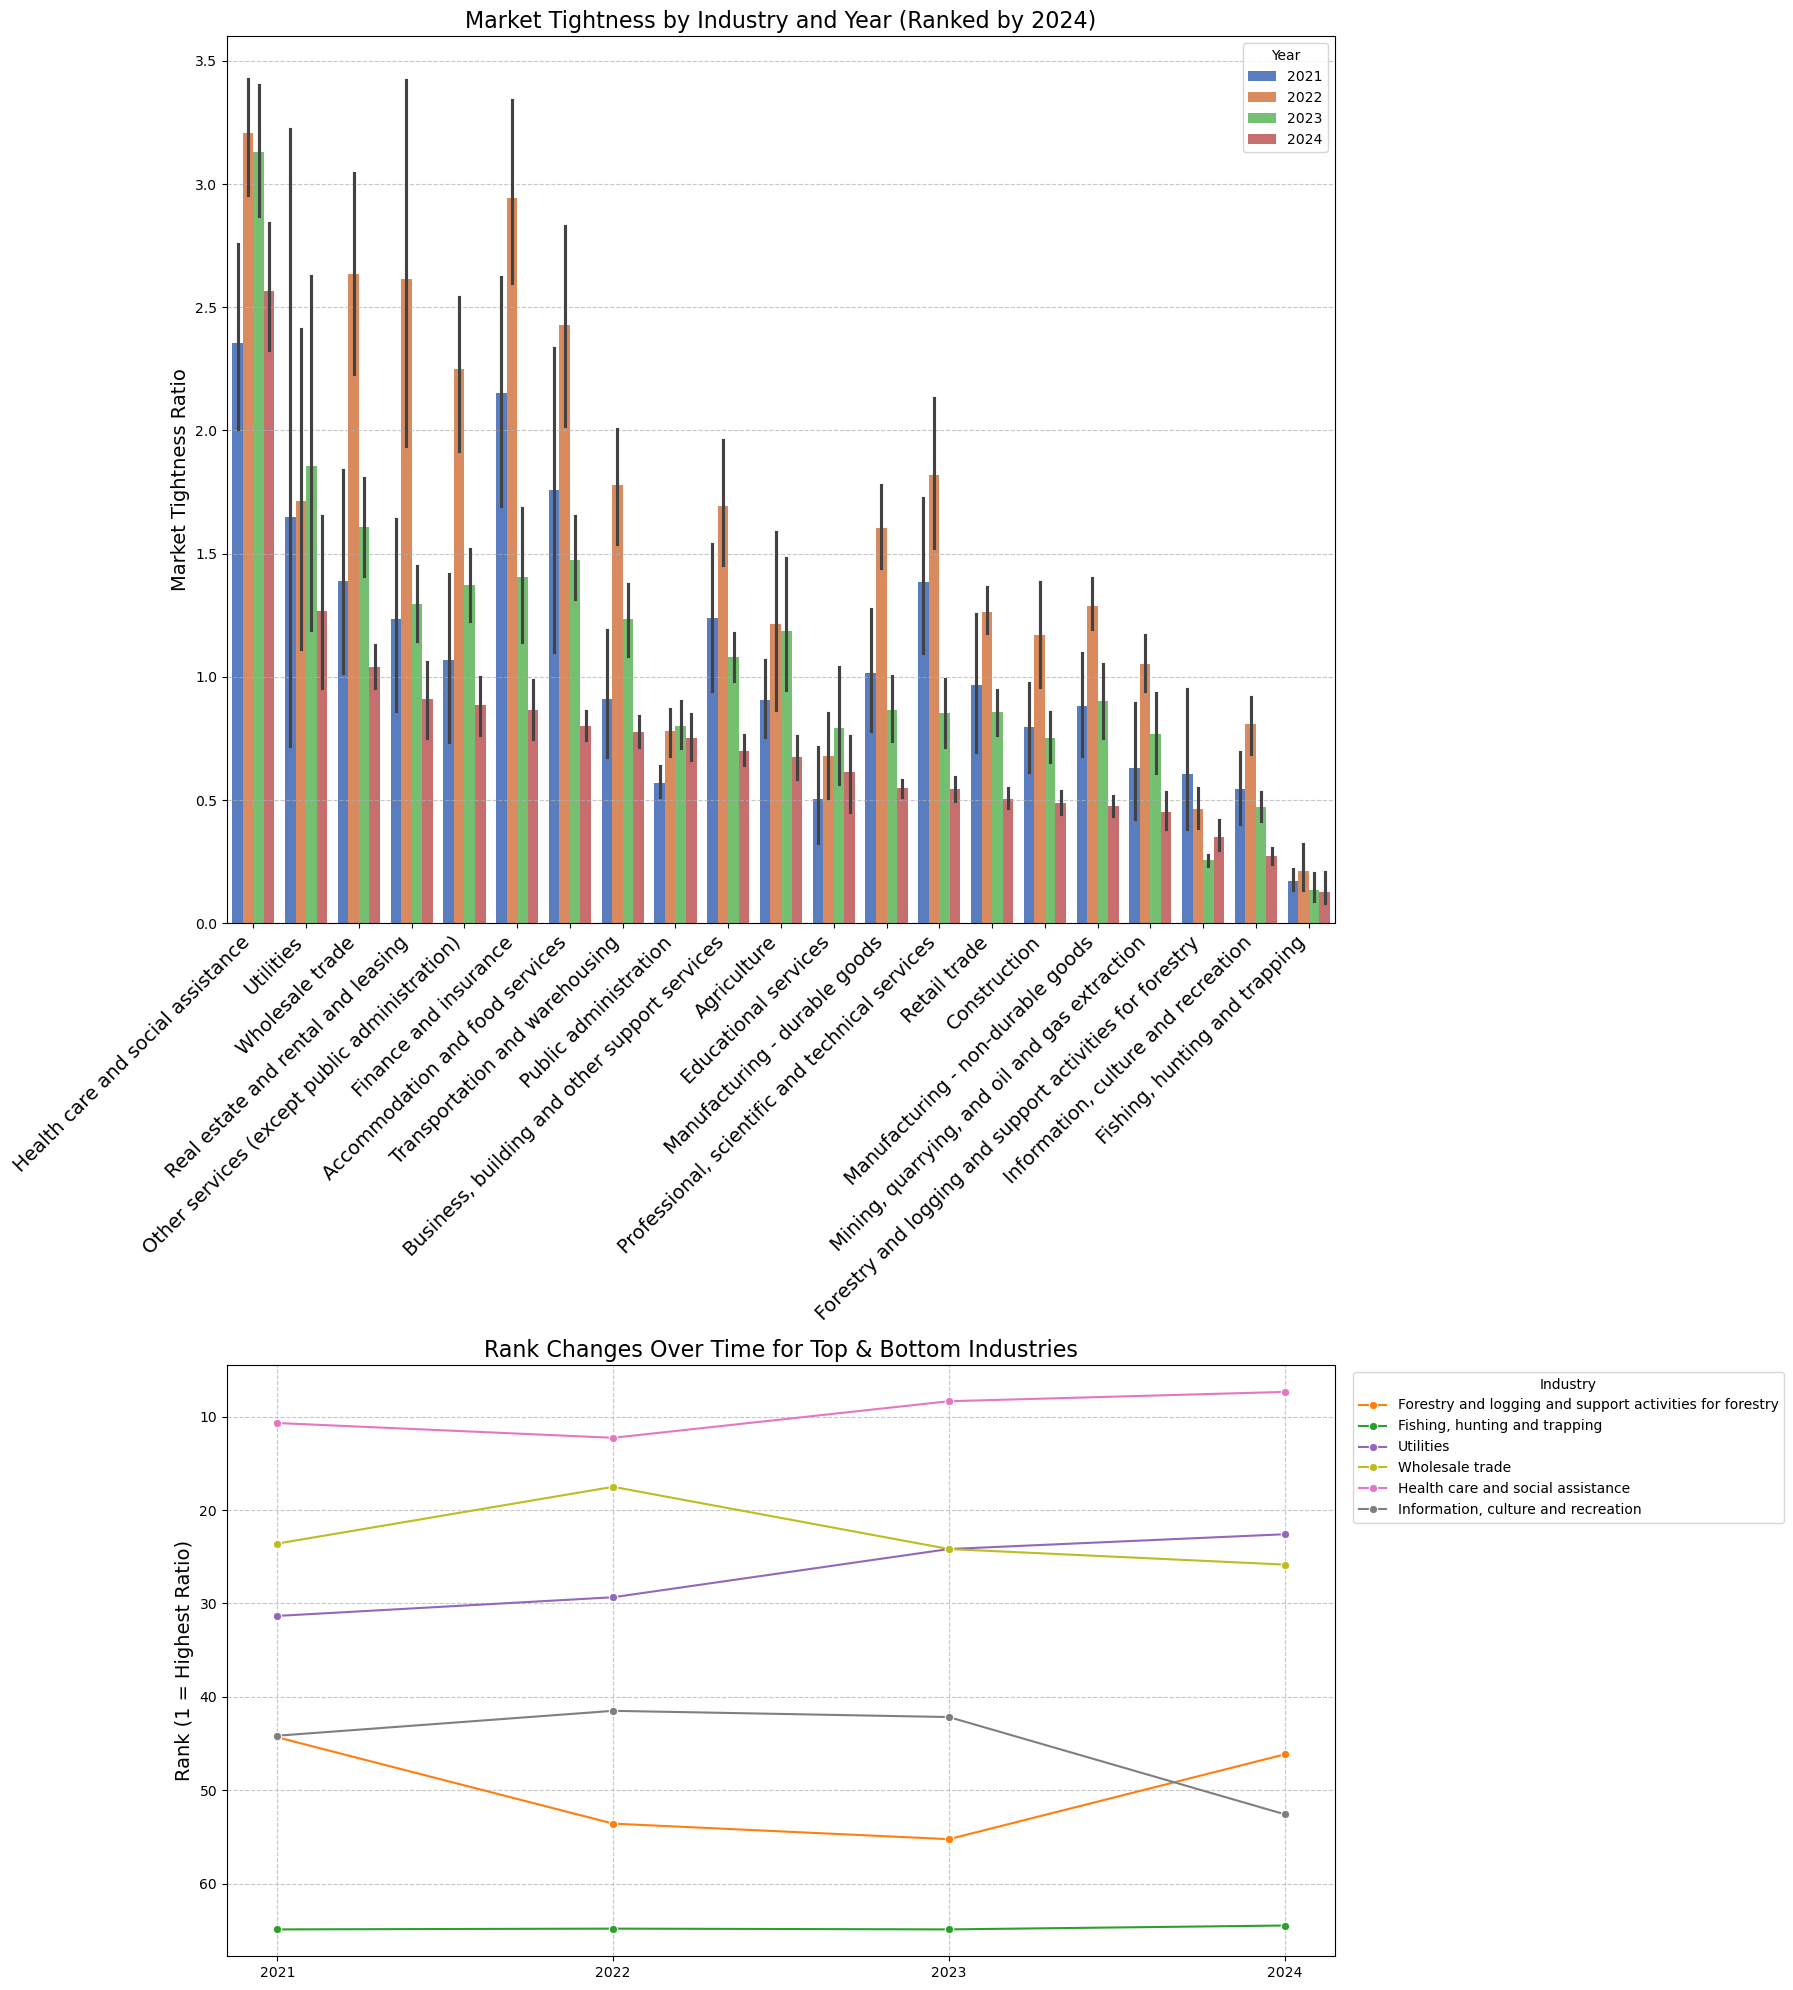

In [151]:
# Filter for 2024 and sort industries by Duration_Jobless
df_2024_agg = (
    industry_trends[industry_trends["Year"] == 2024]
    .groupby("NAICS_21_Label", as_index=False, observed=False)["Market_Tightness"]
    .mean()
)
df_2024_sorted = df_2024_agg.sort_values("Market_Tightness", ascending=False)
ordered_industries = df_2024_sorted["NAICS_21_Label"].tolist()

# Select top_n and bottom_n industries from the 2024 data
selected_industries = list(df_2024_sorted.head(top_n)["NAICS_21_Label"]) + \
                      list(df_2024_sorted.tail(bottom_n)["NAICS_21_Label"])

# Filter the full dataset for these industries
df_selected = industry_trends[industry_trends["NAICS_21_Label"].isin(selected_industries)].copy()

# For each year, compute the rank (with 1 = highest wage)
df_selected["Rank"] = df_selected.groupby("Year")["Market_Tightness"].rank(ascending=False)

# Create the combined figure with two subplots
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(18, 20), gridspec_kw={'height_ratios': [3, 2]})

# Subplot 1: Grouped Bar Chart for Market Tightness by Industry and Year
sns.barplot(
    data=industry_trends,
    x="NAICS_21_Label",
    y="Market_Tightness",
    hue="Year",
    order=ordered_industries,
    estimator=np.mean, 
    palette="muted",
    ax=ax1
)
ax1.set_title("Market Tightness by Industry and Year (Ranked by 2024)", fontsize=16)
ax1.set_xlabel("")
ax1.set_ylabel("Market Tightness Ratio", fontsize=14)
ax1.tick_params(axis="x", rotation=45)
ax1.set_xticklabels(ax1.get_xticklabels(), rotation=45, ha='right', fontsize=14)
ax1.grid(axis="y", linestyle="--", alpha=0.7)

# -- Subplot 2: Bump Chart for Rank Changes --
sns.lineplot(
    data=df_selected,
    x="Year",
    y="Rank",
    hue="NAICS_21_Label",
    marker="o",
    palette="tab10",
    ax=ax2, 
    errorbar=None
)
ax2.set_title("Rank Changes Over Time for Top & Bottom Industries", fontsize=16)
ax2.set_xlabel("")
ax2.set_ylabel("Rank (1 = Highest Ratio)", fontsize=14)
ax2.invert_yaxis()  # Invert so that rank 1 is at the top
ax2.set_xticks(sorted(industry_trends["Year"].unique()))
ax2.grid(True, linestyle="--", alpha=0.7)
ax2.legend(bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0)

## Filter the legend to only include selected industries
handles, labels = ax2.get_legend_handles_labels()
selected_labels = df_selected['NAICS_21_Label'].unique().tolist()
filtered = [(h, l) for h, l in zip(handles, labels) if l in selected_labels]

## Rebuild the legend with only the selected industries
if filtered:
    filtered_handles, filtered_labels = zip(*filtered)
    ax2.legend(filtered_handles, filtered_labels, title="Industry", bbox_to_anchor=(1.01, 1), loc='upper left')

plt.tight_layout()
plt.show()


### Market Tightness, Average Hourly Wage, and Unemployment Rate VS. Inflation Rate

In [152]:
def plot_dual_axis(data, left_var, right_var, left_label, right_label, left_color='tab:blue', right_color='tab:red'):

    """This function creates a dual-axis time series plot for a given industry,
plotting one variable on the left y-axis and another on the right y-axis.
It is designed to be used inside a seaborn FacetGrid (one subplot per industry)."""

    ax = plt.gca()
    
    # Plot primary (left y-axis) variable
    ax.plot(data['REF_DATE'], data[left_var], color=left_color)
    ax.set_ylabel(left_label, color=left_color, fontsize=10)
    ax.tick_params(axis='y', labelcolor=left_color, labelsize=9)
    ax.tick_params(axis='x', labelsize=8)

    # Plot secondary (right y-axis) variable
    ax2 = ax.twinx()
    ax2.plot(data['REF_DATE'], data[right_var], color=right_color)
    ax2.set_ylabel(right_label, color=right_color, fontsize=10)
    ax2.tick_params(axis='y', labelcolor=right_color, labelsize=9)

    # Title each facet with industry name
    if 'NAICS_21_Label' in data.columns:
        ax.set_title(data['NAICS_21_Label'].iloc[0], fontsize=11)


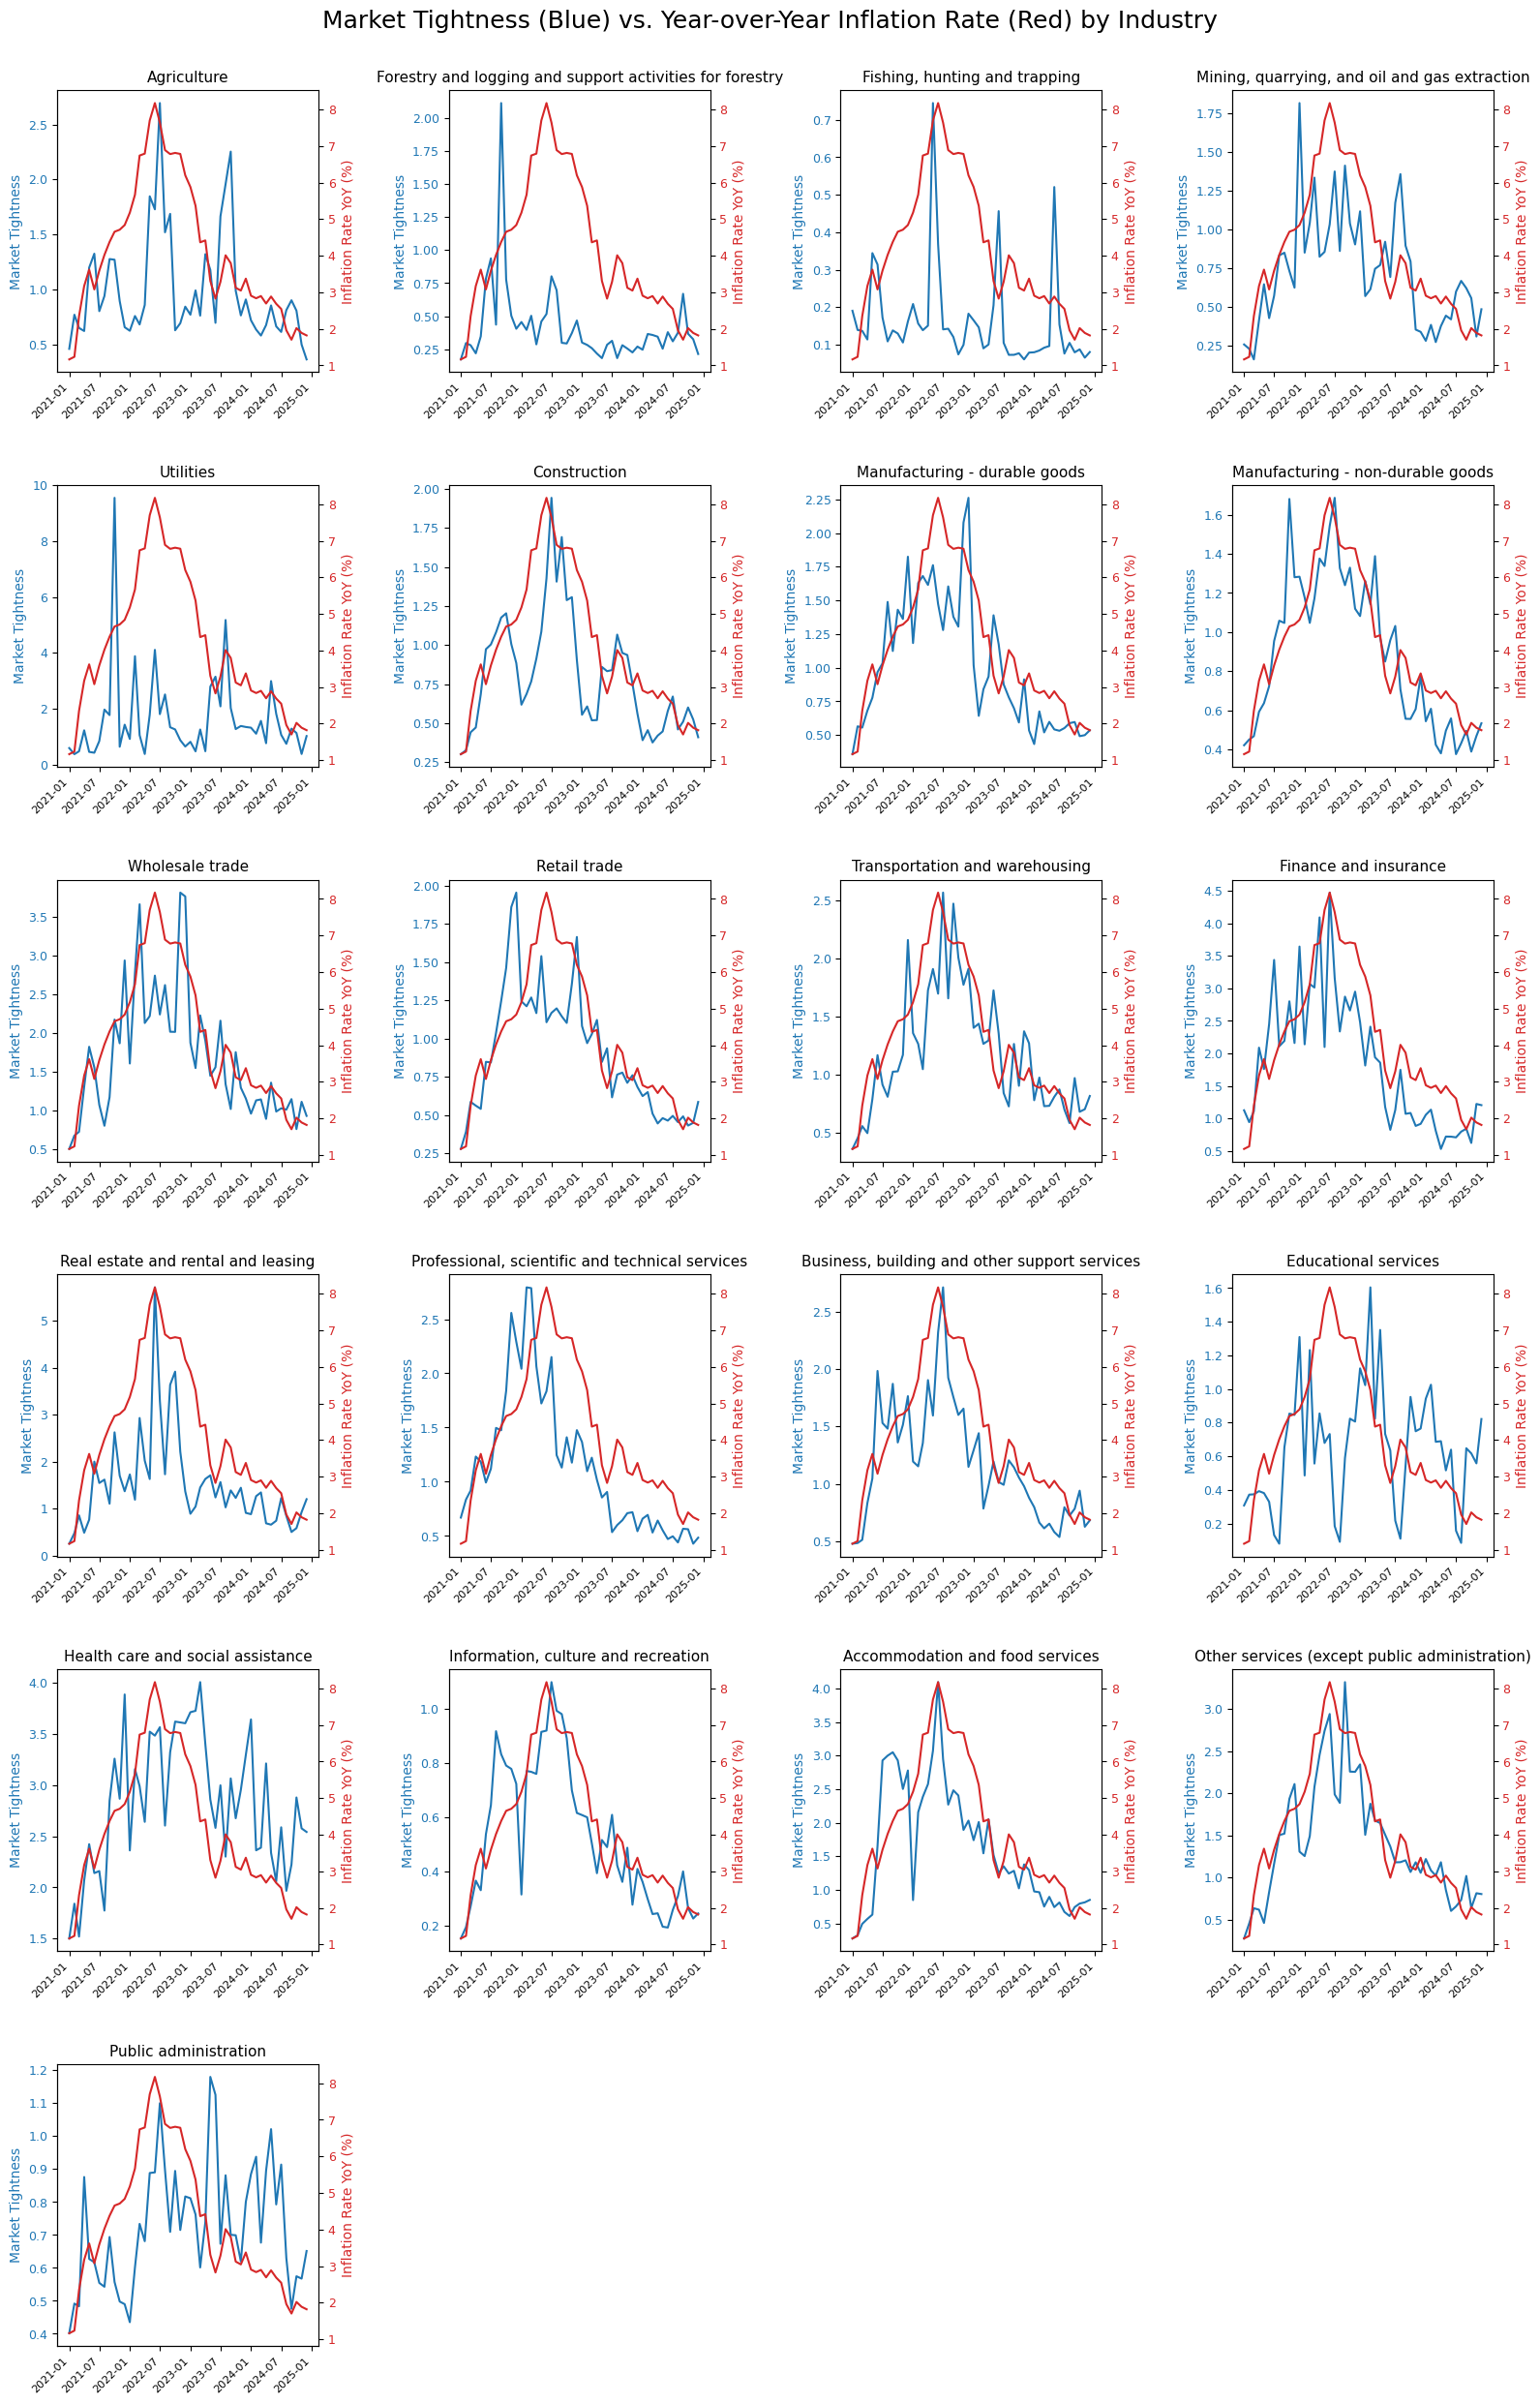

In [153]:
# Create a FacetGrid for all industries
g = sns.FacetGrid(
    industry_trends, 
    col="NAICS_21_Label", 
    col_wrap=4, 
    height=4,        
    sharex=False, 
    sharey=False
)

# Map function onto the FacetGrid
g.map_dataframe(lambda data, **kwargs: plot_dual_axis(
    data,
    left_var='Market_Tightness',
    right_var='Inflation_Rate_YoY',
    left_label='Market Tightness',
    right_label='Inflation Rate YoY (%)'
))

# Rotate x-axis labels in each facet
for ax in g.axes.flatten():
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')

# Adjust layout
plt.subplots_adjust(hspace=0.4, wspace=0.5)
plt.suptitle("Market Tightness (Blue) vs. Year-over-Year Inflation Rate (Red) by Industry", fontsize=18, y=1.02)
plt.show()


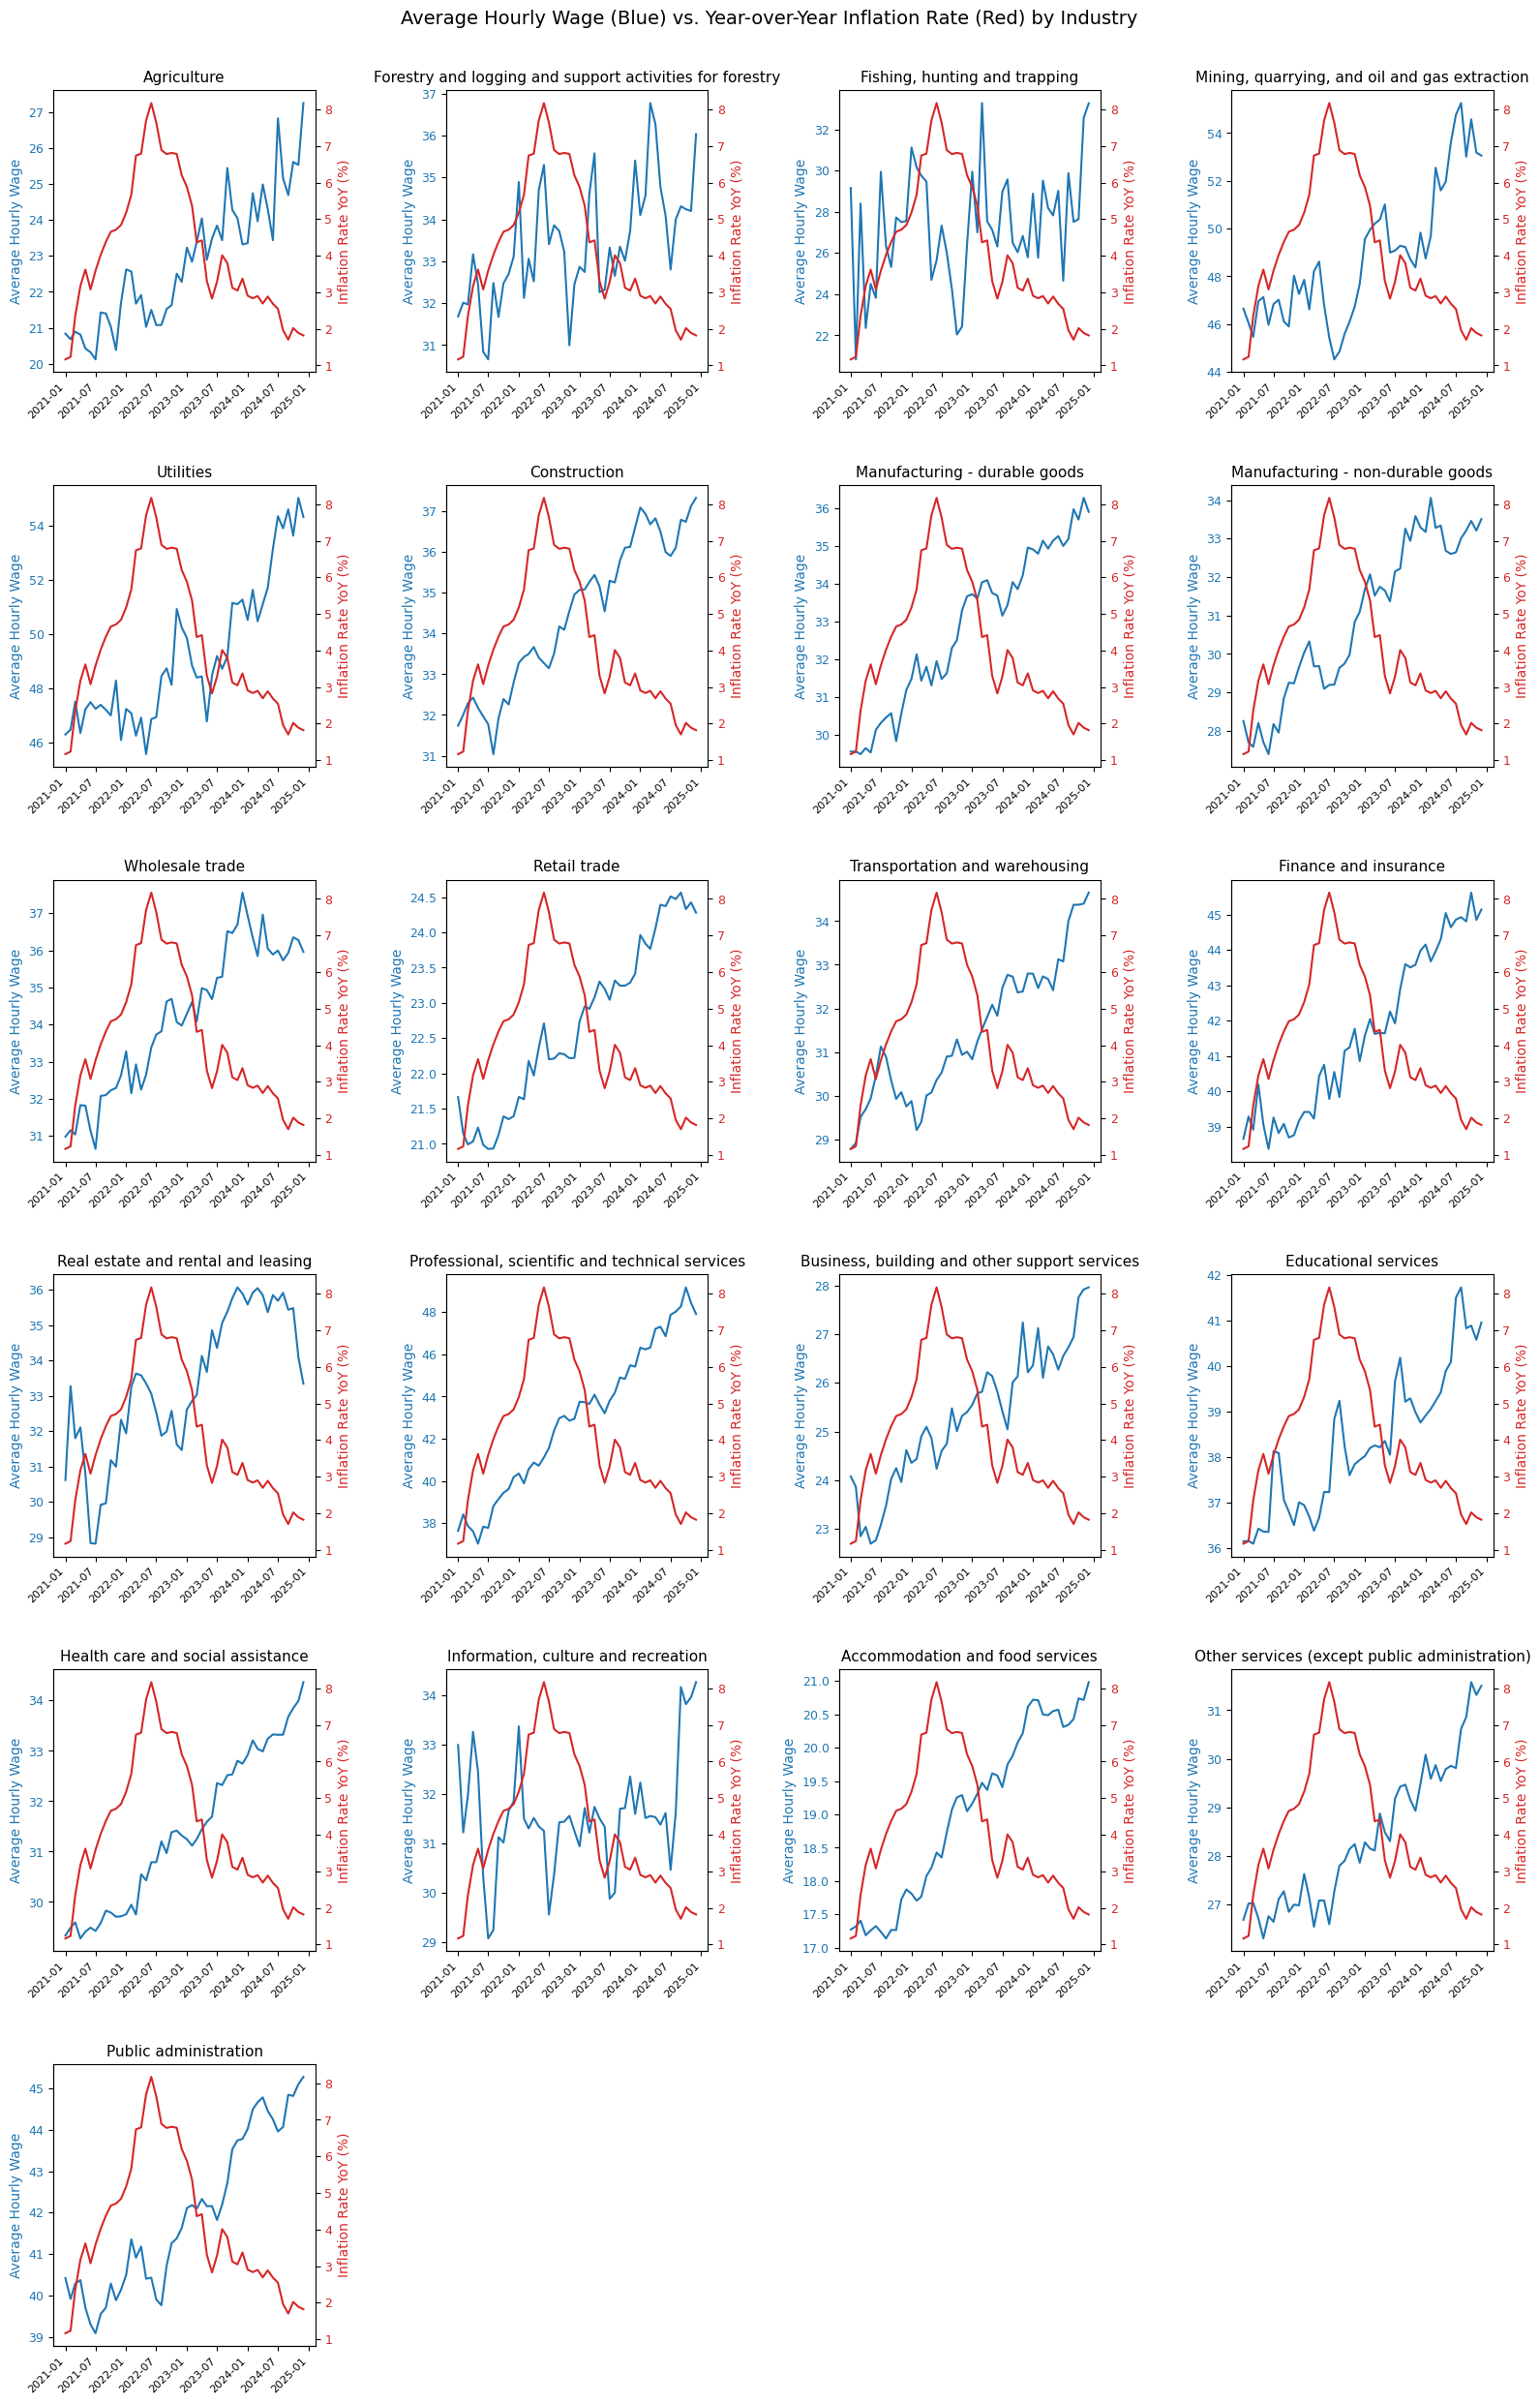

In [154]:
# Create the FacetGrid for all industries
g = sns.FacetGrid(
    industry_trends, 
    col="NAICS_21_Label", 
    col_wrap=4, 
    height=4, 
    sharex=False, 
    sharey=False
)

# Apply the reusable function using lambda to pass parameters
g.map_dataframe(lambda data, **kwargs: plot_dual_axis(
    data,
    left_var='Average_Hourly_Wage',
    right_var='Inflation_Rate_YoY',
    left_label='Average Hourly Wage',
    right_label='Inflation Rate YoY (%)'
))

# Rotate x-axis labels
for ax in g.axes.flatten():
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')

# Adjust layout and title
plt.subplots_adjust(hspace=0.4, wspace=0.5)
plt.suptitle("Average Hourly Wage (Blue) vs. Year-over-Year Inflation Rate (Red) by Industry", fontsize=14, y=1.02)
plt.show()


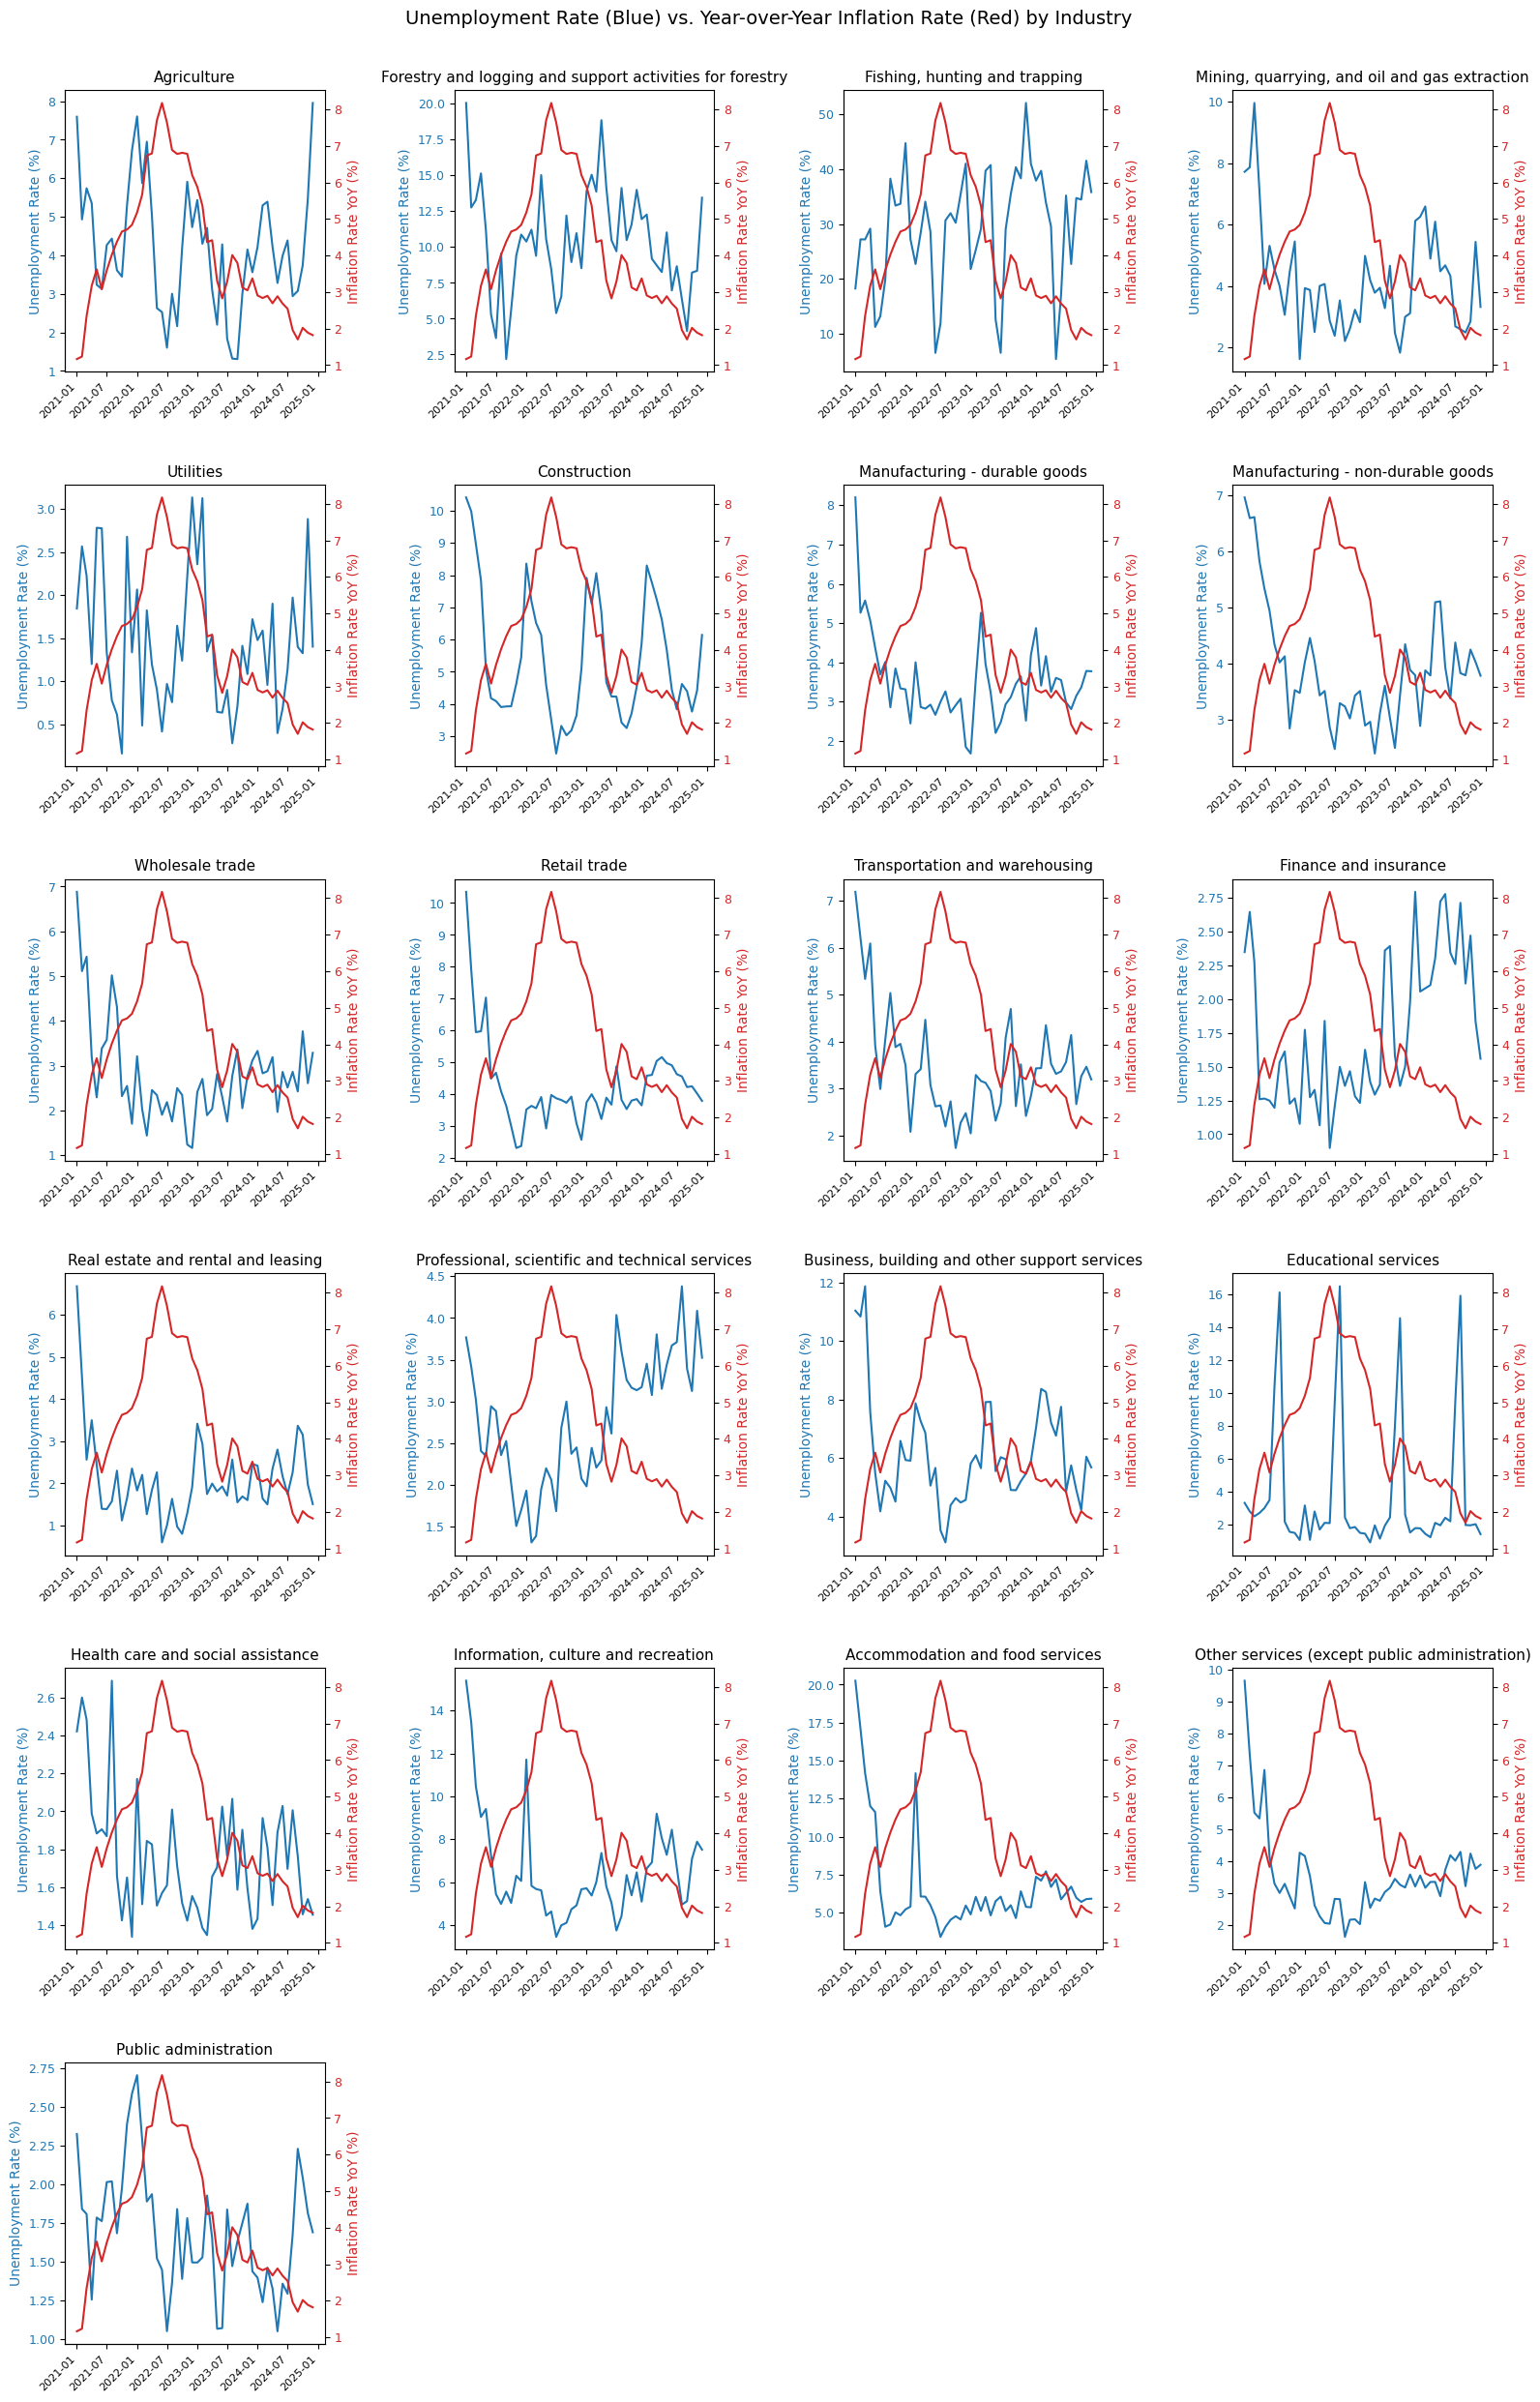

In [155]:
# Create the FacetGrid for all industries
g = sns.FacetGrid(
    industry_trends, 
    col="NAICS_21_Label", 
    col_wrap=4, 
    height=4, 
    sharex=False, 
    sharey=False
)

# Apply the reusable function using lambda to pass parameters
g.map_dataframe(lambda data, **kwargs: plot_dual_axis(
    data,
    left_var='Unemployment_Rate(%)',
    right_var='Inflation_Rate_YoY',
    left_label='Unemployment Rate (%)',
    right_label='Inflation Rate YoY (%)'
))

# Rotate x-axis labels
for ax in g.axes.flatten():
    for label in ax.get_xticklabels():
        label.set_rotation(45)
        label.set_ha('right')

# Adjust layout and title
plt.subplots_adjust(hspace=0.4, wspace=0.5)
plt.suptitle("Unemployment Rate (Blue) vs. Year-over-Year Inflation Rate (Red) by Industry", fontsize=14, y=1.02)
plt.show()


### Correlation Matrices

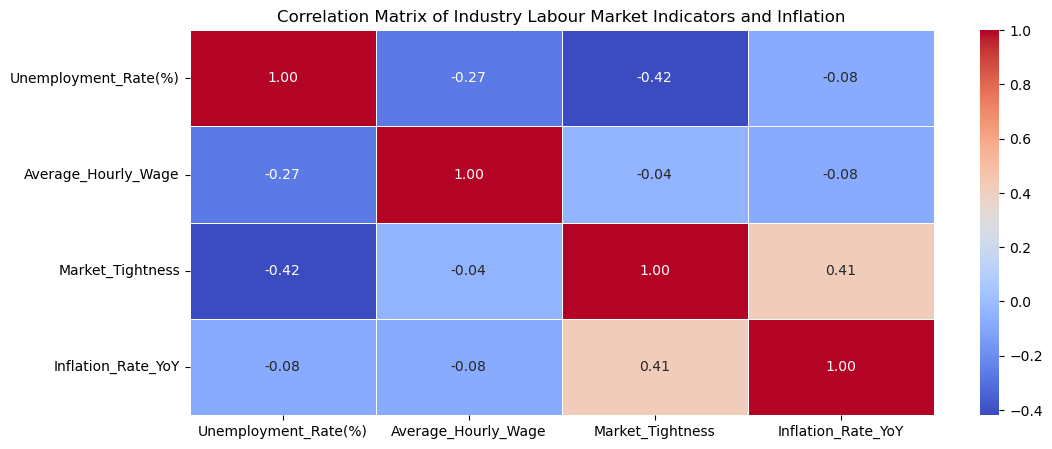

In [156]:
# Overall correlation matrix for all industries
# Listing variables of interest
var_of_interest = (['Unemployment_Rate(%)', 'Average_Hourly_Wage', 'Market_Tightness','Inflation_Rate_YoY'])

# Compute correlation matrix
industry_trends_corr = industry_trends[var_of_interest].corr()

# Plot the correlation matrix
plt.figure(figsize=(12, 5))
sns.heatmap(industry_trends[var_of_interest].corr(), annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Matrix of Industry Labour Market Indicators and Inflation")
plt.show()

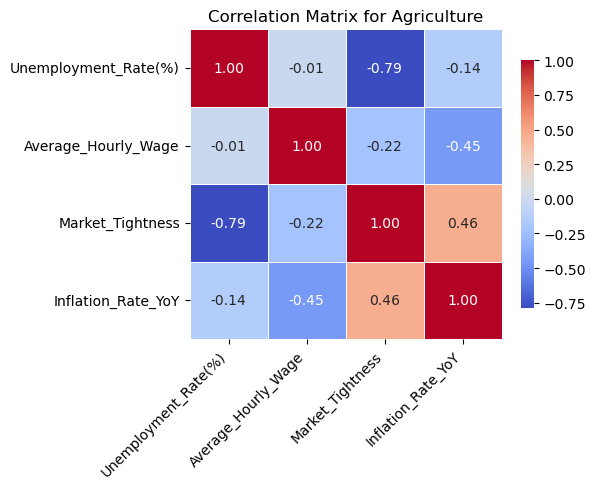

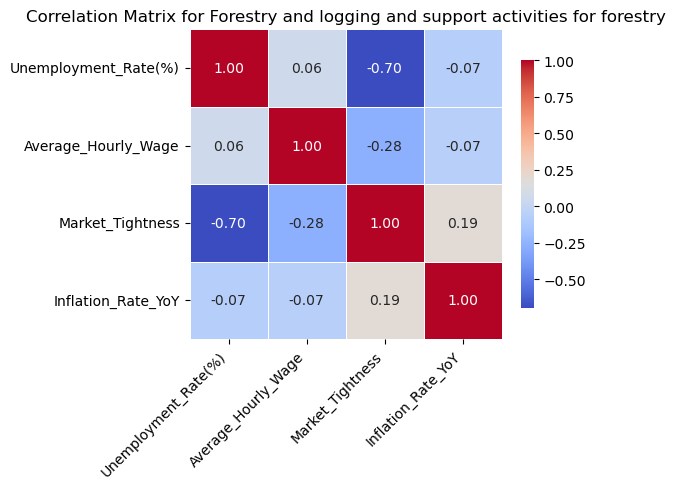

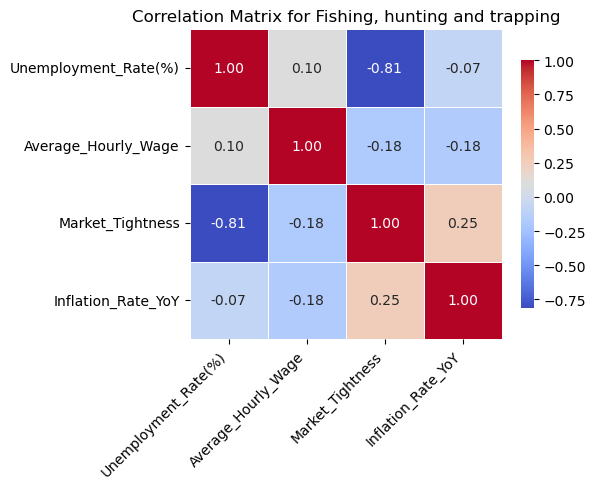

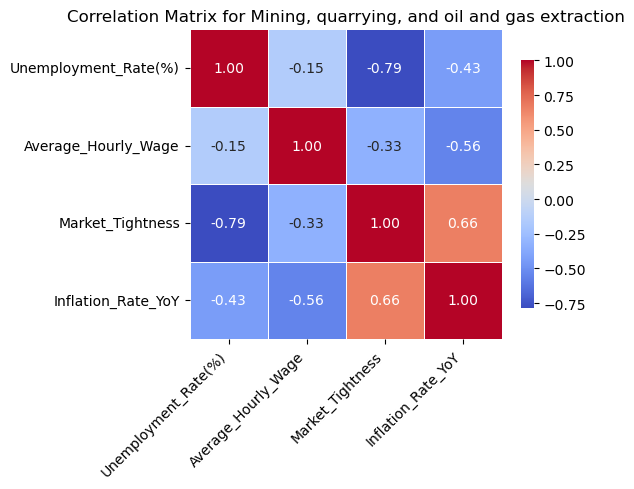

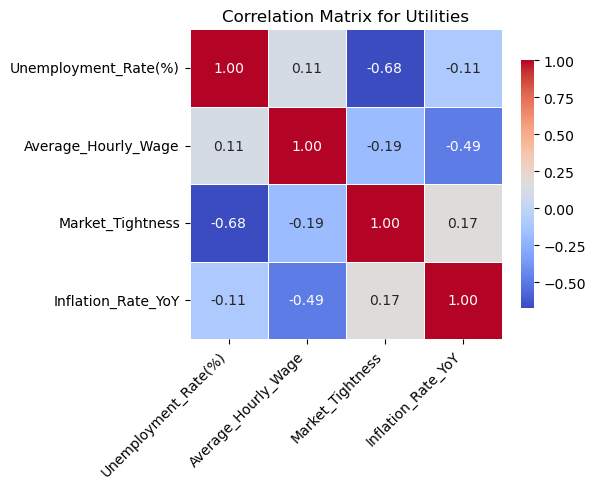

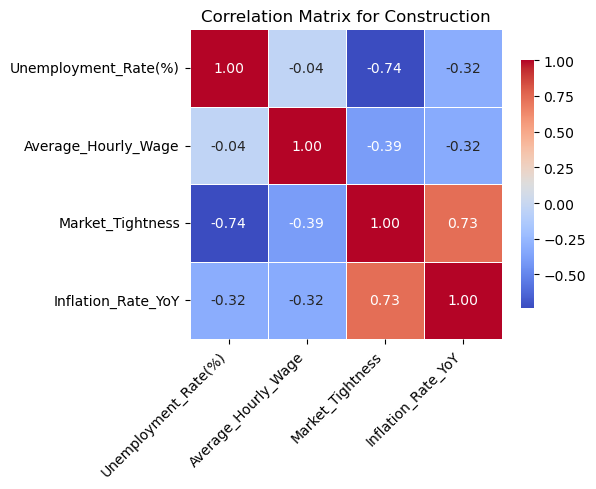

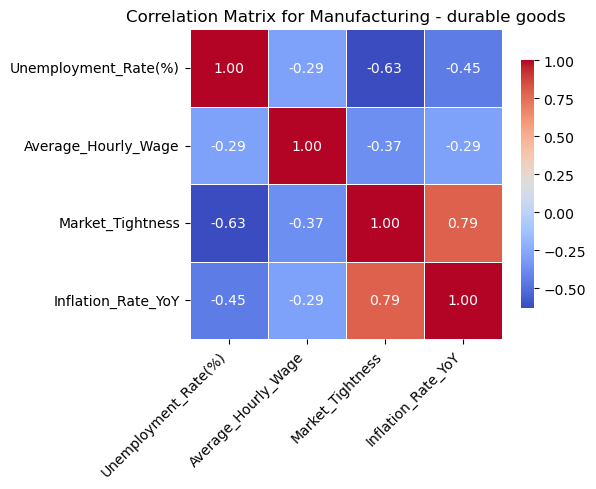

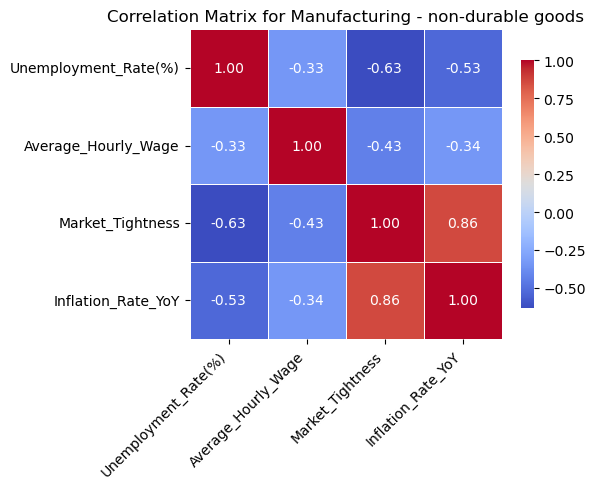

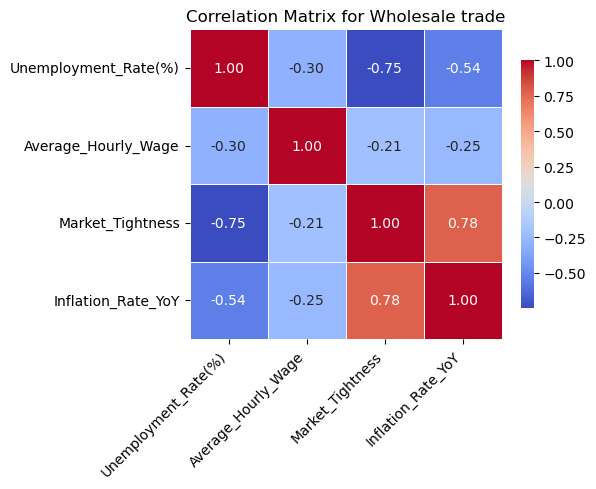

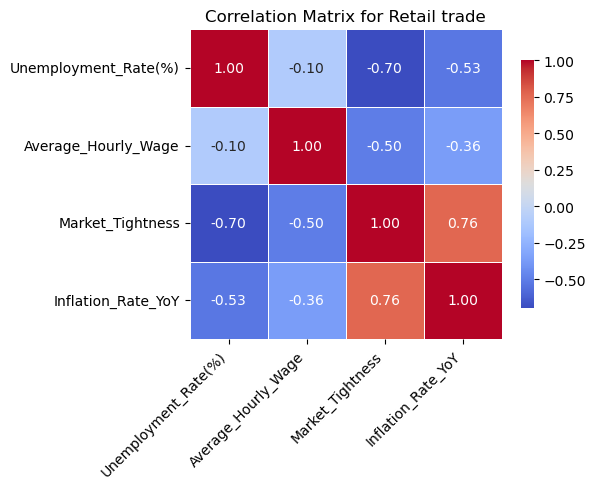

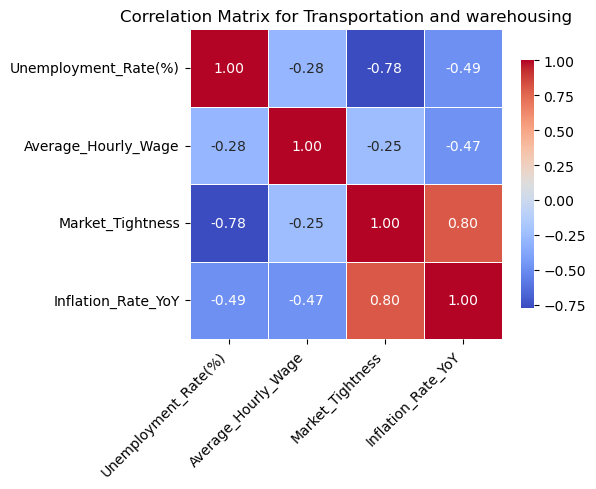

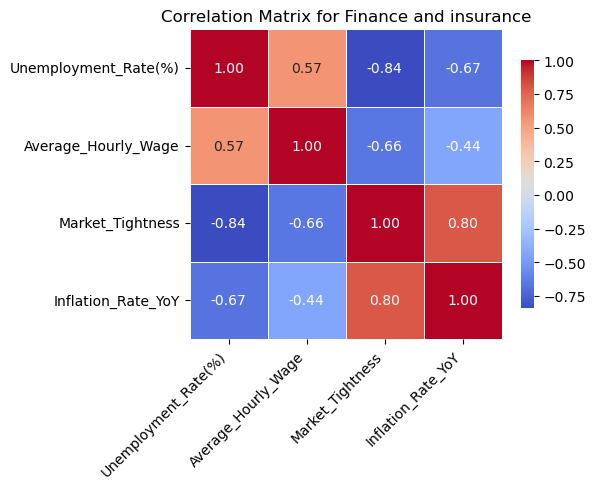

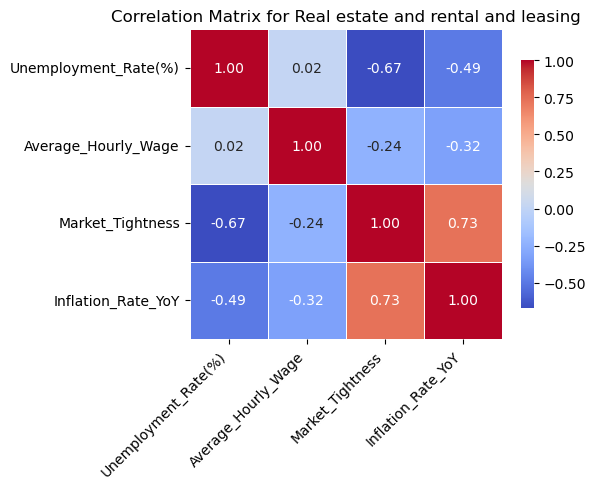

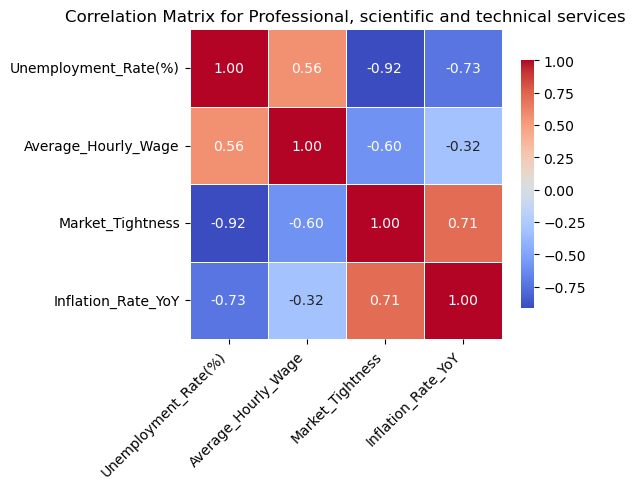

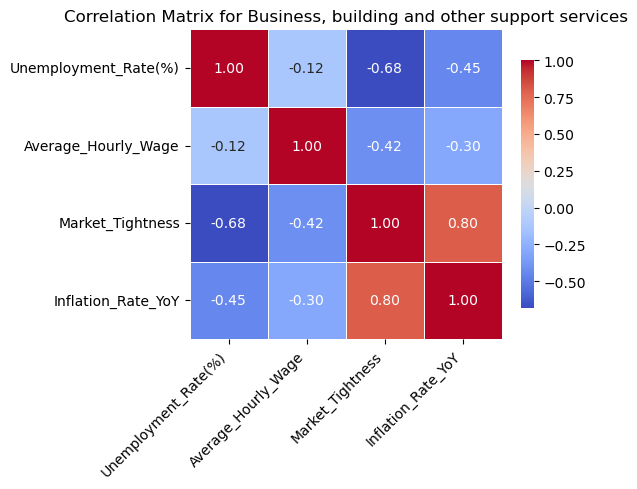

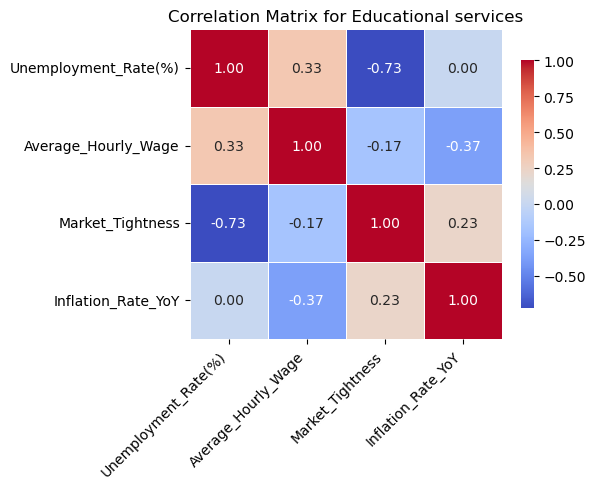

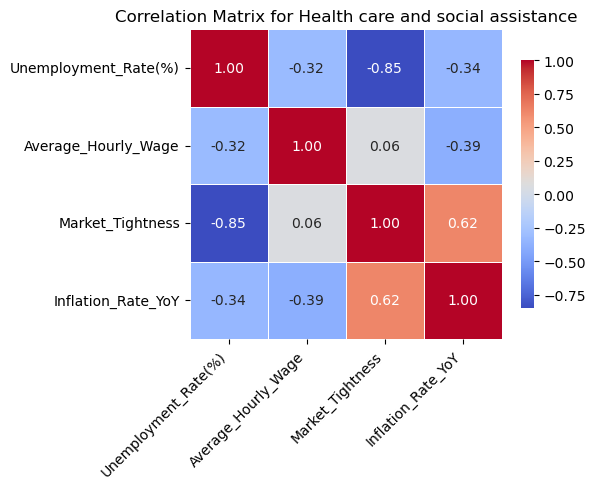

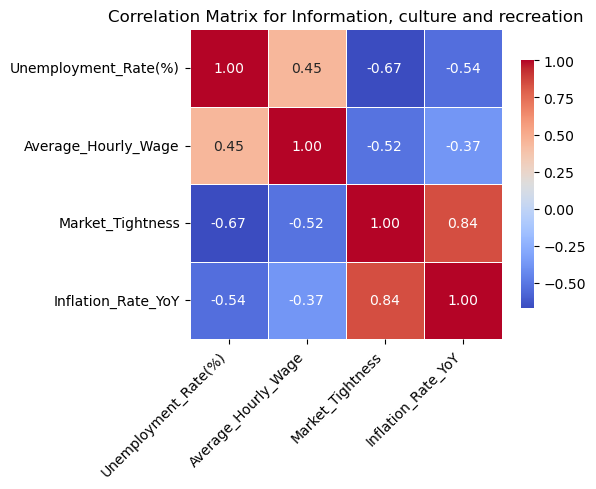

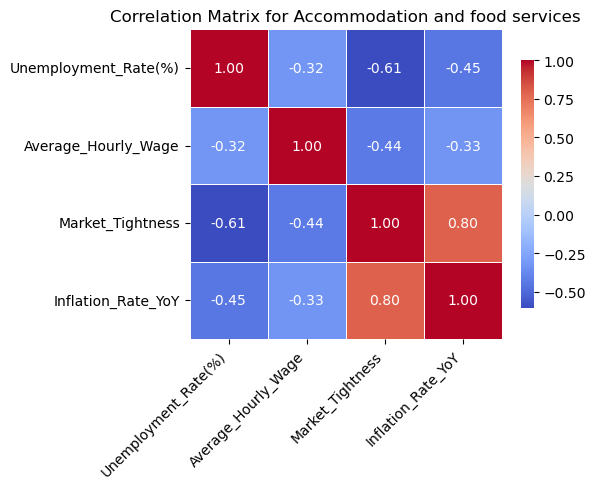

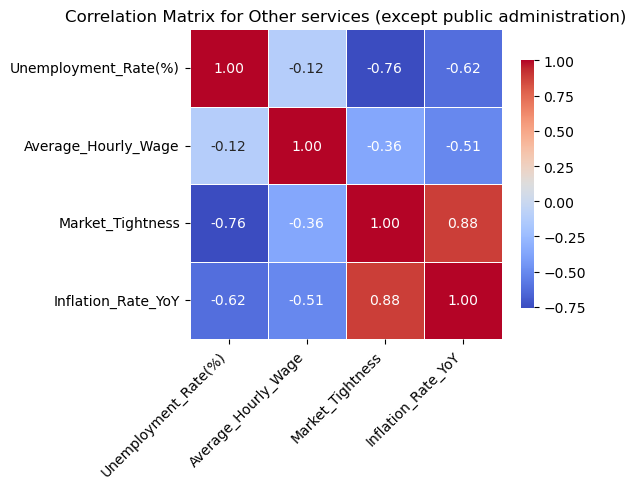

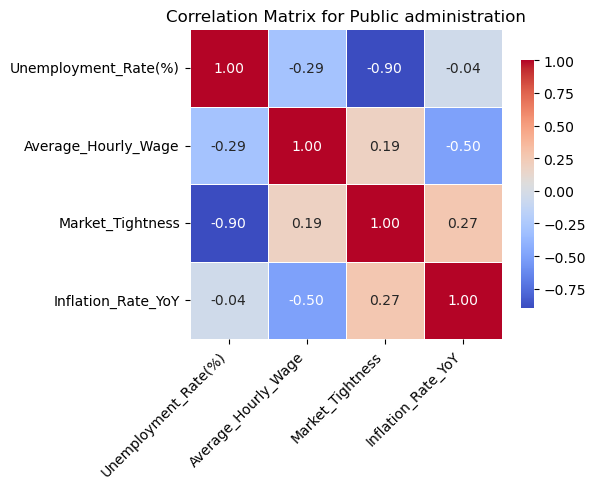

In [157]:
# Correlation matrix per industry

# Variables to include in correlation
selected_vars = ['Unemployment_Rate(%)', 'Average_Hourly_Wage', 'Market_Tightness', 'Inflation_Rate_YoY']

# Get all unique industry labels
all_industries = industry_trends['NAICS_21_Label'].dropna().unique()

# Loop through each industry
for industry in all_industries:
    # Filter for that industry
    df_ind = industry_trends[industry_trends['NAICS_21_Label'] == industry]
    
    # Drop rows with missing values
    df_subset = df_ind[selected_vars].dropna()
    
    # Only compute if there's enough data
    if len(df_subset) < 3:
        continue

    # Compute correlation matrix
    corr_matrix = df_subset.corr()
    
    # Plot heatmap
    plt.figure(figsize=(6, 5))
    sns.heatmap(
        corr_matrix,
        annot=True,
        cmap="coolwarm",
        fmt=".2f",
        linewidths=0.5,
        cbar_kws={"shrink": 0.8}
    )
    plt.title(f"Correlation Matrix for {industry}", fontsize=12)
    plt.xticks(rotation=45, ha="right")
    plt.yticks(rotation=0)
    plt.tight_layout()
    plt.show()

## Demographic Influence on Labour Market Outcomes

In [158]:
def calculate_labour_market_indicators(LFS, category):
    """
    Calculate the weighted Labour Force Participation Rate (LFPR), Unemployment Rate, and Average Hourly Wage by a given category.

    Parameters:
    LFS (pd.DataFrame): The DataFrame containing the labour force survey data.
    category (str): The column name for which the indicators should be calculated.

    Returns:
    Tuple[pd.DataFrame, pd.DataFrame]: 
        - Monthly DataFrame with LFPR, Unemployment Rate, and Average Hourly Wage.
        - Overall DataFrame with average LFPR, Unemployment Rate, and Hourly Wage.
    """

    # Calculate total weighted labour force per category and month
    labour_force = (
        LFS[LFS['lf_status'].isin([1, 2, 3])]
        .groupby(['REF_DATE', category], as_index=False, observed=False)['final_wt']
        .sum()
        .rename(columns={'final_wt': 'weighted_labour_force'})
    )

    # Calculate total weighted working-age population per category and month
    working_age_pop = (
        LFS.groupby(['REF_DATE', category], as_index=False, observed=False)['final_wt']
        .sum()
        .rename(columns={'final_wt': 'weighted_working_age_pop'})
    )

    # Calculate total weighted unemployed per category and month
    unemployed_df = LFS[LFS["lf_status"] == 3]
    unemployed_per_month = (
        unemployed_df.groupby(['REF_DATE', category], as_index=False, observed=False)['final_wt']
        .sum()
        .rename(columns={'final_wt': 'weighted_unemployed'})
    )

    # Calculate weighted average hourly wage per month and category
    employed = LFS[LFS['lf_status'].isin([1, 2])]
    employed_df = employed[
        (employed['hourly_wage'] > 0) &  # ignore zero wages
        (~employed['hourly_wage'].isna())
    ].copy()  

    wage_per_month = (
        employed_df.groupby(['REF_DATE', category], as_index=False, observed=False)[['hourly_wage', 'final_wt']]
        .apply(lambda x: pd.Series({
            "avg_hourly_wage": (x['hourly_wage'] * x['final_wt']).sum() / x['final_wt'].sum()
        }))
        .reset_index(drop=True)  # Fix index issue
    )

    jobless_df = LFS[(LFS['lf_status'] == 3) & (LFS['duration_jobless'] > 0)].copy()

    duration_per_month = (
        jobless_df.groupby(['REF_DATE', category], as_index=False, observed=False)[['duration_jobless', 'final_wt']]
        .apply(lambda x: pd.Series({
            "avg_duration_jobless": (x['duration_jobless'] * x['final_wt']).sum() / x['final_wt'].sum()
        }))
        .reset_index(drop=True)
    )

    # Merge all DataFrames
    indicators_df = labour_force.merge(working_age_pop, on=['REF_DATE', category], how='left')
    indicators_df = indicators_df.merge(unemployed_per_month, on=['REF_DATE', category], how='left')
    indicators_df = indicators_df.merge(wage_per_month, on=['REF_DATE', category], how='left')
    indicators_df = indicators_df.merge(duration_per_month, on=['REF_DATE', category], how='left')

    # Compute LFPR and Unemployment Rate for monthly data
    indicators_df['LFPR_rate'] = (
        (indicators_df['weighted_labour_force'] / indicators_df['weighted_working_age_pop']) * 100
    ).round(2)

    indicators_df['unemployment_rate'] = (
        (indicators_df['weighted_unemployed'] / indicators_df['weighted_labour_force']) * 100
    ).round(2)

    # Calculate overall averages across all months
    total_labour_force = labour_force.groupby(category, as_index=False, observed=False)['weighted_labour_force'].sum()
    total_working_pop = working_age_pop.groupby(category, as_index=False, observed=False)['weighted_working_age_pop'].sum()
    total_unemployed = unemployed_per_month.groupby(category, as_index=False, observed=False)['weighted_unemployed'].sum()

    # Overall weighted average hourly wage
    overall_wage = (
        employed_df.groupby(category, as_index=False, observed=False)[['hourly_wage', 'final_wt']]
        .apply(lambda x: pd.Series({
            "overall_avg_hourly_wage": (x['hourly_wage'] * x['final_wt']).sum() / x['final_wt'].sum()
        }))
        .reset_index(drop=True)
    )

    # Overall jobless duration
    overall_duration = (
        jobless_df.groupby(category, as_index=False, observed=False)[['duration_jobless', 'final_wt']]
        .apply(lambda x: pd.Series({
            "overall_avg_duration_jobless": (x['duration_jobless'] * x['final_wt']).sum() / x['final_wt'].sum()
        }))
        .reset_index(drop=True)
    )

    overall_df = total_labour_force.copy()
    overall_df.rename(columns={'weighted_labour_force': 'sum_weighted_labour_force'}, inplace=True)

    # Merge totals: Note that total_working_pop has the column "weighted_working_age_pop"
    overall_df = overall_df.merge(total_working_pop, on=category, how='left')
    overall_df = overall_df.merge(total_unemployed, on=category, how='left')
    # Rename the merged columns appropriately
    overall_df.rename(columns={
        'weighted_working_age_pop': 'sum_weighted_working_pop',
        'weighted_unemployed': 'sum_weighted_unemployed'
    }, inplace=True)

    # Compute overall rates
    overall_df["overall_LFPR_rate"] = (
        overall_df["sum_weighted_labour_force"] / overall_df["sum_weighted_working_pop"] * 100
    ).round(2)

    overall_df["overall_unemployment_rate"] = (
        overall_df["sum_weighted_unemployed"] / overall_df["sum_weighted_labour_force"] * 100
    ).round(2)

    # Merge with wage & duration data
    overall_df = overall_df.merge(overall_wage, on=category, how="left")
    overall_df = overall_df.merge(overall_duration, on=category, how="left")

    return indicators_df, overall_df

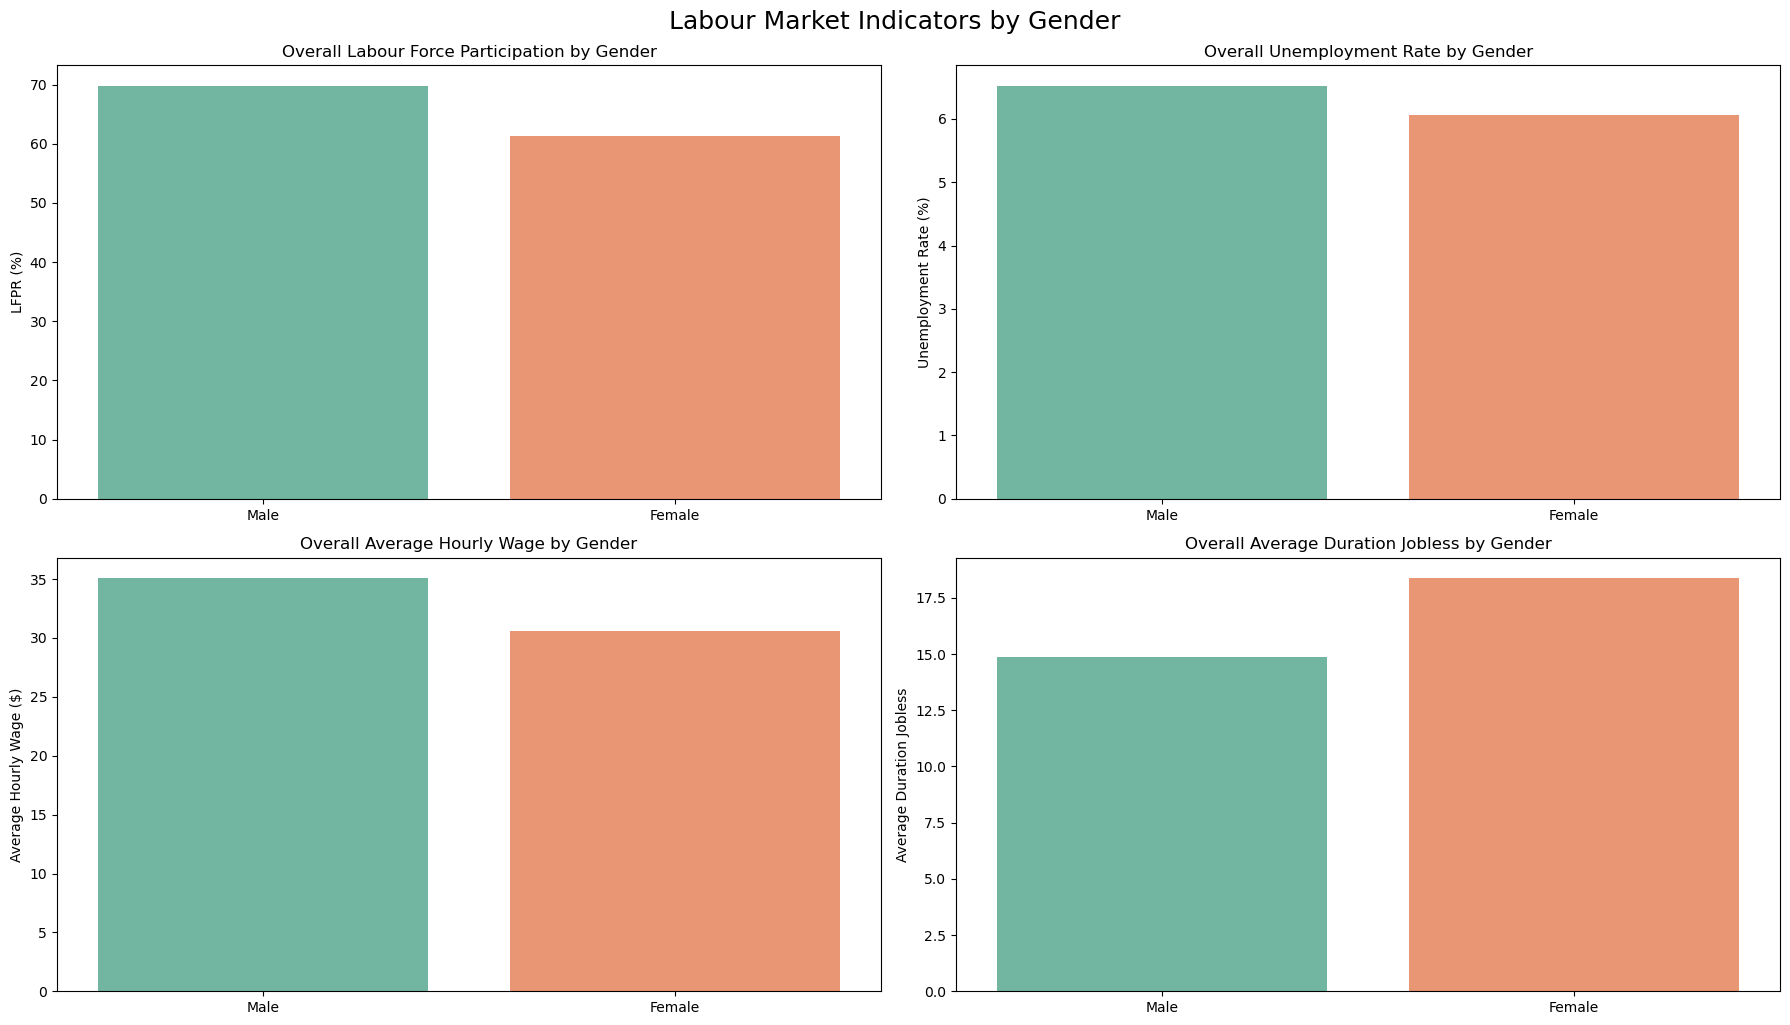

In [159]:
# Calculate labour market indicators by Gender
monthly_rates_by_gender, overall_rates_by_gender = calculate_labour_market_indicators(LFS, 'gender')

# Mapping for gender
gender_labels = {1: 'Male', 2: 'Female'}

# Copy data and apply label mapping
plot_data = overall_rates_by_gender.copy()
plot_data['gender'] = plot_data['gender'].astype('object').replace(gender_labels)

# Set categorical order for consistent plotting
plot_data['gender'] = pd.Categorical(
    plot_data['gender'],
    categories=['Male', 'Female'],
    ordered=True
)

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Plot 1: Overall Labour Force Participation Rate by Gender
sns.barplot(data=plot_data, x='gender', y='overall_LFPR_rate', hue='gender', ax=axes[0,0], palette='Set2', legend=False)
axes[0,0].set_title('Overall Labour Force Participation by Gender')
axes[0,0].set_ylabel('LFPR (%)')
axes[0,0].set_xlabel('')

# Plot 2: Overall Unemployment Rate by Gender
sns.barplot(data=plot_data, x='gender', y='overall_unemployment_rate', hue='gender', ax=axes[0,1], palette='Set2', legend=False)
axes[0,1].set_title('Overall Unemployment Rate by Gender')
axes[0,1].set_ylabel('Unemployment Rate (%)')
axes[0,1].set_xlabel('')

# Plot 3: Overall Hourly Wage by Gender
sns.barplot(data=plot_data, x='gender', y='overall_avg_hourly_wage', hue='gender', ax=axes[1,0], palette='Set2', legend=False)
axes[1,0].set_title('Overall Average Hourly Wage by Gender')
axes[1,0].set_ylabel('Average Hourly Wage ($)')
axes[1,0].set_xlabel('')

# Plot 4: Overall Average Duration Jobless by Gender
sns.barplot(data=plot_data, x='gender', y='overall_avg_duration_jobless', hue='gender', ax=axes[1,1], palette='Set2', legend=False)
axes[1,1].set_title('Overall Average Duration Jobless by Gender')
axes[1,1].set_ylabel('Average Duration Jobless')
axes[1,1].set_xlabel('')

# Adjust layout and spacing
plt.tight_layout()
plt.suptitle("Labour Market Indicators by Gender", fontsize=18, y=1.02)
plt.show()


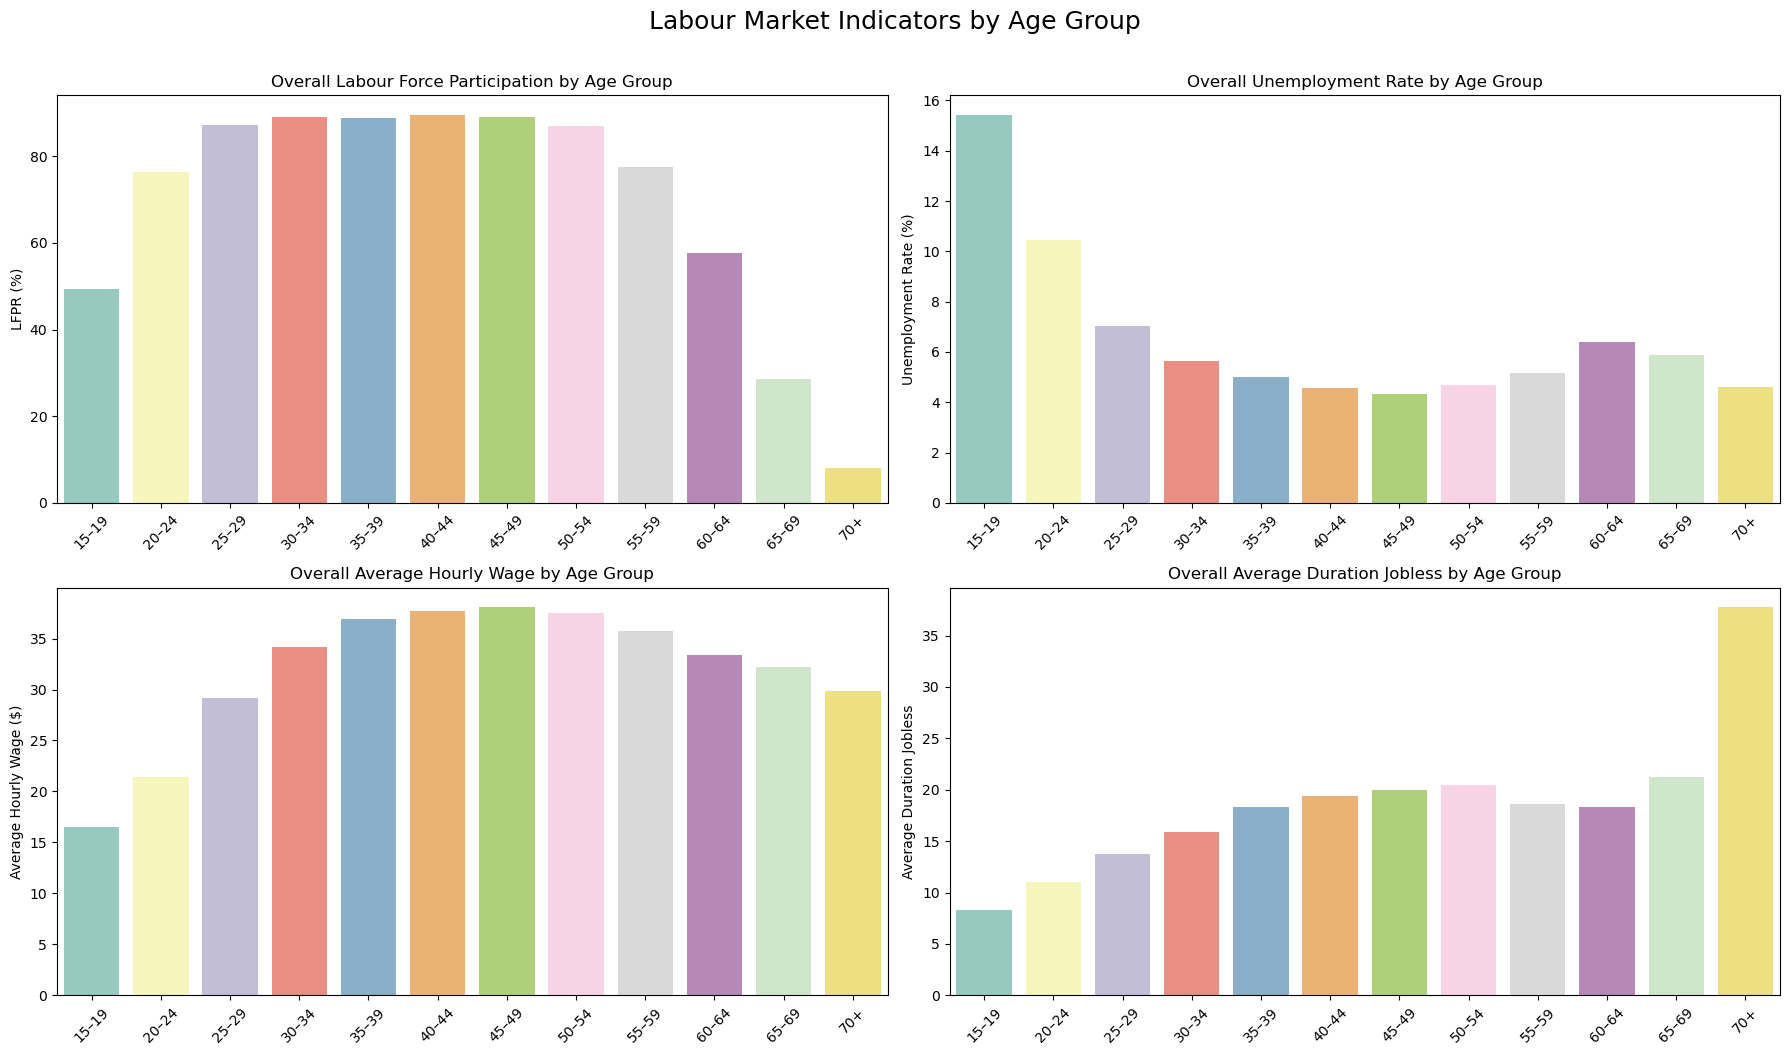

In [160]:
# Calculate labour market indicators by Age Group
monthly_rates_by_age, overall_rates_by_age = calculate_labour_market_indicators(LFS, 'age_5y_group')

# Define age group labels
age_labels = {
    1: '15–19',
    2: '20–24',
    3: '25–29',
    4: '30–34',
    5: '35–39',
    6: '40–44',
    7: '45–49',
    8: '50–54',
    9: '55–59',
    10: '60–64',
    11: '65–69',
    12: '70+'
}

# Prepare data with mapped labels
plot_data = overall_rates_by_age.copy()
plot_data['age_5y_group'] = plot_data['age_5y_group'].astype('object').replace(age_labels)

# Ensure consistent order in plotting
plot_data['age_5y_group'] = pd.Categorical(
    plot_data['age_5y_group'],
    categories=['15–19', '20–24', '25–29', '30–34', '35–39', '40–44',
                '45–49', '50–54', '55–59', '60–64', '65–69', '70+'],
    ordered=True
)

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Plot 1: LFPR
sns.barplot(data=plot_data, x='age_5y_group', y='overall_LFPR_rate', hue='age_5y_group', ax=axes[0,0], palette='Set3', legend=False)
axes[0,0].set_title('Overall Labour Force Participation by Age Group')
axes[0,0].set_ylabel('LFPR (%)')
axes[0,0].set_xlabel('')
axes[0,0].tick_params(axis='x', rotation=45)

# Plot 2: Unemployment Rate
sns.barplot(data=plot_data, x='age_5y_group', y='overall_unemployment_rate', hue='age_5y_group', ax=axes[0,1], palette='Set3', legend=False)
axes[0,1].set_title('Overall Unemployment Rate by Age Group')
axes[0,1].set_ylabel('Unemployment Rate (%)')
axes[0,1].set_xlabel('')
axes[0,1].tick_params(axis='x', rotation=45)

# Plot 3: Hourly Wage
sns.barplot(data=plot_data, x='age_5y_group', y='overall_avg_hourly_wage', hue='age_5y_group', ax=axes[1,0], palette='Set3', legend=False)
axes[1,0].set_title('Overall Average Hourly Wage by Age Group')
axes[1,0].set_ylabel('Average Hourly Wage ($)')
axes[1,0].set_xlabel('')
axes[1,0].tick_params(axis='x', rotation=45)

# Plot 4: Duration Jobless
sns.barplot(data=plot_data, x='age_5y_group', y='overall_avg_duration_jobless', hue='age_5y_group', ax=axes[1,1], palette='Set3', legend=False)
axes[1,1].set_title('Overall Average Duration Jobless by Age Group')
axes[1,1].set_ylabel('Average Duration Jobless')
axes[1,1].set_xlabel('')
axes[1,1].tick_params(axis='x', rotation=45)

# Adjust layout
plt.tight_layout()
plt.suptitle("Labour Market Indicators by Age Group", fontsize=18, y=1.05)
plt.show()


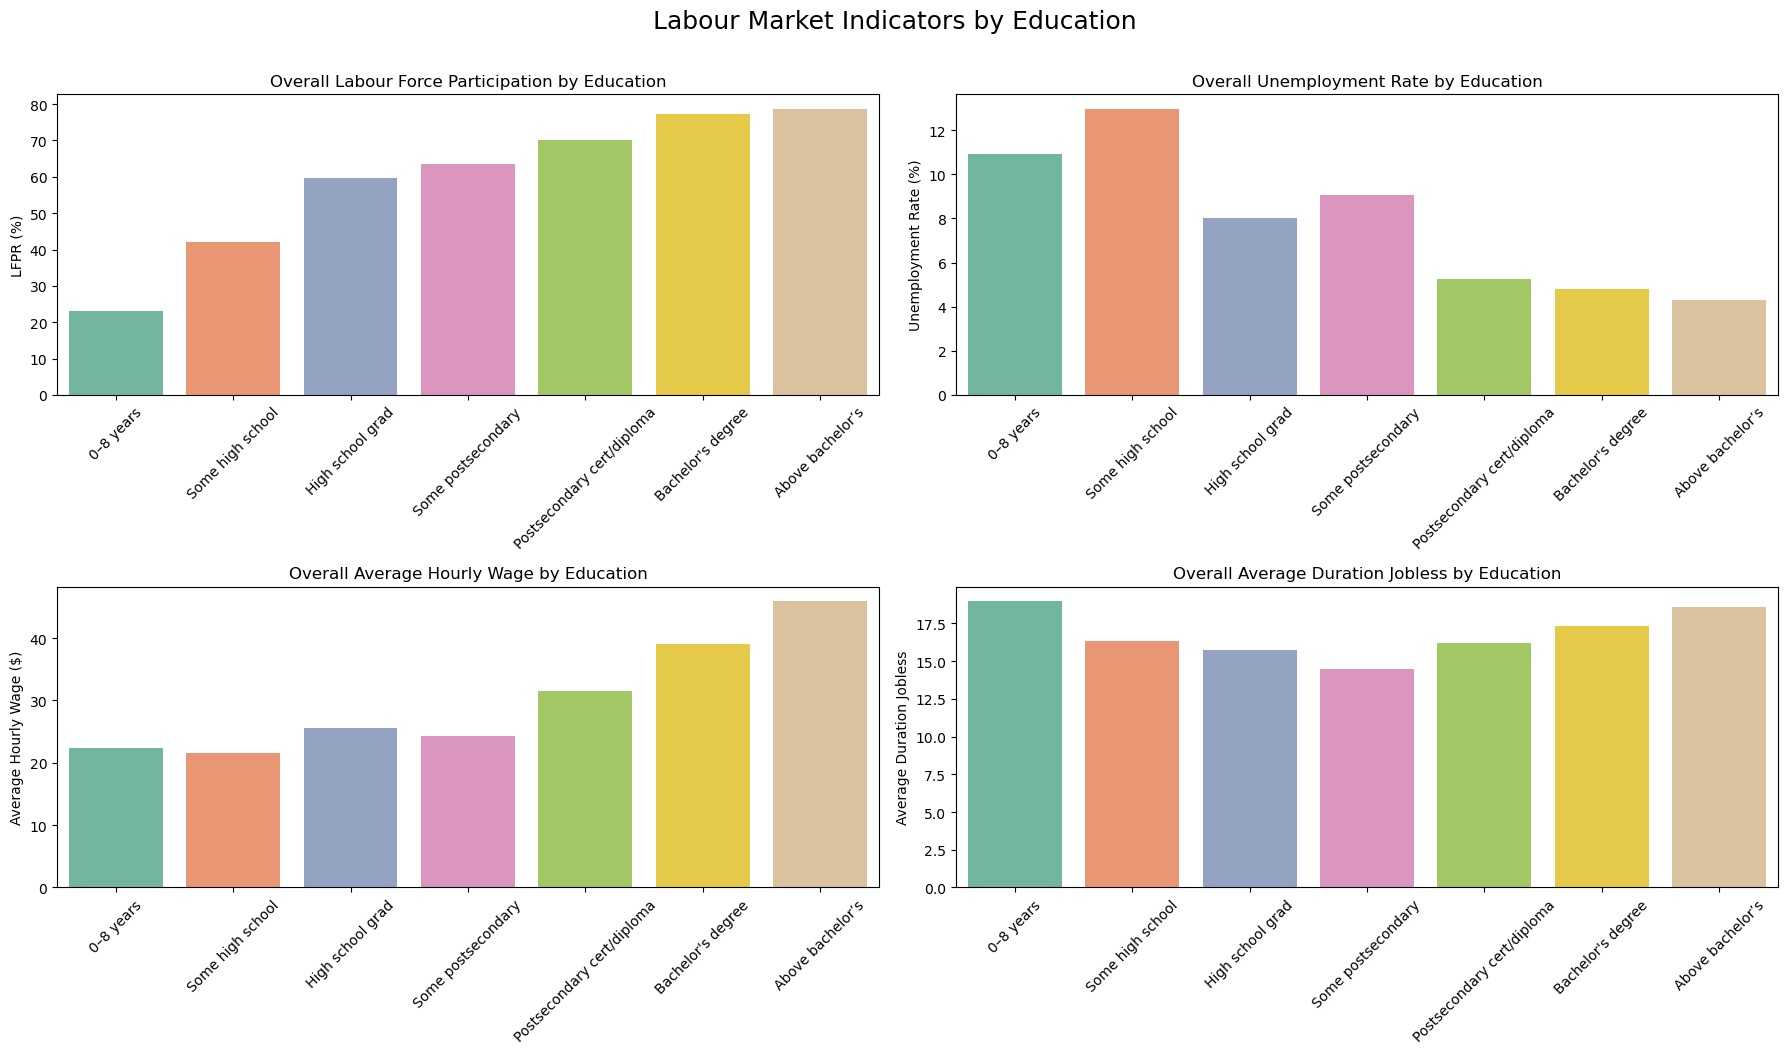

In [161]:
# Calculate labour market indicators by Education
monthly_rates_by_education, overall_rates_by_education = calculate_labour_market_indicators(LFS, 'education')

# Define education level labels
education_labels = {
    0: '0–8 years',
    1: 'Some high school',
    2: 'High school grad',
    3: 'Some postsecondary',
    4: 'Postsecondary cert/diploma',
    5: "Bachelor's degree",
    6: 'Above bachelor’s'
}

# Prepare data with mapped labels
plot_data = overall_rates_by_education.copy()
plot_data['education'] = plot_data['education'].astype('object').replace(education_labels)

# Ensure consistent plotting order
plot_data['education'] = pd.Categorical(
    plot_data['education'],
    categories=[
        '0–8 years',
        'Some high school',
        'High school grad',
        'Some postsecondary',
        'Postsecondary cert/diploma',
        "Bachelor's degree",
        'Above bachelor’s'
    ],
    ordered=True
)

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Plot 1: LFPR
sns.barplot(data=plot_data, x='education', y='overall_LFPR_rate', hue='education', ax=axes[0,0], palette='Set2', legend=False)
axes[0,0].set_title('Overall Labour Force Participation by Education')
axes[0,0].set_ylabel('LFPR (%)')
axes[0,0].set_xlabel('')
axes[0,0].tick_params(axis='x', rotation=45)

# Plot 2: Unemployment Rate
sns.barplot(data=plot_data, x='education', y='overall_unemployment_rate', hue='education', ax=axes[0,1], palette='Set2', legend=False)
axes[0,1].set_title('Overall Unemployment Rate by Education')
axes[0,1].set_ylabel('Unemployment Rate (%)')
axes[0,1].set_xlabel('')
axes[0,1].tick_params(axis='x', rotation=45)

# Plot 3: Hourly Wage
sns.barplot(data=plot_data, x='education', y='overall_avg_hourly_wage', hue='education', ax=axes[1,0], palette='Set2', legend=False)
axes[1,0].set_title('Overall Average Hourly Wage by Education')
axes[1,0].set_ylabel('Average Hourly Wage ($)')
axes[1,0].set_xlabel('')
axes[1,0].tick_params(axis='x', rotation=45)

# Plot 4: Duration Jobless
sns.barplot(data=plot_data, x='education', y='overall_avg_duration_jobless', hue='education', ax=axes[1,1], palette='Set2', legend=False)
axes[1,1].set_title('Overall Average Duration Jobless by Education')
axes[1,1].set_ylabel('Average Duration Jobless')
axes[1,1].set_xlabel('')
axes[1,1].tick_params(axis='x', rotation=45)

# Adjust layout
plt.tight_layout()
plt.suptitle("Labour Market Indicators by Education", fontsize=18, y=1.05)
plt.show()


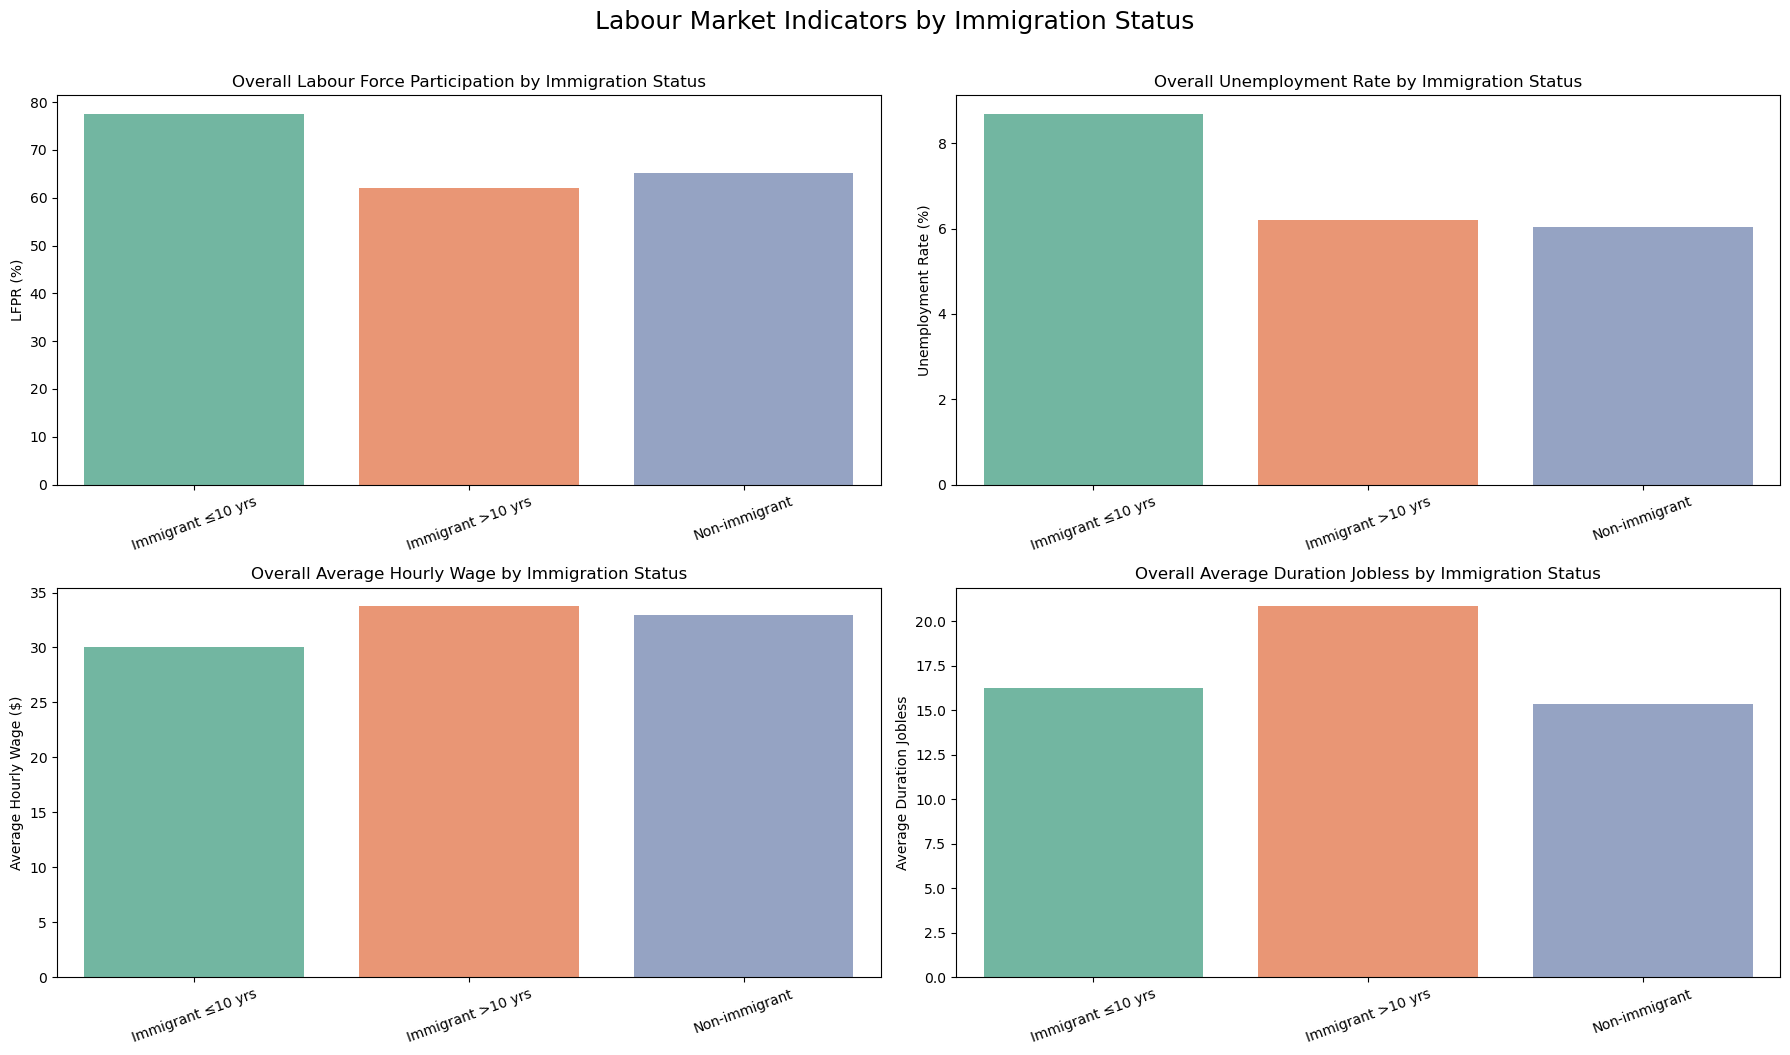

In [162]:
# Calculate labour market indicators by Immigration Status
monthly_rates_by_immigration, overall_rates_by_immigration = calculate_labour_market_indicators(LFS, 'immigration_stat')

# Define immigration status labels
immigration_labels = {
    1: 'Immigrant ≤10 yrs',
    2: 'Immigrant >10 yrs',
    3: 'Non-immigrant'
}

# Prepare data with mapped labels
plot_data = overall_rates_by_immigration.copy()
plot_data['immigration_stat'] = plot_data['immigration_stat'].astype('object').replace(immigration_labels)

# Set category order for consistent plotting
plot_data['immigration_stat'] = pd.Categorical(
    plot_data['immigration_stat'],
    categories=['Immigrant ≤10 yrs', 'Immigrant >10 yrs', 'Non-immigrant'],
    ordered=True
)

# Create subplots
fig, axes = plt.subplots(2, 2, figsize=(18, 10))

# Plot 1: LFPR
sns.barplot(data=plot_data, x='immigration_stat', y='overall_LFPR_rate', hue='immigration_stat', ax=axes[0,0], palette='Set2', legend=False)
axes[0,0].set_title('Overall Labour Force Participation by Immigration Status')
axes[0,0].set_ylabel('LFPR (%)')
axes[0,0].set_xlabel('')
axes[0,0].tick_params(axis='x', rotation=20)

# Plot 2: Unemployment Rate
sns.barplot(data=plot_data, x='immigration_stat', y='overall_unemployment_rate', hue='immigration_stat', ax=axes[0,1], palette='Set2', legend=False)
axes[0,1].set_title('Overall Unemployment Rate by Immigration Status')
axes[0,1].set_ylabel('Unemployment Rate (%)')
axes[0,1].set_xlabel('')
axes[0,1].tick_params(axis='x', rotation=20)

# Plot 3: Hourly Wage
sns.barplot(data=plot_data, x='immigration_stat', y='overall_avg_hourly_wage', hue='immigration_stat', ax=axes[1,0], palette='Set2', legend=False)
axes[1,0].set_title('Overall Average Hourly Wage by Immigration Status')
axes[1,0].set_ylabel('Average Hourly Wage ($)')
axes[1,0].set_xlabel('')
axes[1,0].tick_params(axis='x', rotation=20)

# Plot 4: Duration Jobless
sns.barplot(data=plot_data, x='immigration_stat', y='overall_avg_duration_jobless', hue='immigration_stat', ax=axes[1,1], palette='Set2', legend=False)
axes[1,1].set_title('Overall Average Duration Jobless by Immigration Status')
axes[1,1].set_ylabel('Average Duration Jobless')
axes[1,1].set_xlabel('')
axes[1,1].tick_params(axis='x', rotation=20)

# Layout adjustments
plt.tight_layout()
plt.suptitle("Labour Market Indicators by Immigration Status", fontsize=18, y=1.05)
plt.show()


## Modeling Dynamic Relationships Between Labour Market Indicators

### Preprocessing

In [163]:
# Setting REF_DATE as index and ensuring it's a datetime object
overall_indicators.set_index('REF_DATE', inplace=True)
overall_indicators.index.freq = 'MS'
overall_indicators.sort_index(inplace=True)

In [164]:
# Using a subset of the overall_indicators so not to introduce multicollinearity 
initial_vars = ['Employment_Rate(%)', 'Unemployment_Rate(%)', 'Average_Hourly_Wage', 'Lagged_1M_Job_Vacancy_Rate', 
 'Inflation_Rate_YoY', 'Duration_Jobless(Months)', 'Labour_Force_Participation_Rate(%)', 'Market_Tightness']

# Checking for any existing multicollinearity
df_initial = overall_indicators[initial_vars].dropna()


# Add a constant to feature matrix
df_initial_const = add_constant(df_initial)

# Calculate VIF with the constant
vif_data = pd.DataFrame()
vif_data["Variable"] = df_initial_const.columns
vif_data["VIF"] = [variance_inflation_factor(df_initial_const.values, i) for i in range(df_initial_const.shape[1])]

vif_data

,Variable,VIF
0,const,263712.699
1,Employment_Rate(%),15473.666
2,Unemployment_Rate(%),7878.410
3,Average_Hourly_Wage,12.172
4,Lagged_1M_Job_Vacancy_Rate,17.379
5,Inflation_Rate_YoY,10.591
6,Duration_Jobless(Months),2.864
7,Labour_Force_Participation_Rate(%),5571.143
8,Market_Tightness,54.490


VIF values are extremely high indicating strong multicollinearity remaining among variables

In [165]:
# Removing LFPR, Employment Rate, Market Tightness, and Duration Jobless

# Create log-transformed variables
overall_indicators['Log_Wage'] = np.log(overall_indicators['Average_Hourly_Wage'])
overall_indicators['Log_Inflation'] = np.log(overall_indicators['Inflation_Rate_YoY'])
overall_indicators['Log_Unemp'] = np.log(overall_indicators['Unemployment_Rate(%)'])
overall_indicators['Log_Vacancy'] = np.log(overall_indicators['Lagged_1M_Job_Vacancy_Rate'])

modified_set = ['Log_Wage', 'Log_Vacancy','Log_Inflation', 'Log_Unemp']

# Drop rows with missing values just in case
df_modified = overall_indicators[modified_set].dropna()

# Add a constant to feature matrix
df_modified_const = add_constant(df_modified)

# Calculate VIF with the constant
vif_data = pd.DataFrame()
vif_data["Variable"] = df_modified_const.columns
vif_data["VIF"] = [variance_inflation_factor(df_modified_const.values, i) for i in range(df_modified_const.shape[1])]

vif_data

,Variable,VIF
0,const,50140.541
1,Log_Wage,8.095
2,Log_Vacancy,16.260
3,Log_Inflation,8.176
4,Log_Unemp,4.572


VIF remain high indicating multicollinearity remaining

In [166]:
# Create differenced variables
overall_indicators['DLog_Wage'] = overall_indicators['Log_Wage'].diff()
overall_indicators['DLog_Inflation'] = overall_indicators['Log_Inflation'].diff()
overall_indicators['DLog_Unemp'] = overall_indicators['Log_Unemp'].diff()
overall_indicators['DLog_Vacancy'] = overall_indicators['Log_Vacancy'].diff()

differenced_indicators = ['DLog_Wage', 'DLog_Inflation', 'DLog_Vacancy', 'DLog_Unemp']

# Drop rows with missing values just in case
var_data = overall_indicators[differenced_indicators].dropna()

# Add a constant to feature matrix
df_diff_const = add_constant(var_data)

# Calculate VIF with the constant
vif_data = pd.DataFrame()
vif_data["Variable"] = df_diff_const.columns
vif_data["VIF"] = [variance_inflation_factor(df_diff_const.values, i) for i in range(df_diff_const.shape[1])]

vif_data


,Variable,VIF
0,const,1.358
1,DLog_Wage,1.003
2,DLog_Inflation,1.289
3,DLog_Vacancy,1.281
4,DLog_Unemp,1.013


In [167]:
# Check for stationarity using ADF tests
for var in differenced_indicators:
    result = adfuller(overall_indicators[var].dropna())
    print(f"{var}: p-value = {result[1]}")


DLog_Wage: p-value = 0.00018229572098303718
DLog_Inflation: p-value = 7.644352489960376e-05
DLog_Vacancy: p-value = 0.006227388545614272
DLog_Unemp: p-value = 0.024286995527473185


Variables stationary at first difference

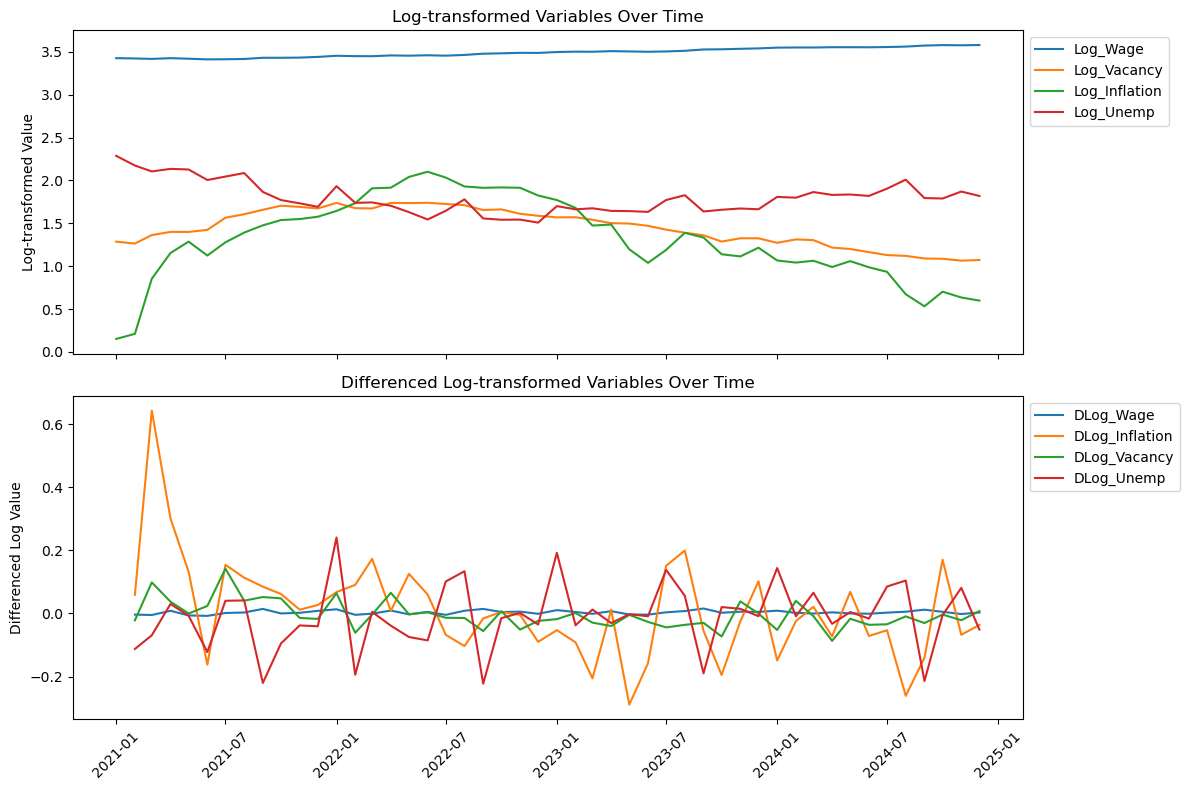

In [168]:
fig, axs = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

# First subplot: Log-transformed variables
axs[0].plot(overall_indicators[modified_set])
axs[0].legend(modified_set, loc='upper left', bbox_to_anchor=(1, 1))
axs[0].set_title('Log-transformed Variables Over Time')
axs[0].set_ylabel('Log-transformed Value')
axs[0].tick_params(axis='x', rotation=45)

# Second subplot: Differenced log-transformed variables
axs[1].plot(overall_indicators[differenced_indicators])
axs[1].legend(differenced_indicators, loc='upper left', bbox_to_anchor=(1, 1))
axs[1].set_title('Differenced Log-transformed Variables Over Time')
axs[1].set_xlabel('')
axs[1].set_ylabel('Differenced Log Value')
axs[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

### Vector Auto Regression Model

In [169]:
var_data = overall_indicators[differenced_indicators].dropna()

# Selecting the optimal lag length for VAR model
model = VAR(var_data)
lag_selection = model.select_order(maxlags=6) 
print(lag_selection.summary())

 VAR Order Selection (* highlights the minimums) 
      AIC         BIC         FPE         HQIC   
-------------------------------------------------
0     -25.94*     -25.77*  5.431e-12*     -25.88*
1      -25.60      -24.76   7.692e-12      -25.29
2      -25.27      -23.76   1.096e-11      -24.72
3      -24.92      -22.74   1.652e-11      -24.13
4      -25.27      -22.43   1.306e-11      -24.24
5      -25.31      -21.80   1.565e-11      -24.03
6      -25.86      -21.68   1.296e-11      -24.34
-------------------------------------------------


Although optimal lag length for VAR is 0, a VAR(2) will be employed to allow the VECM model to explore short-term and long-term dynamics

In [170]:
# Fitting the VAR model with the selected lag length

start_time = time.time()

model = VAR(var_data)
var_results = model.fit(maxlags=2)


end_time = time.time()
print(f"VAR Model Training Time: {end_time - start_time:.4f} seconds")

# Summary of the VAR model
print(var_results.summary())
print(var_results.is_stable(verbose=True))

VAR Model Training Time: 0.0022 seconds
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Sat, 12, Apr, 2025
Time:                     00:26:09
--------------------------------------------------------------------
No. of Equations:         4.00000    BIC:                   -23.6347
Nobs:                     45.0000    HQIC:                  -24.5413
Log likelihood:           344.893    FPE:                1.31026e-11
AIC:                     -25.0801    Det(Omega_mle):     6.31878e-12
--------------------------------------------------------------------
Results for equation DLog_Wage
                       coefficient       std. error           t-stat            prob
------------------------------------------------------------------------------------
const                     0.004149         0.001162            3.571           0.000
L1.DLog_Wage              0.006730         0.156491            0.043           0.966


Absolute Eigenvalues <1, model is stable

In [171]:
# Checking residuals for Autocorrelation using Ljung-Box test
for col in var_results.resid.columns:
    lb_test = acorr_ljungbox(var_results.resid[col], lags=[2], return_df=True)
    print(f"Ljung-Box for {col}:\n{lb_test}\n")

# Checking residuals for normality using Jarque-Bera test
for col in var_results.resid.columns:
    jb_stat, jb_pvalue, _, _ = jarque_bera(var_results.resid[col])
    print(f"Jarque-Bera for {col}: JB={jb_stat:.2f}, p-value={jb_pvalue:.4f}")


Ljung-Box for DLog_Wage:
   lb_stat  lb_pvalue
2    0.020      0.990

Ljung-Box for DLog_Inflation:
   lb_stat  lb_pvalue
2    1.051      0.591

Ljung-Box for DLog_Vacancy:
   lb_stat  lb_pvalue
2    0.805      0.669

Ljung-Box for DLog_Unemp:
   lb_stat  lb_pvalue
2    0.931      0.628

Jarque-Bera for DLog_Wage: JB=1.16, p-value=0.5604
Jarque-Bera for DLog_Inflation: JB=2.45, p-value=0.2944
Jarque-Bera for DLog_Vacancy: JB=1.05, p-value=0.5917
Jarque-Bera for DLog_Unemp: JB=2.02, p-value=0.3645


Residual distribution is normal, no residual autocorrelation found

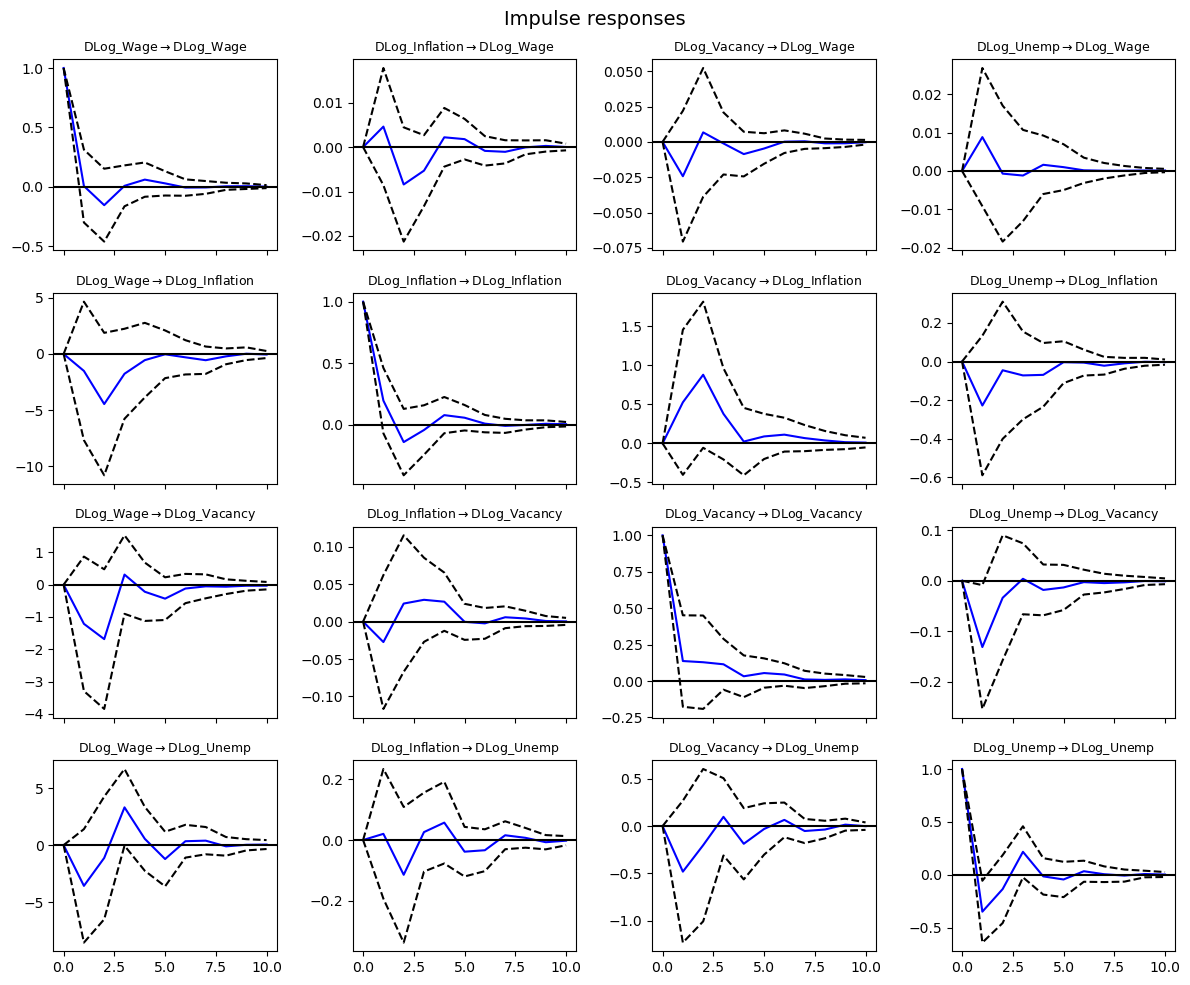

In [172]:
# Plotting Impulse Response Functions (IRF) of the VAR model
irf = var_results.irf(10)  
fig = irf.plot(
    orth=False,
    figsize=(12, 10),
    subplot_params={"fontsize": 9}
)
plt.tight_layout()
plt.show()


### Vector Error Correction Model

In [173]:
# VECM variables (non-differenced but stationary at I(1))
vecm_vars = ['Log_Wage', 'Log_Inflation', 'Log_Unemp', 'Log_Vacancy']

# Drop NA values
vecm_data = overall_indicators[vecm_vars].dropna()

# Johansen cointegration test
johansen_test = coint_johansen(vecm_data, det_order=0, k_ar_diff=1)
johansen_test_summary = pd.DataFrame({
    'Eigenvalue': johansen_test.eig,
    'Trace Statistic': johansen_test.lr1,
    'Critical Value (5%)': johansen_test.cvt[:, 1],
    'Max Eigenvalue Statistic': johansen_test.lr2,
    'Critical Value (5%)': johansen_test.cvm[:, 1]
}, index=[f'Rank {i}' for i in range(len(johansen_test.eig))])
johansen_test_summary

,Eigenvalue,Trace Statistic,Critical Value (5%),Max Eigenvalue Statistic
Rank 0,0.563,81.842,27.586,38.099
Rank 1,0.410,43.743,21.131,24.259
Rank 2,0.335,19.484,14.264,18.753
Rank 3,0.016,0.731,3.841,0.731


There are 2 cointegrating relationships

In [174]:
# Fit VECM with 2 cointegrating relationships
start_time = time.time()
vecm_model = VECM(vecm_data, k_ar_diff=1, coint_rank=2, deterministic='ci')  # 'ci' = constant in cointegration relation
vecm_results = vecm_model.fit()

end_time = time.time()

print(f"VECM fitting time: {end_time - start_time:.2f} seconds")
# Display VECM results
print(vecm_results.summary())


VECM fitting time: 0.00 seconds
Det. terms outside the coint. relation & lagged endog. parameters for equation Log_Wage
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
L1.Log_Wage          0.2494      0.143      1.743      0.081      -0.031       0.530
L1.Log_Inflation     0.0078      0.007      1.125      0.261      -0.006       0.021
L1.Log_Unemp         0.0158      0.010      1.596      0.110      -0.004       0.035
L1.Log_Vacancy      -0.0199      0.026     -0.757      0.449      -0.071       0.032
Det. terms outside the coint. relation & lagged endog. parameters for equation Log_Inflation
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
L1.Log_Wage          0.6992      2.362      0.296      0.767      -3.930       5.329
L1.Log_Inflation     0

In [175]:
# Accessing residuals from the VECM results
resid = vecm_results.resid 

# Test each residual series for autocorrelation and print results as a DataFrame
for i, col_name in enumerate(vecm_results.model.endog_names):
    lb_results = acorr_ljungbox(resid[:, i], lags=[1], return_df=True)
    print(f"\nResidual autocorrelation test for {col_name}:")
    print(lb_results)

# Accessing residuals from the VECM results
endog_names = vecm_results.model.endog_names

# Test each residual series for normality using Jarque-Bera test
print("\nJarque-Bera Test for Residual Normality:")
for i, name in enumerate(endog_names):
    jb_stat, jb_pvalue, skew, kurtosis = jarque_bera(resid[:, i])
    print(f"{name}: JB stat = {jb_stat:.4f}, p-value = {jb_pvalue:.4f}, skew = {skew:.4f}, kurtosis = {kurtosis:.4f}")




Residual autocorrelation test for Log_Wage:
   lb_stat  lb_pvalue
1    1.203      0.273

Residual autocorrelation test for Log_Inflation:
   lb_stat  lb_pvalue
1    1.300      0.254

Residual autocorrelation test for Log_Unemp:
   lb_stat  lb_pvalue
1    1.364      0.243

Residual autocorrelation test for Log_Vacancy:
   lb_stat  lb_pvalue
1    0.355      0.551

Jarque-Bera Test for Residual Normality:
Log_Wage: JB stat = 0.8722, p-value = 0.6465, skew = 0.1286, kurtosis = 2.3764
Log_Inflation: JB stat = 3.0781, p-value = 0.2146, skew = -0.6229, kurtosis = 3.2326
Log_Unemp: JB stat = 5.1756, p-value = 0.0752, skew = 0.7193, kurtosis = 3.7941
Log_Vacancy: JB stat = 1.4334, p-value = 0.4884, skew = 0.4323, kurtosis = 2.9833


Residual distribution is normal, no residual autocorrelation found

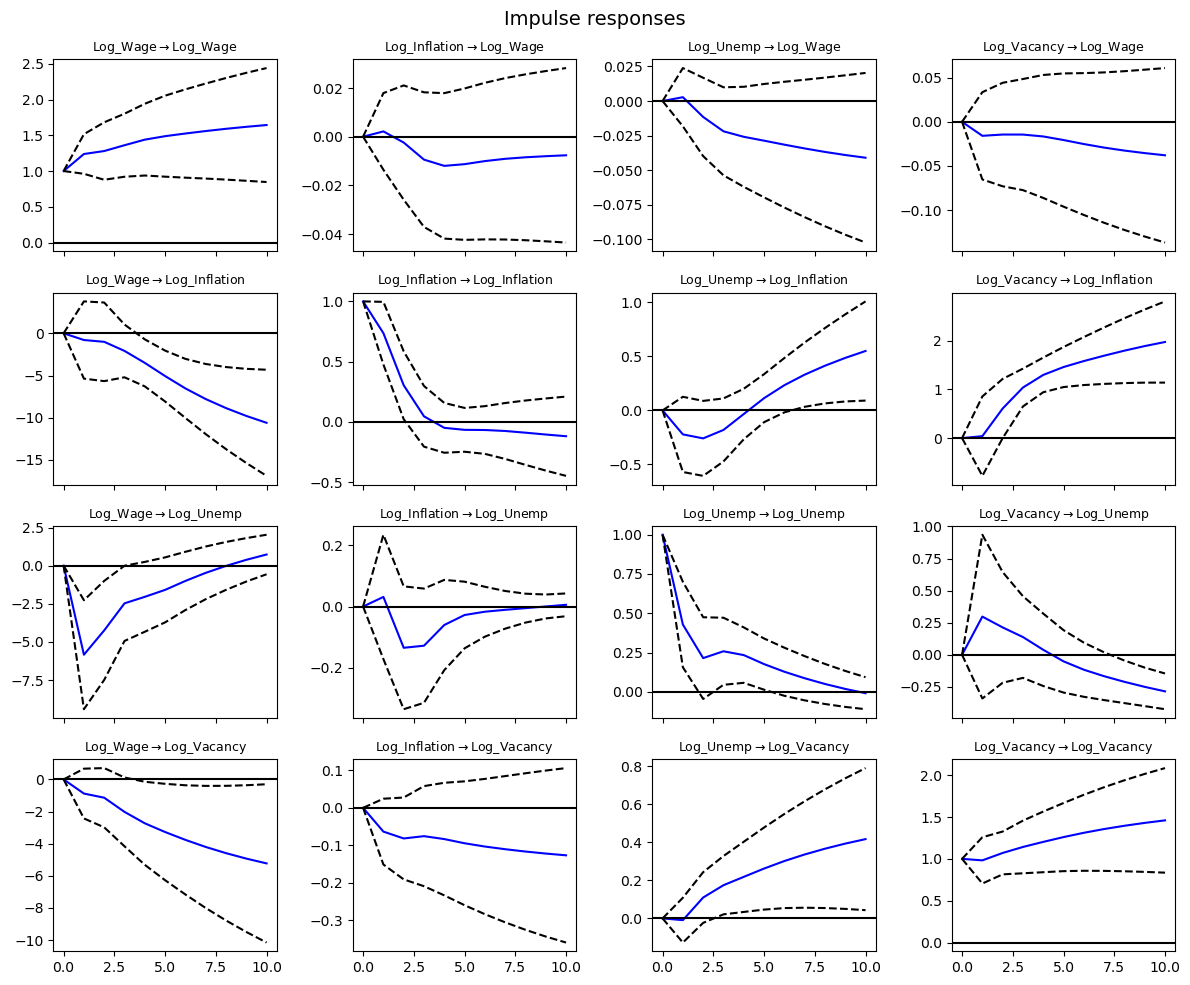

In [176]:
# Plotting Impulse Response Functions (IRF) of the VECM model
irf = vecm_results.irf(10)
fig = irf.plot(
    orth=False,
    figsize=(12, 10),
    subplot_params={"fontsize": 9}
)
plt.tight_layout()
plt.show()


### Forecasting & Model Comparison

In [177]:
# Actual data for 2025
actual_2025 = monthly_2025[['REF_DATE', 'Unemployment_Rate(%)', 'Average_Hourly_Wage', 'Inflation_Rate_YoY']]
actual_2025.set_index('REF_DATE', inplace=True)
actual_2025.index.freq = 'MS'
actual_2025.sort_index(inplace=True)

# Define functions for automation
def inverse_log(df, cols):
    """Exponentiate log-transformed columns"""
    return df.assign(**{col: np.exp(df[col]) for col in cols})

def calc_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100
    return round(mae, 4), round(rmse, 4), round(mape, 2)

def plot_forecasts(historical, forecast, title):
    plt.figure(figsize=(10, 6))
    for col in forecast.columns:
        if col in historical.columns:
            plt.plot(historical[col][-12:], label=f'Historical - {col}')
        plt.plot(forecast[col], '--o', label=f'Forecast - {col}')
    plt.legend()
    plt.title(title)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()



Forecast Errors:


,Target_Variable,Model,MAE,RMSE,MAPE (%)
0,Unemployment_Rate(%),VECM,0.282,0.354,4.030
1,Unemployment_Rate(%),VAR,0.663,0.684,9.600
2,Average_Hourly_Wage,VECM,0.149,0.152,0.410
3,Average_Hourly_Wage,VAR,0.007,0.010,0.020
4,Inflation_Rate_YoY,VECM,0.539,0.618,22.250
5,Inflation_Rate_YoY,VAR,0.405,0.485,16.490



Best Model per Variable:


,Target_Variable,Best_Model,Lowest_MAPE (%)
0,Average_Hourly_Wage,VAR,0.020
1,Inflation_Rate_YoY,VAR,16.490
2,Unemployment_Rate(%),VECM,4.030


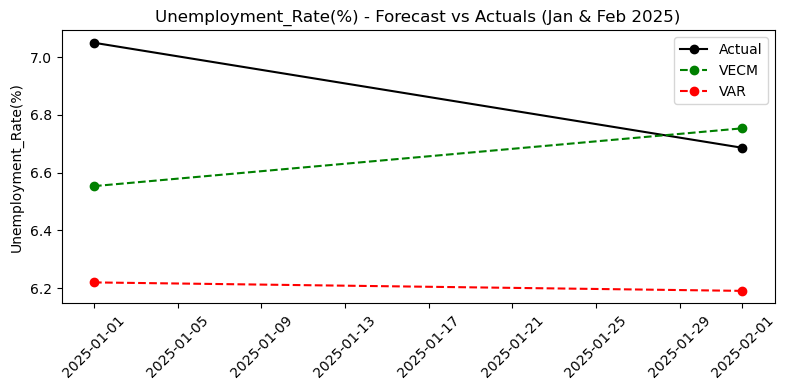

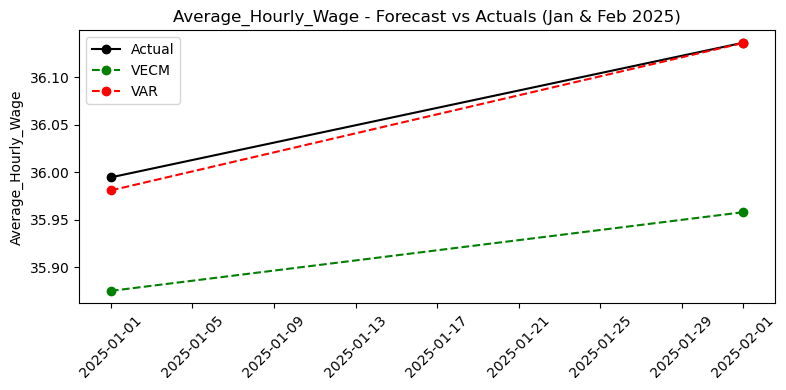

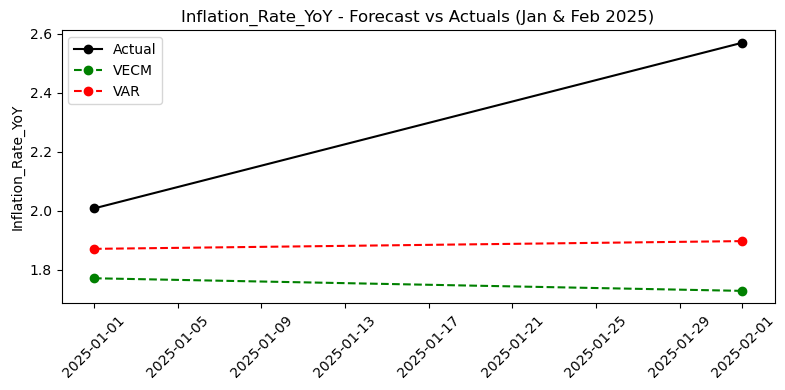

In [178]:
# VECM Forecasting and Evaluation
# Forecast 2 months ahead
n_forecast = 2
forecast = vecm_results.predict(steps=n_forecast)

# Create forecast DataFrame
forecast_index = pd.date_range(start=vecm_data.index[-1] + pd.DateOffset(months=1), periods=n_forecast, freq='MS')
vecm_forecast = pd.DataFrame(forecast, index=forecast_index, columns=vecm_data.columns)

# Inverse transform log variables
vecm_forecast['Log_Wage'] = np.exp(vecm_forecast['Log_Wage'])
vecm_forecast['Log_Inflation'] = np.exp(vecm_forecast['Log_Inflation'])
vecm_forecast['Log_Unemp'] = np.exp(vecm_forecast['Log_Unemp'])

# Rename columns for clarity
vecm_forecast.rename(columns={
    'Log_Wage': 'Forecast_Average_Hourly_Wage',
    'Log_Inflation': 'Forecast_Inflation_Rate_YoY',
    'Log_Unemp': 'Forecast_Unemployment_Rate(%)'
}, inplace=True)

vecm_eval = {}
for col in vecm_forecast.columns:
    actual_col = col.replace("Forecast_", "")
    if actual_col in actual_2025.columns:
        y_true = actual_2025[actual_col].iloc[:2].values
        y_pred = vecm_forecast[col].values
        mae, rmse, mape = calc_metrics(y_true, y_pred)
        vecm_eval[actual_col] = {'Forecast': y_pred, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}

# VAR Forecasting and Evaluation
forecast_input = var_data.values[-var_results.k_ar:]
forecast_diff_df = pd.DataFrame(var_results.forecast(y=forecast_input, steps=2), index=forecast_index, columns=var_results.names)

# Reconstruct actuals
reconstructed = pd.DataFrame(index=forecast_index)
reconstructed['Log_Wage'] = overall_indicators['Log_Wage'].iloc[-1] + forecast_diff_df['DLog_Wage'].cumsum()
reconstructed['Log_Inflation'] = overall_indicators['Log_Inflation'].iloc[-1] + forecast_diff_df['DLog_Inflation'].cumsum()
reconstructed['Log_Unemp'] = overall_indicators['Log_Unemp'].iloc[-1] + forecast_diff_df['DLog_Unemp'].cumsum()
reconstructed = inverse_log(reconstructed, ['Log_Wage', 'Log_Inflation', 'Log_Unemp'])

reconstructed.rename(columns={
    'Log_Wage': 'Forecast_Average_Hourly_Wage',
    'Log_Inflation': 'Forecast_Inflation_Rate_YoY',
    'Log_Unemp': 'Forecast_Unemployment_Rate(%)'
}, inplace=True)

var_eval = {}
for col in reconstructed.columns:
    actual_col = col.replace("Forecast_", "")
    if actual_col in actual_2025.columns:
        y_true = actual_2025[actual_col].iloc[:2].values
        y_pred = reconstructed[col].values
        mae, rmse, mape = calc_metrics(y_true, y_pred)
        var_eval[actual_col] = {'Forecast': y_pred, 'MAE': mae, 'RMSE': rmse, 'MAPE': mape}


# Compare All Models 

# Create Forecast Errors DataFrame
model_names = ['VECM', 'VAR']
forecast_errors = []

for target in actual_2025.columns:
    for model_name, model_eval in zip(model_names, [vecm_eval, var_eval]):
        if target in model_eval:
            m = model_eval[target]
            forecast_errors.append({
                'Target_Variable': target,
                'Model': model_name,
                'MAE': m['MAE'],
                'RMSE': m['RMSE'],
                'MAPE (%)': m['MAPE']
            })

forecast_errors_df = pd.DataFrame(forecast_errors)
forecast_errors_df.to_csv("Data/Forecast_Error_Metrics.csv", index=False)

# Create Best Model Summary DataFrame (based on lowest MAPE)
best_models = (
    forecast_errors_df
    .loc[forecast_errors_df.groupby('Target_Variable')['MAPE (%)'].idxmin()]
    .reset_index(drop=True)
    .rename(columns={
        'Model': 'Best_Model',
        'MAPE (%)': 'Lowest_MAPE (%)'
    })[['Target_Variable', 'Best_Model', 'Lowest_MAPE (%)']]
)
best_model_df = best_models
best_model_df.to_csv("Data/Best_Forecasting_Models.csv", index=False)

# Display both DataFrames
print("\nForecast Errors:")
display(forecast_errors_df)

print("\nBest Model per Variable:")
display(best_model_df)

# Plot model forecasts vs actuals for each variable
for target in actual_2025.columns:
    plt.figure(figsize=(8, 4))
    actual_vals = actual_2025[target].iloc[:2].values
    dates = actual_2025.index[:2]

    plt.plot(dates, actual_vals, 'k-o', label='Actual')
\
    if target in vecm_eval:
        plt.plot(dates, vecm_eval[target]['Forecast'], 'g--o', label='VECM')
    if target in var_eval:
        plt.plot(dates, var_eval[target]['Forecast'], 'r--o', label='VAR')

    plt.title(f"{target} - Forecast vs Actuals (Jan & Feb 2025)")
    plt.ylabel(target)
    plt.xticks(rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()



## Understanding Which Factors Predict Industy's Unemployment Rate Change: Model Approach

### Preprocessing

Target distribution:
 target
0    520
1    467
Name: count, dtype: int64


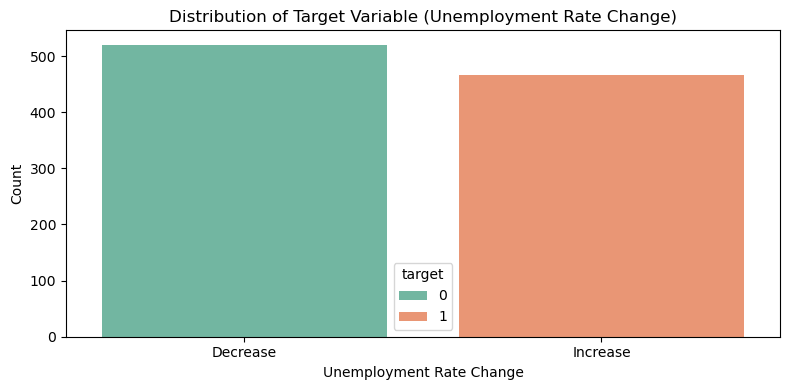

In [179]:
# Prepare data for modeling
df = industry_trends.sort_values(['NAICS_21_Label', 'REF_DATE']).reset_index(drop=True)

# Compute the month-to-month change in unemployment for each industry,
# then shift backward so that features at time t predict change at t+1.
df['Unemp_change'] = df.groupby('NAICS_21_Label', observed=False)['Unemployment_Rate(%)'].diff().shift(-1)

# Create binary target: 1 if unemployment increased, 0 otherwise.
df['target'] = (df['Unemp_change'] > 0).astype(int)

# Drop rows with missing change values (typically the last observation in each group after shifting)
df_model = df.dropna(subset=['Unemp_change']).copy()

# Check for target imbalance
target_counts = df_model['target'].value_counts()
print("Target distribution:\n", target_counts)

# Plot the distribution of the target variable
plt.figure(figsize=(8, 4))
sns.countplot(x='target', data=df_model, hue= 'target', palette='Set2')
plt.title('Distribution of Target Variable (Unemployment Rate Change)')
plt.xlabel('Unemployment Rate Change')
plt.ylabel('Count')
plt.xticks([0, 1], ['Decrease', 'Increase'])
plt.tight_layout()
plt.show()


In [180]:
# Define predictor variables
predictors = [
    'Job Vacancy Rate (%)', 'Unemployment_Rate(%)', 'Duration_Jobless(Months)', 'Average_Hourly_Wage',
    'Market_Tightness', 'Lagged_Unemployment_Rate',
    'Lagged_Market_Tightness', 'Inflation_Rate_MoM', 
    'Inflation_Rate_YoY', 'perm_temp_share', 'union_share', 'avg_tenure',
    'underutilized_share', 'overworked_share']


# Extract feature matrix (X) and target (y)
X = df_model[predictors]
y = df_model['target']

# Split data into training and testing sets (70% train, 30% test), with stratification to maintain target distribution
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [181]:
# Extract just the training predictors
X_vif = X_train.copy()

# Add a constant term for VIF calculation
X_vif = add_constant(X_vif)

# Create a DataFrame to hold VIF values
vif_data = pd.DataFrame()
vif_data["Variable"] = X_vif.columns
vif_data["VIF"] = [variance_inflation_factor(X_vif.values, i) for i in range(X_vif.shape[1])]

# Optional: Drop the constant from the results
vif_data = vif_data[vif_data["Variable"] != "const"]

# Sort for easier viewing
vif_data = vif_data.sort_values(by="VIF", ascending=False)

# Show the results
print(vif_data)


                    Variable   VIF
2       Unemployment_Rate(%) 5.745
6   Lagged_Unemployment_Rate 5.570
5           Market_Tightness 3.505
7    Lagged_Market_Tightness 3.166
1       Job Vacancy Rate (%) 2.991
4        Average_Hourly_Wage 2.187
11               union_share 2.091
14          overworked_share 1.929
10           perm_temp_share 1.803
9         Inflation_Rate_YoY 1.702
12                avg_tenure 1.618
13       underutilized_share 1.320
8         Inflation_Rate_MoM 1.292
3   Duration_Jobless(Months) 1.165


VIF values are acceptable, variables are ready for modeling

#### Random Forest

In [182]:
# Baseline Random Forest Model
print("\n--- Random Forest Baseline ---")

rf = RandomForestClassifier(random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
print(classification_report(y_test, y_pred_rf))
print("Accuracy:", accuracy_score(y_test, y_pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]))

# RFECV for Random Forest
rfecv_rf = RFECV(
    estimator=RandomForestClassifier(random_state=42),
    step=1,
    cv=5,
    scoring='roc_auc'
)
rfecv_rf.fit(X_train, y_train)
optimal_rf_features = X_train.columns[rfecv_rf.support_]
print("\n\nRFCEV - Optimal number of features:", rfecv_rf.n_features_)
print("RFECV - Optimal RF features:", optimal_rf_features.tolist())

# Prepare datasets based on selected features
X_train_rf_rfe = X_train[optimal_rf_features]
X_test_rf_rfe = X_test[optimal_rf_features]

# Randomized Search for RF hyperparameter tuning
param_dist_rf = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [None, 3, 5, 7, 10],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'max_features': ['sqrt', 'log2', None]
}
random_search_rf = RandomizedSearchCV(
    estimator=RandomForestClassifier(random_state=42),
    param_distributions=param_dist_rf,
    n_iter=50,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)
start_time = time.time()
random_search_rf.fit(X_train_rf_rfe, y_train)
rf_tuning_time = time.time() - start_time
print("\n\nRandomizedSearchCV RF Best Params:", random_search_rf.best_params_)
print("RandomizedSearchCV RF Best ROC-AUC:", random_search_rf.best_score_)

# Final RF Model
final_rf = random_search_rf.best_estimator_
start_time = time.time()
final_rf.fit(X_train_rf_rfe, y_train)
rf_final_time = time.time() - start_time
y_pred_final_rf = final_rf.predict(X_test_rf_rfe)
rf_final_accuracy = accuracy_score(y_test, y_pred_final_rf)
rf_final_roc_auc = roc_auc_score(y_test, final_rf.predict_proba(X_test_rf_rfe)[:, 1])
print("\n--- Final Random Forest Model ---")
print(classification_report(y_test, y_pred_final_rf))
print("Accuracy:", rf_final_accuracy)
print("ROC-AUC:", rf_final_roc_auc)
rf_cv_scores = cross_val_score(final_rf, X_train_rf_rfe, y_train, cv=5, scoring='roc_auc')
print("\nRF CV Mean ROC-AUC:", rf_cv_scores.mean())


--- Random Forest Baseline ---
              precision    recall  f1-score   support

           0       0.61      0.61      0.61       156
           1       0.56      0.56      0.56       141

    accuracy                           0.59       297
   macro avg       0.58      0.58      0.58       297
weighted avg       0.59      0.59      0.59       297

Accuracy: 0.5858585858585859
ROC-AUC: 0.610383706128387


RFCEV - Optimal number of features: 5
RFECV - Optimal RF features: ['Unemployment_Rate(%)', 'Duration_Jobless(Months)', 'Market_Tightness', 'Lagged_Unemployment_Rate', 'perm_temp_share']


RandomizedSearchCV RF Best Params: {'n_estimators': 100, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': None, 'max_depth': None}
RandomizedSearchCV RF Best ROC-AUC: 0.644408973826782

--- Final Random Forest Model ---
              precision    recall  f1-score   support

           0       0.63      0.62      0.63       156
           1       0.59      0.60      0.59       1

#### XGBoost

In [183]:
# Baseline XGBoost Model
print("\n--- XGBoost Baseline ---")

xgb = XGBClassifier(random_state=42, eval_metric='logloss')
xgb.fit(X_train, y_train)
y_pred_xgb = xgb.predict(X_test)
print(classification_report(y_test, y_pred_xgb))
print("Accuracy:", accuracy_score(y_test, y_pred_xgb))
print("ROC-AUC:", roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1]))

# RFECV for XGBoost
rfecv_xgb = RFECV(
    estimator=XGBClassifier(random_state=42, eval_metric='logloss'),
    step=1,
    cv=5,
    scoring='roc_auc'
)
rfecv_xgb.fit(X_train, y_train)
optimal_xgb_features = X_train.columns[rfecv_xgb.support_]
print("\n\nRFCEV - Optimal number of features:", rfecv_xgb.n_features_)
print("RFECV - Optimal XGB features:", optimal_xgb_features.tolist())

# Prepare datasets based on selected features
X_train_xgb_rfe = X_train[optimal_xgb_features]
X_test_xgb_rfe = X_test[optimal_xgb_features]

# Randomized Search for XGBoost hyperparameter tuning
param_dist_xgb = {
    'n_estimators': [50, 100, 200, 300],
    'max_depth': [3, 5, 7, 9],
    'learning_rate': [0.01, 0.1, 0.2, 0.3],
    'subsample': [0.6, 0.8, 1.0],
    'colsample_bytree': [0.6, 0.8, 1.0],
    'reg_alpha': [0, 0.01, 0.1],
    'reg_lambda': [1, 1.5, 2]
}
random_search_xgb = RandomizedSearchCV(
    estimator=XGBClassifier(random_state=42, eval_metric='logloss'),
    param_distributions=param_dist_xgb,
    n_iter=50,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)
start_time = time.time()
random_search_xgb.fit(X_train_xgb_rfe, y_train)
xgb_tuning_time = time.time() - start_time
print("\n\nRandomizedSearchCV XGB Best Params:", random_search_xgb.best_params_)
print("RandomizedSearchCV XGB Best ROC-AUC:", random_search_xgb.best_score_)

# Final XGBoost Model
final_xgb = random_search_xgb.best_estimator_
start_time = time.time()
final_xgb.fit(X_train_xgb_rfe, y_train)
xgb_final_time = time.time() - start_time
y_pred_final_xgb = final_xgb.predict(X_test_xgb_rfe)
xgb_final_accuracy = accuracy_score(y_test, y_pred_final_xgb)
xgb_final_roc_auc = roc_auc_score(y_test, final_xgb.predict_proba(X_test_xgb_rfe)[:, 1])
print("\n--- Final XGBoost Model ---")
print(classification_report(y_test, y_pred_final_xgb))
print("Accuracy:", xgb_final_accuracy)
print("ROC-AUC:", xgb_final_roc_auc)
xgb_cv_scores = cross_val_score(final_xgb, X_train_xgb_rfe, y_train, cv=5, scoring='roc_auc')
print("\nXGB CV Mean ROC-AUC:", xgb_cv_scores.mean())


--- XGBoost Baseline ---
              precision    recall  f1-score   support

           0       0.62      0.56      0.59       156
           1       0.56      0.62      0.59       141

    accuracy                           0.59       297
   macro avg       0.59      0.59      0.59       297
weighted avg       0.59      0.59      0.59       297

Accuracy: 0.5892255892255892
ROC-AUC: 0.6122931442080378


RFCEV - Optimal number of features: 13
RFECV - Optimal XGB features: ['Job Vacancy Rate (%)', 'Unemployment_Rate(%)', 'Duration_Jobless(Months)', 'Market_Tightness', 'Lagged_Unemployment_Rate', 'Lagged_Market_Tightness', 'Inflation_Rate_MoM', 'Inflation_Rate_YoY', 'perm_temp_share', 'union_share', 'avg_tenure', 'underutilized_share', 'overworked_share']


RandomizedSearchCV XGB Best Params: {'subsample': 0.6, 'reg_lambda': 1.5, 'reg_alpha': 0, 'n_estimators': 50, 'max_depth': 9, 'learning_rate': 0.2, 'colsample_bytree': 0.8}
RandomizedSearchCV XGB Best ROC-AUC: 0.6321443003977251



#### Logistic Regression

In [184]:
# Standardize the predictors for Logistic Regression
scaler_lr = StandardScaler()
X_scaled_array = scaler_lr.fit_transform(X)  # X is your original DataFrame
features_to_keep = X.columns.tolist()

# Convert back to DataFrame to preserve column names
X_scaled = pd.DataFrame(X_scaled_array, columns=features_to_keep)

# Split data into training and testing sets
X_train_lr, X_test_lr, y_train_lr, y_test_lr = train_test_split(X_scaled, y, test_size=0.3, random_state=42, stratify=y)

# Baseline Logistic Regression
# To match statsmodels summary output, we set penalty='none' and fit_intercept=True
log_reg = LogisticRegression(
    penalty=None,           
    fit_intercept=True,       
    solver='lbfgs',           
    max_iter=1000,
    random_state=42
)
log_reg.fit(X_train_lr, y_train_lr)
y_pred_lr = log_reg.predict(X_test_lr)
print("\n--- Logistic Regression Baseline (Reduced Features) ---")
print(classification_report(y_test_lr, y_pred_lr))
print("Accuracy:", accuracy_score(y_test_lr, y_pred_lr))
print("ROC-AUC:", roc_auc_score(y_test_lr, log_reg.predict_proba(X_test_lr)[:, 1]))

# RFECV for Logistic Regression
rfecv_lr = RFECV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    step=1,
    cv=5,
    scoring='roc_auc'
)
rfecv_lr.fit(X_train_lr, y_train_lr)

# Get selected features
optimal_lr_features = X_train_lr.columns[rfecv_lr.support_]
print("\nOptimal number of features (LR - RFECV):", rfecv_lr.n_features_)
print("Selected features (LR):", optimal_lr_features.tolist())

# Prepare reduced feature sets
X_train_lr_rfe = X_train_lr[optimal_lr_features]
X_test_lr_rfe = X_test_lr[optimal_lr_features]

# --- Hyperparameter Tuning ---
param_dist_lr = {
    'C': [0.01, 0.1, 1, 10, 100],
    'penalty': ['l2'],
    'solver': ['lbfgs', 'saga']
}
random_search_lr = RandomizedSearchCV(
    estimator=LogisticRegression(max_iter=1000, random_state=42),
    param_distributions=param_dist_lr,
    n_iter=10,
    cv=5,
    scoring='roc_auc',
    random_state=42,
    n_jobs=-1
)

start_time = time.time()
random_search_lr.fit(X_train_lr_rfe, y_train_lr)
lr_tuning_time = time.time() - start_time

print("\nBest LR params:", random_search_lr.best_params_)
print("Best CV ROC-AUC (LR):", random_search_lr.best_score_)

# --- Final Model ---

final_lr = random_search_lr.best_estimator_

start_time = time.time()
final_lr.fit(X_train_lr_rfe, y_train_lr)
lr_final_time = time.time() - start_time

y_pred_final_lr = final_lr.predict(X_test_lr_rfe)

print("\n--- Final Logistic Regression Model ---")
print(classification_report(y_test_lr, y_pred_final_lr))
print("Accuracy:", accuracy_score(y_test_lr, y_pred_final_lr))
print("ROC-AUC:", roc_auc_score(y_test_lr, final_lr.predict_proba(X_test_lr_rfe)[:, 1]))
print("Training time (s):", round(lr_final_time, 2))

# Cross-validation score on full dataset with selected features
X_reduced_full = X_scaled[optimal_lr_features]
lr_cv_scores = cross_val_score(final_lr, X_reduced_full, y, cv=5, scoring='roc_auc')
print("LR CV ROC-AUC scores:", np.round(lr_cv_scores, 4))
print("Mean LR CV ROC-AUC:", lr_cv_scores.mean())



--- Logistic Regression Baseline (Reduced Features) ---
              precision    recall  f1-score   support

           0       0.62      0.75      0.68       156
           1       0.64      0.48      0.55       141

    accuracy                           0.62       297
   macro avg       0.63      0.62      0.61       297
weighted avg       0.63      0.62      0.62       297

Accuracy: 0.622895622895623
ROC-AUC: 0.659847244953628

Optimal number of features (LR - RFECV): 14
Selected features (LR): ['Job Vacancy Rate (%)', 'Unemployment_Rate(%)', 'Duration_Jobless(Months)', 'Average_Hourly_Wage', 'Market_Tightness', 'Lagged_Unemployment_Rate', 'Lagged_Market_Tightness', 'Inflation_Rate_MoM', 'Inflation_Rate_YoY', 'perm_temp_share', 'union_share', 'avg_tenure', 'underutilized_share', 'overworked_share']

Best LR params: {'solver': 'lbfgs', 'penalty': 'l2', 'C': 100}
Best CV ROC-AUC (LR): 0.6163453289480687

--- Final Logistic Regression Model ---
              precision    recall  f

In [185]:
# Add constant and reset index to align with y
X_train_lr_rfe_const = sm.add_constant(X_train_lr_rfe).reset_index(drop=True)
y_train_lr = y_train_lr.reset_index(drop=True)

# Fit and print the model summary
sm_logit_model = sm.Logit(y_train_lr, X_train_lr_rfe_const).fit()
print(sm_logit_model.summary())


Optimization terminated successfully.
         Current function value: 0.645979
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                 target   No. Observations:                  690
Model:                          Logit   Df Residuals:                      675
Method:                           MLE   Df Model:                           14
Date:                Sat, 12 Apr 2025   Pseudo R-squ.:                 0.06601
Time:                        00:26:37   Log-Likelihood:                -445.73
converged:                       True   LL-Null:                       -477.22
Covariance Type:            nonrobust   LLR p-value:                 3.472e-08
                               coef    std err          z      P>|z|      [0.025      0.975]
--------------------------------------------------------------------------------------------
const                       -0.1172      0.080     -1.455      0.146      -0.275

#### Model Comparison

                            Model  Training Time (s)  ROC-AUC  Accuracy  Optimal n_features                                  Selected Features
5   LR (RFE + RandomizedSearchCV)              0.008    0.660     0.623              14.000  [Job Vacancy Rate (%), Unemployment_Rate(%), D...
2                     Baseline LR              0.002    0.660     0.623                 NaN                                               None
3   RF (RFE + RandomizedSearchCV)              0.150    0.619     0.609               5.000  [Unemployment_Rate(%), Duration_Jobless(Months...
4  XGB (RFE + RandomizedSearchCV)              0.037    0.614     0.596              13.000  [Job Vacancy Rate (%), Unemployment_Rate(%), D...
1                    Baseline XGB              0.122    0.612     0.589                 NaN                                               None
0                     Baseline RF              0.173    0.610     0.586                 NaN                                               None

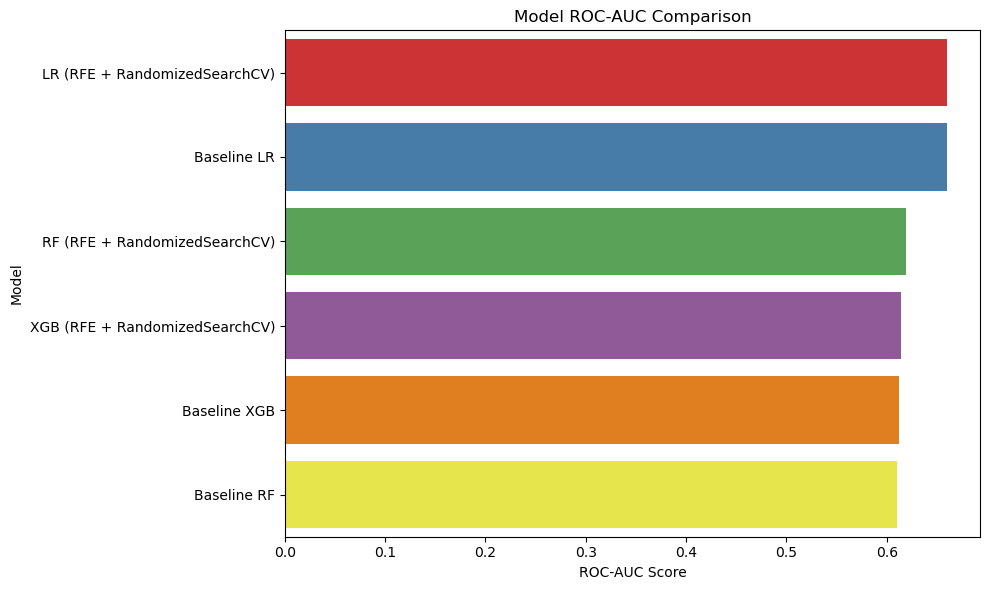

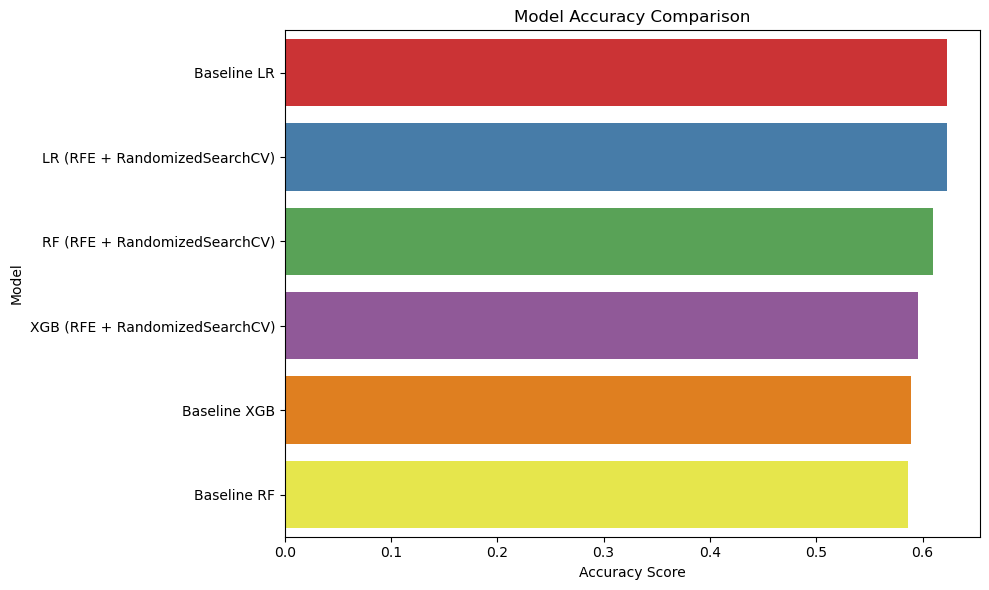

In [186]:
# Baseline training times for RF, XGB, and LR (using full feature set)
start = time.time(); rf.fit(X_train, y_train); baseline_rf_time = time.time() - start
start = time.time(); xgb.fit(X_train, y_train); baseline_xgb_time = time.time() - start
start = time.time(); log_reg.fit(X_train_lr, y_train_lr); baseline_lr_time = time.time() - start

# Create a summary DataFrame for model comparisons
results_df = pd.DataFrame({
    'Model': [
        'Baseline RF',
        'Baseline XGB',
        'Baseline LR',
        'RF (RFE + RandomizedSearchCV)',
        'XGB (RFE + RandomizedSearchCV)',
        'LR (RFE + RandomizedSearchCV)'
    ],
    'Training Time (s)': [
        baseline_rf_time,
        baseline_xgb_time,
        baseline_lr_time,
        rf_final_time,
        xgb_final_time,
        lr_final_time
    ],
    'ROC-AUC': [
        roc_auc_score(y_test, rf.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test, xgb.predict_proba(X_test)[:, 1]),
        roc_auc_score(y_test_lr, log_reg.predict_proba(X_test_lr)[:, 1]),
        roc_auc_score(y_test, final_rf.predict_proba(X_test_rf_rfe)[:, 1]),
        roc_auc_score(y_test, final_xgb.predict_proba(X_test_xgb_rfe)[:, 1]),
        roc_auc_score(y_test_lr, final_lr.predict_proba(X_test_lr_rfe)[:, 1])
    ],
    'Accuracy': [
        accuracy_score(y_test, rf.predict(X_test)),
        accuracy_score(y_test, xgb.predict(X_test)),
        accuracy_score(y_test_lr, y_pred_lr),
        accuracy_score(y_test, y_pred_final_rf),
        accuracy_score(y_test, y_pred_final_xgb),
        accuracy_score(y_test_lr, y_pred_final_lr)
    ],
    'Optimal n_features': [
        np.nan,  # Baseline RF uses full feature set
        np.nan,  # Baseline XGB uses full feature set
        np.nan,  # Baseline LR uses full feature set
        rfecv_rf.n_features_,
        rfecv_xgb.n_features_,
        rfecv_lr.n_features_
    ],
    'Selected Features': [
        None,    # Baseline RF
        None,    # Baseline XGB
        None,    # Baseline LR
        list(optimal_rf_features),
        list(optimal_xgb_features),
        list(optimal_lr_features)
    ]
})
print(results_df.sort_values(by='ROC-AUC', ascending=False))

# Plot ROC-AUC comparison
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df.sort_values(by='ROC-AUC', ascending=False), y='Model', x='ROC-AUC', hue = 'Model', palette='Set1')
plt.title("Model ROC-AUC Comparison")
plt.xlabel("ROC-AUC Score")
plt.tight_layout()
plt.show()

# Plot Accuracy comparison
plt.figure(figsize=(10, 6))
sns.barplot(data=results_df.sort_values(by='Accuracy', ascending=False), y='Model', x='Accuracy', hue= 'Model', palette='Set1')
plt.title("Model Accuracy Comparison")
plt.xlabel("Accuracy Score")
plt.tight_layout()
plt.show()
